<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_02_target_definition/stage_02_01_target_investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **stage_02_target_investigation**


## **Definición de targets a investigar (alineado con ML for Algorithmic Trading)**

El enfoque del libro establece que el objetivo del modelado no debe centrarse en predecir retornos o magnitudes exactas del precio, sino en construir **targets más estables, robustos y alineados con decisiones reales de trading**.

En este contexto, se define el siguiente conjunto de targets a investigar:

---

**T1. Dirección del movimiento (clasificación binaria)**

Se modela el problema como una clasificación simple:

* 1 → el precio sube en el horizonte H
* 0 → el precio no sube

Este enfoque reduce el ruido presente en los retornos y simplifica el problema a una decisión direccional.

---

**T2. Dirección con umbral (clasificación ternaria)**

Se introduce un umbral mínimo para filtrar movimientos poco relevantes:

* 1 → movimiento positivo significativo
* -1 → movimiento negativo significativo
* 0 → movimiento no significativo

Este target mejora la relación señal/ruido al ignorar variaciones pequeñas sin valor económico.

---

**T3. Outcome de trade (calidad de señal)**

El modelo no predice el mercado directamente, sino la calidad de una posible operación:

* 1 → trade exitoso
* 0 → trade no exitoso

Este enfoque permite evaluar si una señal tiene valor operativo, alineando el modelo con decisiones reales de trading.

---

**T4. Target basado en eventos (tipo barrera)**

Se define el target en función del resultado de un evento futuro:

* 1 → se alcanza take profit primero
* -1 → se alcanza stop loss primero
* 0 → no se alcanza ninguna condición dentro del horizonte

Este tipo de target está directamente alineado con la lógica de ejecución en trading.

---

**T5. Probabilidad de clase**

En todos los casos anteriores, el modelo puede formularse como un problema probabilístico:

* el modelo estima la probabilidad de cada clase
* las decisiones se toman en función de un umbral de confianza

Esto permite filtrar señales débiles y operar únicamente en escenarios de mayor certidumbre.



## **Estructura recomendada**

**Capítulo 1 — Construcción jerárquica de targets**

Acá defines TODOS los targets.

Desarrollas:

* qué es T1, T2, T3, T4, T5
* fórmulas
* relación entre ellos
* cómo evolucionan
* por qué cada uno mejora al anterior

Objetivo:
dejar toda la arquitectura conceptual cerrada.

---

**Capítulo 2 — Investigación estadística de targets**

Acá analizas TODOS los targets estadísticamente.

Por ejemplo:

* distribución de clases
* balance/desbalance
* frecuencia de trades
* cantidad de señales
* estabilidad temporal
* comportamiento por régimen

Objetivo:
entender si cada target es usable.

---

**Capítulo 3 — Relación targets-features**

Acá investigas:

* qué indicadores funcionan mejor para cada target
* mutual information
* IC
* correlaciones
* redundancia
* estabilidad OOS

Objetivo:
entender qué tipo de señales necesita cada target.

---

**Capítulo 4 — Modelado predictivo**

Acá entrenas modelos para TODOS los targets.

Por ejemplo:

* Logistic Regression
* Random Forest
* XGBoost
* GRU
* Transformer

Y comparas:

* accuracy
* f1
* balanced accuracy
* precision
* probabilidades

Objetivo:
ver qué targets son realmente predecibles.

---

**Capítulo 5 — Evaluación operativa final**

Acá conectas todo con trading real.

Analizas:

* pnl
* drawdown
* trade rate
* turnover
* Sharpe
* robustness
* thresholds de probabilidad

Y finalmente respondes:

* qué target sirve más
* qué modelo funciona mejor
* qué combinación es operable



## **Configuración del Entorno**


### **Acceso a Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Mounted at /content/drive


###**Importación de librerías**


In [2]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr
from __future__ import annotations  # permite type hints modernos (Python < 3.11)
import json                         # para guardar el summary como JSON
import os                           # para leer variables de entorno
from pathlib import Path            # manejo robusto de rutas
import pandas as pd

###**Definición de rutas**

In [3]:
DRIVE_DIR =   Path(os.environ.get("DRIVE_DIR", "/content/drive/MyDrive/neural_profit/"))

In [4]:
IN_PARQUET = Path(os.environ.get("IN_PARQUET", "data/02_processed/mnq_intraday.parquet"))
OUT_SUMMARY = Path(os.environ.get("OUT_SUMMARY", "reports/state_02_target_investigation_summary.json"))

In [5]:
# PARA EL NOTEBOOK:
IN_PARQUET = DRIVE_DIR / IN_PARQUET
OUT_SUMMARY = DRIVE_DIR / OUT_SUMMARY

### **Función para ver información de dataset**


In [6]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import pandas as pd


def mnq_dataset_info(
    df: pd.DataFrame,
    *,
    name: str = "mnq_raw",
    tz_assume_if_naive: Optional[str] = None,  # ej: "UTC" o "America/New_York"
    day_def: str = "calendar",  # "calendar" (fecha calendario) o "trading" (días con datos)
) -> Dict[str, Any]:
    """
    Resume un dataset OHLCV con DatetimeIndex (ideal para mnq_raw).

    - Si el índice es tz-naive:
        - Si tz_assume_if_naive != None, lo localiza a esa tz.
        - Si no, reporta "tz-naive" (no se puede afirmar horario UTC).
    - Devuelve dict con métricas principales (y lo imprime bonito si se desea).
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: se requiere DatetimeIndex, recibido: {type(df.index)}")

    idx = df.index

    # --- timezone / UTC info ---
    tzinfo = idx.tz
    if tzinfo is None:
        tz_status = "tz-naive (sin zona horaria)"
        if tz_assume_if_naive:
            idx = idx.tz_localize(tz_assume_if_naive)
            tzinfo = idx.tz
            tz_status = f"localizado como {tzinfo}"
    else:
        tz_status = f"{tzinfo}"

    # --- rango temporal ---
    ts_min = idx.min()
    ts_max = idx.max()

    first_day = ts_min.date()
    last_day = ts_max.date()

    # --- días ---
    if day_def == "calendar":
        total_days = (pd.Timestamp(last_day) - pd.Timestamp(first_day)).days + 1
    elif day_def == "trading":
        total_days = idx.normalize().nunique()
    else:
        raise ValueError("day_def debe ser 'calendar' o 'trading'")

    # --- columnas ---
    columns = list(df.columns)

    # --- checks útiles ---
    n_rows = len(df)
    n_cols = df.shape[1]
    n_missing = int(df.isna().sum().sum())
    missing_by_col = df.isna().sum().to_dict()
    dup_index = int(idx.duplicated().sum())
    is_monotonic = bool(idx.is_monotonic_increasing)

    # Frecuencia estimada (puede fallar si hay huecos grandes)
    freq = pd.infer_freq(idx[: min(50000, len(idx))])  # muestra grande pero acotada

    # Cobertura por día (min/max de hora del día, en tz del índice)
    # (Útil para ver si es 24/7 o horario de sesión)
    tod = pd.Series(idx.time)
    # Convertimos time a minutos del día para resumen robusto
    tod_minutes = pd.Series([t.hour * 60 + t.minute for t in tod])
    typical_minute_min = int(tod_minutes.min())
    typical_minute_max = int(tod_minutes.max())

    # Rango promedio de filas por día (sólo días con datos)
    rows_per_day = df.groupby(idx.normalize()).size()
    rows_per_day_stats = {
        "days_with_data": int(rows_per_day.shape[0]),
        "rows_per_day_min": int(rows_per_day.min()),
        "rows_per_day_p50": float(rows_per_day.median()),
        "rows_per_day_max": int(rows_per_day.max()),
    }

    # Si hay tz, también mostramos rango en UTC
    if tzinfo is not None:
        ts_min_utc = ts_min.tz_convert("UTC")
        ts_max_utc = ts_max.tz_convert("UTC")
        utc_range = (str(ts_min_utc), str(ts_max_utc))
        utc_note = "El índice está tz-aware; el horario UTC es inequívoco."
    else:
        utc_range = None
        utc_note = "El índice es tz-naive; no se puede asegurar si está en UTC sin suposiciones."

    info: Dict[str, Any] = {
        "name": name,
        "shape": (n_rows, n_cols),
        "columns": columns,
        "index_type": type(df.index).__name__,
        "index_tz": tz_status,
        "utc_note": utc_note,
        "datetime_min": str(ts_min),
        "datetime_max": str(ts_max),
        "first_day": str(first_day),
        "last_day": str(last_day),
        "total_days": int(total_days),
        "day_definition": day_def,
        "utc_range_if_applicable": utc_range,
        "is_index_monotonic_increasing": is_monotonic,
        "duplicated_timestamps_in_index": dup_index,
        "inferred_freq_sample": freq,
        "missing_total_cells": n_missing,
        "missing_by_col": missing_by_col,
        "rows_per_day_stats": rows_per_day_stats,
        "time_of_day_minutes_range": {
            "min_minute_of_day": typical_minute_min,
            "max_minute_of_day": typical_minute_max,
        },
    }
    return info


def print_mnq_dataset_info(info: Dict[str, Any]) -> None:
    """Imprime el dict de mnq_dataset_info de forma ordenada."""
    print(f"Dataset: {info['name']}")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print(f"Index: {info['index_type']} | TZ: {info['index_tz']}")
    print(f"Datetime min/max: {info['datetime_min']}  ->  {info['datetime_max']}")
    print(f"First/Last day: {info['first_day']}  ->  {info['last_day']}")
    print(f"Total days ({info['day_definition']}): {info['total_days']}")
    #print(f"Inferred freq (sample): {info['inferred_freq_sample']}")
    #print(f"Index monotonic increasing: {info['is_index_monotonic_increasing']}")
    #print(f"Duplicated timestamps in index: {info['duplicated_timestamps_in_index']}")
    #print(f"Missing total cells: {info['missing_total_cells']}")
    #print(f"Missing by col: {info['missing_by_col']}")
    #print(f"Rows/day stats: {info['rows_per_day_stats']}")
    print(f"Time-of-day range (minutes): {info['time_of_day_minutes_range']}")
    print(f"UTC note: {info['utc_note']}")
    if info["utc_range_if_applicable"] is not None:
        print(f"UTC range: {info['utc_range_if_applicable'][0]}  ->  {info['utc_range_if_applicable'][1]}")


### **Carga de dataset `intraday_mnq`**


In [7]:
def load_mnq_parquet():
    os.path.exists(IN_PARQUET)
    print("Archivo encontrado en disco. Cargando dataset local...")
    mnq_parquet = pd.read_parquet(IN_PARQUET)
    return mnq_parquet

In [8]:
mnq_intraday = load_mnq_parquet()

Archivo encontrado en disco. Cargando dataset local...


In [9]:
info = mnq_dataset_info(mnq_intraday, name="mnq_intraday", tz_assume_if_naive=None, day_def="trading")
print_mnq_dataset_info(info)

Dataset: mnq_intraday
Shape: (1024062, 8)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day', 'regime_id']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2020-01-02 04:30:00-05:00  ->  2026-04-17 16:00:00-04:00
First/Last day: 2020-01-02  ->  2026-04-17
Total days (trading): 1482
Time-of-day range (minutes): {'min_minute_of_day': 270, 'max_minute_of_day': 960}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2020-01-02 09:30:00+00:00  ->  2026-04-17 20:00:00+00:00


### **Validación temporal de dataset `mnq_intraday`**


Valida lo esencial para series temporales antes de construir targets: orden cronológico, duplicados, consistencia por día, monotonicidad de minute_of_day, gaps temporales y saltos sospechosos. Esto es importante porque en trading hay que validar cuidadosamente los timestamps para evitar look-ahead bias, y porque en series temporales el orden secuencial es parte central del problema.

In [10]:
import pandas as pd
import numpy as np

# ============================================================
# Validación temporal de mnq_intraday
# Ejecutar inmediatamente después de:
# mnq_intraday = load_mnq_parquet()
# ============================================================

def validate_mnq_intraday(df: pd.DataFrame, verbose: bool = True) -> dict:
    """
    Valida consistencia temporal básica para un dataset intradía.

    Chequeos:
    1) Índice datetime válido
    2) Orden cronológico global
    3) Duplicados de timestamp
    4) Consistencia de columna `date`
    5) Monotonía de `minute_of_day` dentro de cada día
    6) Duplicados de `minute_of_day` dentro de cada día
    7) Saltos temporales negativos o nulos
    8) Gaps intradía distintos de 1 minuto
    """

    result = {
        "ok": True,
        "checks": {},
        "summary": {},
        "artifacts": {}
    }

    df = df.copy()

    # ------------------------------------------------------------
    # 0) Verificaciones básicas de estructura
    # ------------------------------------------------------------
    required_cols = ["date", "minute_of_day", "open", "high", "low", "close", "volume"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El índice del DataFrame debe ser un pd.DatetimeIndex")

    if df.empty:
        raise ValueError("El DataFrame está vacío")

    # ------------------------------------------------------------
    # 1) Orden global del índice
    # ------------------------------------------------------------
    is_monotonic = df.index.is_monotonic_increasing
    has_unique_index = df.index.is_unique
    duplicated_index = df.index[df.index.duplicated()].unique()

    result["checks"]["index_is_monotonic_increasing"] = bool(is_monotonic)
    result["checks"]["index_is_unique"] = bool(has_unique_index)
    result["summary"]["n_duplicated_timestamps"] = int(len(duplicated_index))
    result["artifacts"]["duplicated_timestamps"] = duplicated_index

    # Si no está ordenado, mostramos evidencia pero no reordenamos silenciosamente
    if not is_monotonic:
        diffs_ns = pd.Series(df.index.view("i8")).diff()
        bad_order_pos = np.where(diffs_ns <= 0)[0]
        result["artifacts"]["bad_global_order_positions"] = bad_order_pos[:20]
        result["ok"] = False

    if not has_unique_index:
        result["ok"] = False

    # ------------------------------------------------------------
    # 2) Consistencia entre index.date y columna `date`
    # ------------------------------------------------------------
    # Normalizamos ambos a fecha sin hora
    index_dates = pd.Index(df.index.tz_localize(None).date if df.index.tz is not None else df.index.date)
    col_dates = pd.to_datetime(df["date"]).dt.date

    date_match = (index_dates == col_dates).all()
    result["checks"]["date_column_matches_index_date"] = bool(date_match)

    if not date_match:
        mismatch_mask = index_dates != col_dates
        mismatches = df.loc[mismatch_mask, ["date", "minute_of_day", "close"]].head(20)
        result["artifacts"]["date_mismatches_head"] = mismatches
        result["summary"]["n_date_mismatches"] = int(mismatch_mask.sum())
        result["ok"] = False
    else:
        result["summary"]["n_date_mismatches"] = 0

    # ------------------------------------------------------------
    # 3) Diferencias temporales globales
    # ------------------------------------------------------------
    # Trabajamos en segundos
    diffs_sec = pd.Series(df.index).diff().dt.total_seconds()

    n_non_positive_diffs = int((diffs_sec.iloc[1:] <= 0).sum())
    result["checks"]["all_global_time_diffs_positive"] = (n_non_positive_diffs == 0)
    result["summary"]["n_non_positive_global_diffs"] = n_non_positive_diffs

    if n_non_positive_diffs > 0:
        bad_diff_rows = df.iloc[np.where((diffs_sec <= 0).fillna(False))[0][:20]]
        result["artifacts"]["non_positive_global_diffs_head"] = bad_diff_rows
        result["ok"] = False

    # ------------------------------------------------------------
    # 4) Validación por día
    # ------------------------------------------------------------
    daily_stats = []
    bad_minute_order_days = []
    duplicate_minute_days = []
    intraday_gap_rows = []

    grouped = df.groupby("date", sort=False)

    for day, g in grouped:
        g = g.copy()

        # 4.1 orden del índice dentro del día
        idx_mono = g.index.is_monotonic_increasing

        # 4.2 minute_of_day creciente dentro del día
        mod_diff = g["minute_of_day"].diff()
        minute_order_ok = bool((mod_diff.iloc[1:] > 0).all())

        # 4.3 duplicados de minute_of_day dentro del día
        dup_mod = g["minute_of_day"].duplicated().sum()
        has_dup_mod = dup_mod > 0

        # 4.4 gaps intradía del índice
        idx_diff_sec = pd.Series(g.index).diff().dt.total_seconds()
        gap_mask = (~idx_diff_sec.isna()) & (idx_diff_sec != 60)

        n_intraday_gaps = int(gap_mask.sum())

        if not minute_order_ok:
            bad_minute_order_days.append(day)

        if has_dup_mod:
            duplicate_minute_days.append(day)

        if n_intraday_gaps > 0:
            gap_info = g.loc[gap_mask, ["date", "minute_of_day", "open", "high", "low", "close", "volume"]].copy()
            gap_info["gap_seconds"] = idx_diff_sec[gap_mask].values
            intraday_gap_rows.append(gap_info)

        daily_stats.append({
            "date": day,
            "n_rows": len(g),
            "index_monotonic": bool(idx_mono),
            "minute_of_day_monotonic": minute_order_ok,
            "n_duplicate_minute_of_day": int(dup_mod),
            "n_intraday_gaps_not_60s": n_intraday_gaps,
            "minute_min": int(g["minute_of_day"].min()),
            "minute_max": int(g["minute_of_day"].max()),
        })

        if not idx_mono or not minute_order_ok or has_dup_mod:
            result["ok"] = False

    daily_stats_df = pd.DataFrame(daily_stats)

    result["artifacts"]["daily_stats"] = daily_stats_df
    result["summary"]["n_days"] = int(daily_stats_df.shape[0])
    result["summary"]["days_with_bad_minute_order"] = int(len(bad_minute_order_days))
    result["summary"]["days_with_duplicate_minute_of_day"] = int(len(duplicate_minute_days))
    result["summary"]["days_with_intraday_gaps_not_60s"] = int((daily_stats_df["n_intraday_gaps_not_60s"] > 0).sum())

    result["checks"]["all_days_have_monotonic_minute_of_day"] = (len(bad_minute_order_days) == 0)
    result["checks"]["no_duplicate_minute_of_day_within_day"] = (len(duplicate_minute_days) == 0)
    result["checks"]["all_intraday_steps_are_60s_within_day"] = bool(
        (daily_stats_df["n_intraday_gaps_not_60s"] == 0).all()
    )

    result["artifacts"]["bad_minute_order_days"] = bad_minute_order_days
    result["artifacts"]["duplicate_minute_days"] = duplicate_minute_days

    if intraday_gap_rows:
        result["artifacts"]["intraday_gaps_head"] = pd.concat(intraday_gap_rows, axis=0).head(50)
    else:
        result["artifacts"]["intraday_gaps_head"] = pd.DataFrame()

    # ------------------------------------------------------------
    # 5) Resumen global
    # ------------------------------------------------------------
    result["summary"]["n_rows"] = int(len(df))
    result["summary"]["start"] = df.index.min()
    result["summary"]["end"] = df.index.max()

    # ------------------------------------------------------------
    # 6) Reporte por pantalla
    # ------------------------------------------------------------
    if verbose:
        print("=" * 70)
        print("VALIDACIÓN TEMPORAL DE mnq_intraday")
        print("=" * 70)
        print(f"Rows                     : {result['summary']['n_rows']}")
        print(f"Days                     : {result['summary']['n_days']}")
        print(f"Start                    : {result['summary']['start']}")
        print(f"End                      : {result['summary']['end']}")
        print("-" * 70)
        print(f"Index monotonic          : {result['checks']['index_is_monotonic_increasing']}")
        print(f"Index unique             : {result['checks']['index_is_unique']}")
        print(f"Date == index.date       : {result['checks']['date_column_matches_index_date']}")
        print(f"Global diffs > 0         : {result['checks']['all_global_time_diffs_positive']}")
        print(f"minute_of_day monotonic  : {result['checks']['all_days_have_monotonic_minute_of_day']}")
        print(f"No dup minute_of_day     : {result['checks']['no_duplicate_minute_of_day_within_day']}")
        print(f"Intraday steps = 60s     : {result['checks']['all_intraday_steps_are_60s_within_day']}")
        print("-" * 70)
        print(f"Duplicated timestamps    : {result['summary']['n_duplicated_timestamps']}")
        print(f"Date mismatches          : {result['summary']['n_date_mismatches']}")
        print(f"Non-positive global diffs: {result['summary']['n_non_positive_global_diffs']}")
        print(f"Bad minute order days    : {result['summary']['days_with_bad_minute_order']}")
        print(f"Dup minute_of_day days   : {result['summary']['days_with_duplicate_minute_of_day']}")
        print(f"Days with !=60s gaps     : {result['summary']['days_with_intraday_gaps_not_60s']}")
        print("-" * 70)
        print(f"DATASET OK               : {result['ok']}")
        print("=" * 70)

        if result["summary"]["n_duplicated_timestamps"] > 0:
            print("\nDuplicated timestamps (head):")
            print(pd.Index(result["artifacts"]["duplicated_timestamps"][:10]))

        if result["summary"]["n_date_mismatches"] > 0:
            print("\nDate mismatches (head):")
            print(result["artifacts"]["date_mismatches_head"])

        if result["summary"]["days_with_bad_minute_order"] > 0:
            print("\nDays with bad minute_of_day order (head):")
            print(result["artifacts"]["bad_minute_order_days"][:10])

        if result["summary"]["days_with_duplicate_minute_of_day"] > 0:
            print("\nDays with duplicate minute_of_day (head):")
            print(result["artifacts"]["duplicate_minute_days"][:10])

        if not result["artifacts"]["intraday_gaps_head"].empty:
            print("\nIntraday gaps != 60 seconds (head):")
            print(result["artifacts"]["intraday_gaps_head"])

    return result


# ============================================================
# Ejecución inmediata
# ============================================================
validation = validate_mnq_intraday(mnq_intraday, verbose=True)

# Si quiere abortar automáticamente cuando haya problemas críticos:
critical_checks = [
    "index_is_monotonic_increasing",
    "index_is_unique",
    "date_column_matches_index_date",
    "all_global_time_diffs_positive",
    "all_days_have_monotonic_minute_of_day",
    "no_duplicate_minute_of_day_within_day",
]

failed_critical = [k for k in critical_checks if not validation["checks"].get(k, False)]

if failed_critical:
    raise ValueError(
        "Validación temporal fallida. Checks críticos con error: "
        + ", ".join(failed_critical)
    )

VALIDACIÓN TEMPORAL DE mnq_intraday
Rows                     : 1024062
Days                     : 1482
Start                    : 2020-01-02 04:30:00-05:00
End                      : 2026-04-17 16:00:00-04:00
----------------------------------------------------------------------
Index monotonic          : True
Index unique             : True
Date == index.date       : True
Global diffs > 0         : True
minute_of_day monotonic  : True
No dup minute_of_day     : True
Intraday steps = 60s     : True
----------------------------------------------------------------------
Duplicated timestamps    : 0
Date mismatches          : 0
Non-positive global diffs: 0
Bad minute order days    : 0
Dup minute_of_day days   : 0
Days with !=60s gaps     : 0
----------------------------------------------------------------------
DATASET OK               : True


El dataset `mnq_intraday` se encuentra correctamente estructurado para la construcción de targets temporales.

En particular, se verificó que:

- el índice `datetime` está ordenado cronológicamente en forma ascendente,
- no existen timestamps duplicados,
- la columna `date` coincide con la fecha derivada del índice,
- no hay saltos temporales negativos ni diferencias no positivas,
- dentro de cada jornada, `minute_of_day` es estrictamente creciente,
- no existen duplicados de `minute_of_day` dentro de un mismo día,
- y todos los pasos intradía son consistentes con una frecuencia de 1 minuto.

Por lo tanto, el dataset queda validado como temporalmente consistente y apto para construir targets forward del tipo `delta_h` y `ret_h`, siempre que dichos horizontes se calculen respetando los límites de cada jornada y evitando cruces entre días.

# **Indicadores Técnicos**

Los indicadores técnicos calculados en cada jornada tienen como objetivo capturar dinámicas intradía relevantes del precio y el volumen, tales como momentum, sobrecompra/sobreventa, presión institucional o posibles reversiones. Cada uno aporta información complementaria sobre el comportamiento del mercado a corto plazo. En particular:

## **Código para cálculo de IT**

In [12]:
!{sys.executable} -m pip install -q ta
print("Librería instalada: technical-analysis")

  Preparing metadata (setup.py) ... done
Librería instalada: technical-analysis


In [16]:
import os
import glob
import numpy as np
import pandas as pd

import ta
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange


# =============================================================================
# 1) CÁLCULO CENTRALIZADO DE INDICADORES TÉCNICOS
# =============================================================================

def calcular_indicadores_tecnicos(
    df,
    target="close",
    date_col="date",
    rsi_windows=(14, 7, 5, 3),
    momentum_windows=(10, 5, 3),
    volume_windows=(15, 20, 30, 60, 90),
    ema_windows=(15, 20, 30, 60),
    stoch_windows=(14, 20, 30),
    bollinger_windows=(15, 20, 30, 60),
    bollinger_devs=(1.5, 2.0, 2.5),
    atr_windows=(5, 10, 14, 20, 30),
    roc_windows=(5, 10, 20, 30, 60),
):
    df = df.copy()
    indicator_columns = []

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()

        # RSI: fuerza relativa del precio. Sobrecompra/sobreventa.
        for w in rsi_windows:
            col = f"rsi_{w}"
            grupo[col] = RSIIndicator(close=grupo[target], window=w).rsi()
            indicator_columns.append(col)

        # Momentum: variación porcentual contra N velas atrás.
        for w in momentum_windows:
            col = f"mom_{w}"
            grupo[col] = grupo[target].pct_change(w)
            indicator_columns.append(col)

        # Volume Ratio: volumen actual vs media móvil de volumen.
        for w in volume_windows:
            col = f"volume_ratio_{w}"
            grupo[col] = grupo["volume"] / grupo["volume"].rolling(w).mean()
            indicator_columns.append(col)

        # MACD: cambio de momentum/tendencia.
        grupo["macd"] = MACD(close=grupo[target]).macd_diff()
        indicator_columns.append("macd")

        # EMA: distancia porcentual del precio contra su media exponencial.
        for w in ema_windows:
            col = f"ema_{w}"
            ema = grupo[target].ewm(span=w, adjust=False).mean()
            grupo[col] = grupo[target] / ema - 1
            indicator_columns.append(col)

        # Stochastic: posición del cierre dentro del rango high-low reciente.
        for w in stoch_windows:
            col = f"stoch_k_{w}"
            stoch = StochasticOscillator(
                high=grupo["high"],
                low=grupo["low"],
                close=grupo[target],
                window=w,
                smooth_window=3,
            )
            grupo[col] = stoch.stoch()
            indicator_columns.append(col)

        # Bollinger %B: posición del precio dentro de las bandas.
        for w in bollinger_windows:
            for dev in bollinger_devs:
                dev_label = str(dev).replace(".", "")
                col = f"bb_{w}_{dev_label}"
                bb = BollingerBands(
                    close=grupo[target],
                    window=w,
                    window_dev=dev,
                )
                grupo[col] = bb.bollinger_pband()
                indicator_columns.append(col)

        # ATR normalizado: volatilidad relativa al precio.
        for w in atr_windows:
            col = f"atr_norm_{w}"
            atr = AverageTrueRange(
                high=grupo["high"],
                low=grupo["low"],
                close=grupo[target],
                window=w,
            )
            grupo[col] = atr.average_true_range() / grupo[target]
            indicator_columns.append(col)

        # ROC: tasa de cambio porcentual del precio.
        for w in roc_windows:
            col = f"roc_{w}"
            grupo[col] = ROCIndicator(close=grupo[target], window=w).roc()
            indicator_columns.append(col)

        return grupo

    df = df.groupby(date_col, group_keys=False).apply(aplicar_por_dia)

    indicator_columns = list(dict.fromkeys(indicator_columns))

    return df, indicator_columns




## **Cálculo de IT**

In [17]:
# =============================================================================
# 2) CARGAR O CONSTRUIR DATASET CON INDICADORES
# =============================================================================

def load_or_build_mnq_intraday_with_indicators(
    mnq_intraday: pd.DataFrame,
    *,
    processed_dir: str = "/content/drive/MyDrive/neural_profit/data/02_processed",
    parquet_name: str = "mnq_intraday_tech_indicators.parquet",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    regime_col: str = "regime_id",
    valid_regime_ids: tuple[int, ...] = (0, 1, 2, 3, 4),
    dropna_after_indicators: bool = True,
    print_report: bool = True,
):
    processed_dir = os.path.abspath(processed_dir)
    parquet_path = os.path.join(processed_dir, parquet_name)
    os.makedirs(processed_dir, exist_ok=True)

    loaded_from = None

    # ============================================================
    # 1) Cargar parquet existente o calcular indicadores
    # ============================================================
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
        loaded_from = parquet_path

        if print_report:
            print(f"[OK] Cargado: {parquet_path}")

    else:
        candidates = sorted(
            glob.glob(os.path.join(processed_dir, "*with_indicators*.parquet"))
        )

        if candidates:
            df = pd.read_parquet(candidates[-1])
            loaded_from = candidates[-1]

            if print_report:
                print(f"[OK] Cargado fallback: {candidates[-1]}")

        else:
            df = mnq_intraday.copy()
            loaded_from = "computed"

            if print_report:
                print("[OK] Calculando indicadores técnicos...")

            df, indicator_columns = calcular_indicadores_tecnicos(
                df=df,
                target="close",
                date_col=date_col,
            )

            if dropna_after_indicators:
                n_before_dropna = len(df)
                df = df.dropna(subset=indicator_columns).copy()
                n_after_dropna = len(df)
            else:
                n_before_dropna = len(df)
                n_after_dropna = len(df)

            df.to_parquet(parquet_path, index=True)

            if print_report:
                print(f"[OK] Calculado y guardado: {parquet_path}")

    # ============================================================
    # 2) Normalización temporal
    # ============================================================
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])

    df = df.sort_index().copy()

    # ============================================================
    # 3) Reconstrucción de columnas de indicadores
    # ============================================================
    columns_to_remove = {
        date_col,
        minute_col,
        regime_col,
        "open",
        "high",
        "low",
        "close",
        "volume",
    }

    indicator_columns = [
        col for col in df.columns
        if col not in columns_to_remove
    ]

    # ============================================================
    # 4) Validaciones generales
    # ============================================================
    is_sorted = df.index.is_monotonic_increasing
    duplicated_timestamps = int(df.index.duplicated().sum())

    nan_counts_indicators = (
        df[indicator_columns]
        .isna()
        .sum()
        .sort_values(ascending=False)
    )

    indicators_with_nan = nan_counts_indicators[nan_counts_indicators > 0]

    if regime_col in df.columns:
        regime_summary = (
            df[regime_col]
            .value_counts(dropna=False)
            .sort_index()
            .rename_axis(regime_col)
            .reset_index(name="n_rows")
        )

        invalid_regime_rows = int(
            (~df[regime_col].isin(valid_regime_ids)).sum()
        )
    else:
        regime_summary = pd.DataFrame(columns=[regime_col, "n_rows"])
        invalid_regime_rows = np.nan

    # ============================================================
    # 5) Validación de rangos horarios por regime_id
    # ============================================================
    regime_map = {
        0: "overnight",
        1: "pre_market",
        2: "opening",
        3: "regular",
        4: "closing",
    }

    expected_regime_ranges = {
        0: ("overnight", "05:59", "16:00"),
        1: ("pre_market", "08:30", "09:29"),
        2: ("opening", "09:30", "10:29"),
        3: ("regular", "10:30", "15:29"),
        4: ("closing", "15:30", "15:59"),
    }

    def minute_to_time(minute):
        h = int(minute // 60)
        m = int(minute % 60)
        return f"{h:02d}:{m:02d}"

    if regime_col in df.columns and minute_col in df.columns:
        df["_regime_name_check"] = df[regime_col].map(regime_map)

        regime_ranges = (
            df
            .groupby([regime_col, "_regime_name_check"], dropna=False)
            .agg(
                min_minute=(minute_col, "min"),
                max_minute=(minute_col, "max"),
                n_rows=(minute_col, "count"),
            )
            .reset_index()
            .sort_values(regime_col)
        )

        regime_ranges["start_time"] = regime_ranges["min_minute"].apply(minute_to_time)
        regime_ranges["end_time"] = regime_ranges["max_minute"].apply(minute_to_time)

        regime_ranges["expected_name"] = regime_ranges[regime_col].map(
            lambda x: expected_regime_ranges.get(x, (None, None, None))[0]
        )

        regime_ranges["expected_start_time"] = regime_ranges[regime_col].map(
            lambda x: expected_regime_ranges.get(x, (None, None, None))[1]
        )

        regime_ranges["expected_end_time"] = regime_ranges[regime_col].map(
            lambda x: expected_regime_ranges.get(x, (None, None, None))[2]
        )

        regime_ranges["range_ok"] = (
            (regime_ranges["_regime_name_check"] == regime_ranges["expected_name"]) &
            (regime_ranges["start_time"] == regime_ranges["expected_start_time"]) &
            (regime_ranges["end_time"] == regime_ranges["expected_end_time"])
        )

        regime_ranges = (
            regime_ranges[
                [
                    regime_col,
                    "_regime_name_check",
                    "start_time",
                    "end_time",
                    "expected_start_time",
                    "expected_end_time",
                    "n_rows",
                    "range_ok",
                ]
            ]
            .rename(columns={"_regime_name_check": "regime_name"})
        )

        regime_ranges_ok = bool(regime_ranges["range_ok"].all())

        df = df.drop(columns=["_regime_name_check"])

    else:
        regime_ranges = pd.DataFrame()
        regime_ranges_ok = False

    # ============================================================
    # 6) Validación básica de cruce entre días
    # ============================================================
    if date_col in df.columns and minute_col in df.columns:
        day_minute_summary = (
            df.groupby(date_col)[minute_col]
            .agg(
                first_minute="min",
                last_minute="max",
                n_rows="count",
            )
            .reset_index()
        )

        suspicious_cross_day_days = day_minute_summary[
            day_minute_summary["first_minute"] < 60
        ].copy()

    else:
        day_minute_summary = pd.DataFrame()
        suspicious_cross_day_days = pd.DataFrame()

    # ============================================================
    # 7) Reporte
    # ============================================================
    report = {
        "loaded_from": loaded_from,
        "n_rows_final": int(len(df)),
        "n_cols_final": int(df.shape[1]),
        "n_indicator_columns": int(len(indicator_columns)),
        "is_sorted_chronologically": bool(is_sorted),
        "duplicated_timestamps": duplicated_timestamps,
        "n_indicators_with_nan": int(len(indicators_with_nan)),
        "invalid_regime_rows": invalid_regime_rows,
        "regime_ranges_ok": regime_ranges_ok,
        "n_suspicious_cross_day_days": int(len(suspicious_cross_day_days)),
    }

    if loaded_from == "computed":
        report["n_rows_before_dropna"] = int(n_before_dropna)
        report["n_rows_after_dropna"] = int(n_after_dropna)
        report["rows_removed_by_dropna"] = int(n_before_dropna - n_after_dropna)

    if print_report:
        print("=" * 100)
        print("DATASET FINAL CON INDICADORES TÉCNICOS")
        print("=" * 100)
        print(f"Origen: {report['loaded_from']}")
        print(f"Filas finales: {report['n_rows_final']}")
        print(f"Columnas finales: {report['n_cols_final']}")
        print(f"Cantidad de indicadores técnicos: {report['n_indicator_columns']}")

        if "n_rows_before_dropna" in report:
            print(f"Filas antes de dropna final: {report['n_rows_before_dropna']}")
            print(f"Filas después de dropna final: {report['n_rows_after_dropna']}")
            print(f"Filas eliminadas por NaNs: {report['rows_removed_by_dropna']}")

        print(f"Orden cronológico correcto: {report['is_sorted_chronologically']}")
        print(f"Timestamps duplicados: {report['duplicated_timestamps']}")
        print(f"Indicadores con NaNs remanentes: {report['n_indicators_with_nan']}")
        print(f"Filas con regime_id inválido: {report['invalid_regime_rows']}")
        print(f"Rangos horarios de regime_id correctos: {report['regime_ranges_ok']}")
        print(f"Días sospechosos de cruce entre días: {report['n_suspicious_cross_day_days']}")
        print()

        print("-" * 100)
        print("FILAS POR REGIME_ID")
        print("-" * 100)
        print(regime_summary.to_string(index=False))
        print()

        print("-" * 100)
        print("VALIDACIÓN DE RANGOS POR REGIME_ID")
        print("-" * 100)
        print(regime_ranges.to_string(index=False))
        print()

        print("-" * 100)
        print("LISTADO TOTAL DE INDICADORES TÉCNICOS")
        print("-" * 100)
        print(indicator_columns)
        print()

        if len(indicators_with_nan) == 0:
            print("[OK] No quedan NaNs en los indicadores técnicos.")
        else:
            print("[WARN] Quedan NaNs en algunos indicadores:")
            print(indicators_with_nan.to_string())
            print()

        if is_sorted:
            print("[OK] El dataset final está en orden cronológico.")
        else:
            print("[WARN] El dataset final NO está en orden cronológico.")

        if duplicated_timestamps == 0:
            print("[OK] No hay timestamps duplicados.")
        else:
            print(f"[WARN] Hay {duplicated_timestamps} timestamps duplicados.")

        if invalid_regime_rows == 0:
            print("[OK] Todos los valores de regime_id son válidos.")
        else:
            print(f"[WARN] Hay {invalid_regime_rows} filas con regime_id inválido.")

        if regime_ranges_ok:
            print("[OK] Los rangos horarios de regime_id coinciden con lo esperado.")
        else:
            print("[WARN] Hay diferencias entre los rangos reales y los esperados.")

    return df, indicator_columns, {
        "report": report,
        "regime_summary": regime_summary,
        "regime_ranges": regime_ranges,
        "indicator_columns": indicator_columns,
        "nan_counts_indicators": indicators_with_nan,
        "suspicious_cross_day_days": suspicious_cross_day_days,
        "day_minute_summary": day_minute_summary,
    }


In [18]:
# =============================================================================
# 3) USO FINAL
# =============================================================================

mnq_intraday, indicator_columns, info_indicators = load_or_build_mnq_intraday_with_indicators(
    mnq_intraday=mnq_intraday,
    processed_dir="/content/drive/MyDrive/neural_profit/data/02_processed",
    parquet_name="mnq_intraday_tech_indicators.parquet",
    date_col="date",
    minute_col="minute_of_day",
    regime_col="regime_id",
    dropna_after_indicators=True,
    print_report=True,
)

[OK] Cargado: /content/drive/MyDrive/neural_profit/data/02_processed/mnq_intraday_tech_indicators.parquet
DATASET FINAL CON INDICADORES TÉCNICOS
Origen: /content/drive/MyDrive/neural_profit/data/02_processed/mnq_intraday_tech_indicators.parquet
Filas finales: 892164
Columnas finales: 50
Cantidad de indicadores técnicos: 42
Orden cronológico correcto: True
Timestamps duplicados: 0
Indicadores con NaNs remanentes: 0
Filas con regime_id inválido: 0
Rangos horarios de regime_id correctos: True
Días sospechosos de cruce entre días: 0

----------------------------------------------------------------------------------------------------
FILAS POR REGIME_ID
----------------------------------------------------------------------------------------------------
 regime_id  n_rows
         0  225264
         1   88920
         2   88920
         3  444600
         4   44460

----------------------------------------------------------------------------------------------------
VALIDACIÓN DE RANGOS POR R

In [19]:
mnq_intraday

,date,open,high,low,close,volume,minute_of_day,regime_id,rsi_14,rsi_7,...,atr_norm_5,atr_norm_10,atr_norm_14,atr_norm_20,atr_norm_30,roc_5,roc_10,roc_20,roc_30,roc_60
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-02 05:59:00-05:00,2020-01-02,8819.50,8819.50,8818.50,8818.75,42,359,0,45.868327,37.935475,...,0.000101,0.000108,0.000110,0.000112,0.000117,-0.011338,-0.031174,-0.008504,-0.008504,0.042541
2020-01-02 06:00:00-05:00,2020-01-02,8818.50,8818.75,8818.00,8818.00,70,360,0,41.589146,31.183907,...,0.000098,0.000105,0.000108,0.000111,0.000116,-0.017008,-0.042509,-0.019842,-0.014174,0.025523
2020-01-02 06:01:00-05:00,2020-01-02,8818.00,8818.25,8817.75,8817.75,20,361,0,40.241471,29.165302,...,0.000090,0.000100,0.000104,0.000108,0.000114,-0.022676,-0.028344,-0.014174,-0.011339,0.022687
2020-01-02 06:02:00-05:00,2020-01-02,8817.50,8817.75,8816.50,8816.50,81,362,0,34.263058,21.171024,...,0.000100,0.000105,0.000107,0.000110,0.000115,-0.039683,-0.022680,-0.039683,-0.028348,-0.011341
2020-01-02 06:03:00-05:00,2020-01-02,8816.75,8817.50,8816.75,8817.50,28,363,0,41.722215,37.229525,...,0.000103,0.000105,0.000107,0.000110,0.000115,-0.019843,-0.017009,-0.028345,-0.008505,0.017015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 15:56:00-04:00,2026-04-17,26815.50,26829.00,26814.25,26820.00,4185,956,4,59.341041,62.903563,...,0.000518,0.000479,0.000461,0.000445,0.000436,0.052227,0.035434,0.073693,0.128801,0.109179
2026-04-17 15:57:00-04:00,2026-04-17,26819.75,26830.00,26815.00,26817.50,2536,957,4,57.443452,58.980019,...,0.000526,0.000487,0.000468,0.000451,0.000440,0.038236,0.014918,0.080236,0.118533,0.100782
2026-04-17 15:58:00-04:00,2026-04-17,26818.00,26824.50,26809.00,26823.75,2518,958,4,60.816875,65.293894,...,0.000537,0.000496,0.000475,0.000457,0.000444,0.092354,0.069016,0.086752,0.153084,0.121308


# **CAPÍTULO 1 - Construcción jerárquica de targets**

## **1. Introducción**


En el contexto de Machine Learning aplicado al trading algorítmico, la definición del target constituye una de las decisiones más importantes de todo el proceso de investigación. El target determina qué comportamiento del mercado intentará aprender el modelo y, en consecuencia, condiciona tanto la estructura de los datos como la interpretación y utilidad práctica de las predicciones obtenidas.

En problemas financieros, una aproximación natural consiste en intentar predecir retornos futuros de forma directa mediante modelos de regresión. Sin embargo, los retornos financieros presentan características que dificultan significativamente este enfoque, entre ellas:

* baja relación señal/ruido
* elevada volatilidad
* presencia de eventos extremos
* cambios de régimen de mercado
* baja estabilidad temporal de los patrones

Como resultado, pequeñas variaciones aleatorias pueden dominar el comportamiento de corto plazo del precio, dificultando el aprendizaje de relaciones robustas y generalizables.

Por este motivo, el enfoque moderno de Machine Learning for Trading tiende a reformular el problema hacia targets más estables y operativamente relevantes, priorizando problemas de clasificación y estructuras alineadas con decisiones reales de trading.  

Bajo esta perspectiva, el objetivo del modelo deja de ser únicamente anticipar movimientos exactos del mercado y pasa a centrarse en identificar escenarios con valor operativo, como movimientos direccionales relevantes, trades potencialmente exitosos o eventos asociados a reglas concretas de ejecución.

En este trabajo se propone una investigación jerárquica de distintos tipos de targets, comenzando desde formulaciones simples basadas en dirección del precio hasta estructuras más avanzadas orientadas a calidad de trade y eventos tipo barrera. Cada nuevo target busca corregir limitaciones del anterior, incrementando progresivamente el realismo operativo y la alineación con un sistema de trading real.

La investigación se estructura alrededor de cinco familias principales de targets:

* T1: dirección básica del movimiento
* T2: dirección con umbral de relevancia
* T3: outcome de trade
* T4: targets basados en eventos tipo barrera
* T5: formulaciones probabilísticas sobre los targets anteriores

El objetivo final no consiste únicamente en determinar cuál target presenta mejor capacidad predictiva, sino también evaluar cuál ofrece el mejor equilibrio entre robustez estadística, interpretabilidad y aplicabilidad operativa dentro de un sistema real de trading algorítmico.


## **2. Problema del retorno continuo**

Antes de definir targets de clasificación, resulta necesario analizar por qué no se utiliza directamente el retorno futuro continuo como variable objetivo del modelo. En términos generales, este enfoque consistiría en intentar predecir:

$$
r_{t,H} = \frac{P_{t+H} - P_t}{P_t}
$$

donde $P_t$ representa el precio en el instante actual y $P_{t+H}$ el precio luego de un horizonte futuro $H$.

A primera vista, esta formulación parece natural, ya que el retorno constituye la magnitud financiera de interés en cualquier estrategia de trading. Sin embargo, en la práctica, modelar retornos continuos presenta importantes dificultades estadísticas y operativas.

Uno de los principales problemas es la elevada relación señal/ruido presente en los mercados financieros. Gran parte de las variaciones de corto plazo del precio responden a fluctuaciones aleatorias, microestructura de mercado, noticias inesperadas o movimientos transitorios difíciles de modelar de manera consistente. Como consecuencia, el componente verdaderamente predecible suele ser pequeño en comparación con la variabilidad total observada.

Además, los retornos financieros rara vez siguen distribuciones normales estables. Es frecuente observar:

* colas pesadas
* eventos extremos
* volatilidad cambiante
* heterocedasticidad
* cambios de régimen de mercado

Estas características dificultan el aprendizaje de relaciones robustas y generan targets altamente inestables.

Otro problema importante es la baja persistencia temporal de muchas relaciones predictivas. Señales que parecen funcionar en determinados períodos pueden deteriorarse rápidamente fuera de muestra debido a cambios estructurales del mercado, comportamiento de participantes o condiciones de volatilidad. Esto provoca modelos con bajo poder de generalización y elevado riesgo de overfitting.

Desde el punto de vista operativo, predecir un retorno exacto tampoco necesariamente coincide con la lógica real de toma de decisiones en trading. En muchos casos, no resulta relevante estimar si el retorno futuro será exactamente (0.42%) o (0.57%), sino determinar si existe una oportunidad suficientemente favorable para justificar una operación.

Por este motivo, gran parte de los enfoques modernos de Machine Learning aplicado al trading reformulan el problema hacia estructuras de clasificación o eventos discretos, buscando targets más robustos, interpretables y alineados con decisiones reales de ejecución.

Bajo esta perspectiva, la evolución desde T1 hasta T4 puede interpretarse como una transición progresiva desde una representación simple del movimiento futuro del precio hacia formulaciones cada vez más cercanas a la lógica operativa de un sistema real de trading.


## **3. Construcción jerárquica de targets**

La construcción de targets en Machine Learning aplicado al trading puede entenderse como una evolución progresiva desde formulaciones simples y abstractas hacia representaciones más cercanas a la lógica operativa real de un sistema de trading.

Cada nuevo target surge como una respuesta a limitaciones detectadas en el anterior, buscando mejorar aspectos como:

- robustez estadística
- relación señal/ruido
- interpretabilidad
- alineación con decisiones reales de trading
- representación del riesgo y la ejecución

Bajo esta perspectiva, los targets utilizados en esta investigación no son independientes entre sí, sino que forman una estructura jerárquica donde cada nivel incorpora información adicional y una lógica operativa más compleja.

### **3.1 T1 — Dirección del movimiento**


**Definición conceptual**

El target T1 representa la formulación más simple del problema predictivo. El objetivo consiste únicamente en determinar si el precio futuro será mayor o no respecto al precio actual dentro de un horizonte temporal definido.

En este enfoque, el problema deja de formularse como una regresión sobre retornos continuos y pasa a convertirse en un problema de clasificación binaria.

---

**Fórmula**

El retorno *forward* para un horizonte \(H\) se define como:

$$
r_{t,H} = \frac{P_{t+H} - P_t}{P_t}
$$

donde:

- $P_t$: precio en el instante $t$
- $P_{t+H}$: precio futuro luego de un horizonte $H$

A partir de este retorno, el target binario $T1$ se define como:

$$
T1 =
\begin{cases}
1, & \text{si } r_{t,H} > 0 \\
0, & \text{si } r_{t,H} \leq 0
\end{cases}
$$

De esta forma:

- $T1 = 1$ indica un movimiento alcista.
- $T1 = 0$ indica un movimiento bajista o no alcista.
---

**Interpretación**

El modelo intenta responder únicamente:

> “¿El precio subirá dentro del horizonte definido?”

No importa la magnitud exacta del movimiento, sino únicamente su dirección.

---

**Ventajas**

* formulación simple
* fácil interpretación
* reducción parcial del ruido presente en retornos continuos
* baseline natural para modelos de clasificación
* entrenamiento relativamente estable

---

**Limitaciones**

* considera movimientos pequeños e irrelevantes como señales válidas
* mantiene elevada sensibilidad al ruido de mercado
* no incorpora criterios operativos
* ignora costos, volatilidad y calidad del movimiento
* puede generar señales con escaso valor económico

Estas limitaciones motivan la evolución hacia targets más selectivos.



### **3.2 T2 — Dirección con umbral**


**Definición conceptual**

El target T2 surge como una extensión natural de T1. Su objetivo consiste en eliminar movimientos pequeños o ambiguos que probablemente no posean valor operativo real.

En lugar de clasificar cualquier variación del precio como señal direccional, T2 incorpora un umbral mínimo de relevancia.

De esta manera, el modelo comienza a diferenciar entre:

* movimientos significativos
* movimientos insignificantes
* ausencia de señal clara

---

**Fórmula**

Sea $\theta$ un umbral mínimo de movimiento:

$$
T2 =
\begin{cases}
1, & \text{si } r_{t,H} > \theta \\
-1, & \text{si } r_{t,H} < -\theta \\
0, & \text{si } |r_{t,H}| \leq \theta
\end{cases}
$$

donde:

- $1$: movimiento alcista significativo
- $-1$: movimiento bajista significativo
- $0$: movimiento no significativo
---

**Relación con T1**

T2 reutiliza exactamente el mismo retorno futuro utilizado por T1, pero introduce una discretización más estricta mediante un filtro de relevancia.

Conceptualmente:

* T1 pregunta si el precio sube o baja
* T2 pregunta si el movimiento es suficientemente relevante para ser considerado una señal

---

**Ventajas**

* mejora la relación señal/ruido
* elimina movimientos marginales
* reduce ambigüedad del target
* genera señales potencialmente más operables
* introduce una noción inicial de valor económico

---

**Problemas que corrige**

Respecto a T1, T2 corrige principalmente:

* sobre-sensibilidad a fluctuaciones pequeñas
* exceso de señales débiles
* clasificación de ruido como información útil
* baja relevancia económica de ciertos movimientos

Sin embargo, todavía continúa modelando únicamente el resultado final del precio y no la calidad operativa de una operación real.


### **3.3 T3 — Outcome de trade**


**Definición conceptual**

Con T3 ocurre un cambio conceptual importante dentro de la investigación.

El objetivo deja de ser predecir el comportamiento del mercado de manera abstracta y pasa a centrarse directamente en evaluar la calidad de una posible operación.

En este enfoque, el modelo ya no intenta responder:

> “¿Subirá el precio?”

sino:

> “¿Este trade habría sido exitoso?”

El target comienza entonces a incorporar elementos propios de ejecución y gestión operativa.

---

**Componentes principales**

La construcción de T3 depende de:

* precio de entrada
* dirección del trade
* take profit (TP)
* stop loss (SL)
* horizonte temporal máximo

---

**Formulación conceptual**

El target $T3$ se define en función del resultado operativo de un trade:



$$
T3 =
\begin{cases}
1, & \text{trade exitoso} \\
0, & \text{trade no exitoso}
\end{cases}
$$

La definición exacta de éxito dependerá de las reglas operativas adoptadas para la estrategia.

---

**Interpretación**

T3 ya no modela únicamente movimientos del precio, sino escenarios operativos concretos.

Como consecuencia:

* el target se acerca significativamente a un sistema real de trading
* las predicciones se vuelven más interpretables desde el punto de vista operativo
* la evaluación del modelo comienza a alinearse con métricas reales de performance

### **3.4 T4 — Event-based target**


**Definición conceptual**

El target T4 representa una evolución adicional hacia una representación explícita de eventos de mercado y lógica de ejecución.

A diferencia de T1, T2 y parte de T3, T4 ya no depende únicamente del retorno final observado al final del horizonte.

Ahora importa el recorrido completo del precio dentro del horizonte futuro.

Este enfoque introduce el concepto de:

* triple barrier
* path dependency
* eventos de ejecución

---

**Formulación conceptual**

El target $T4$ se define en función del primer evento alcanzado por el precio:

$$
T4 =
\begin{cases}
1, & \text{TP alcanzado primero} \\
-1, & \text{SL alcanzado primero} \\
0, & \text{ninguna barrera alcanzada}
\end{cases}
$$

donde:

- $TP$: *Take Profit*
- $SL$: *Stop Loss*

---

**Interpretación**

El target ya no depende solamente de dónde termina el precio, sino de:

* qué evento ocurre primero
* cómo evoluciona el precio en el tiempo
* qué barrera se alcanza antes

Esto aproxima mucho más el problema a la lógica real de ejecución utilizada en trading algorítmico.

---

**Ventajas**

* modela explícitamente riesgo y recompensa
* incorpora dinámica temporal del precio
* reduce inconsistencias de targets basados solo en retorno final
* mejora alineación con backtesting y ejecución real

T4 constituye una de las representaciones más operativamente realistas dentro de targets supervisados para trading.

### **3.5 T5 — Probabilidades**


**Definición conceptual**

El target T5 no representa un target independiente como los anteriores.

En realidad, corresponde a una capa probabilística aplicada sobre cualquiera de los targets previos.

En lugar de producir únicamente una clase discreta, el modelo estima probabilidades condicionales:

$$
P(y=k|x)
$$

---

**Interpretación**

El objetivo pasa de:

> “predecir una clase”

a:

> “estimar el grado de confianza asociado a cada clase”

Esto permite:

* filtrar señales débiles
* controlar agresividad operativa
* operar únicamente escenarios de alta convicción
* optimizar precision vs trade frequency

---

**Relación con targets anteriores**

T5 no reemplaza:

* T1
* T2
* T3
* T4

sino que agrega una capa adicional de decisión sobre ellos.

Por ejemplo:

* T1 puede convertirse en clasificación probabilística binaria
* T2 en clasificación probabilística multiclase
* T4 en probabilidad de TP vs SL

---

**Importancia operativa**

Las probabilidades constituyen uno de los elementos más importantes dentro de sistemas reales de trading basados en ML, ya que permiten transformar señales predictivas en reglas de decisión adaptativas y controladas por nivel de confianza.


## **4. Relación jerárquica entre targets**

### **4.1 Evolución conceptual de los targets**


Los targets definidos en esta investigación no representan formulaciones aisladas, sino una evolución progresiva hacia representaciones cada vez más cercanas a la lógica operativa real del trading algorítmico.

Cada nuevo target surge como una extensión del anterior, incorporando nuevos elementos destinados a corregir limitaciones previamente identificadas. En consecuencia, la secuencia T1–T5 puede interpretarse como una construcción jerárquica donde aumenta progresivamente:

* la complejidad del problema
* el realismo operativo
* la incorporación explícita del riesgo
* la alineación con decisiones reales de ejecución

Bajo esta perspectiva, la investigación no busca únicamente comparar targets independientes, sino analizar cómo distintas formulaciones del problema modifican la capacidad predictiva y operativa de los modelos de Machine Learning.


### **4.2. Tabla jerárquica de targets**

| Target | Construido a partir de     | Objetivo principal                  |
| ------ | -------------------------- | ----------------------------------- |
| T1     | retorno futuro             | dirección del movimiento            |
| T2     | T1 + umbral                | filtrar ruido y movimientos débiles |
| T3     | T2 + lógica operativa      | evaluar calidad del trade           |
| T4     | T3 + barreras/eventos      | modelar ejecución real              |
| T5     | probabilidades sobre T1–T4 | estimar confianza de la señal       |


### **4.3 Interpretación jerárquica**


La transición desde T1 hacia T4 representa un desplazamiento progresivo desde targets puramente estadísticos hacia formulaciones explícitamente operativas.

En T1 y T2, el modelo todavía intenta anticipar movimientos futuros del mercado utilizando únicamente información derivada del retorno forward. En cambio, T3 y T4 incorporan directamente elementos asociados a la lógica de ejecución, gestión del riesgo y evaluación de operaciones concretas.

Finalmente, T5 introduce una capa probabilística transversal que permite transformar las predicciones discretas en estimaciones de confianza, facilitando la construcción de reglas de decisión adaptativas y sistemas de filtrado de señales.

Esta estructura jerárquica servirá como marco conceptual para toda la investigación posterior, organizando tanto el análisis estadístico de los targets como la evaluación predictiva y operativa de los distintos modelos de Machine Learning.

## **5. Comparación conceptual entre targets**

La evolución jerárquica presentada anteriormente también implica diferencias importantes entre los distintos targets en términos de complejidad, ruido estadístico y alineación operativa.

Mientras los primeros targets priorizan simplicidad y facilidad de modelado, los targets más avanzados incorporan progresivamente elementos asociados a ejecución, riesgo y comportamiento dinámico del mercado. Como consecuencia, aumenta tanto el realismo operativo como la complejidad del problema predictivo.

La siguiente tabla resume conceptualmente estas diferencias:

| Target | Complejidad | Nivel de ruido          | Realismo operativo |
| ------ | ----------- | ----------------------- | ------------------ |
| T1     | baja        | alto                    | bajo               |
| T2     | baja-media  | medio                   | medio              |
| T3     | media       | menor                   | alto               |
| T4     | alta        | menor                   | muy alto           |
| T5     | transversal | depende del target base | muy alto           |

Desde esta perspectiva, no existe un target universalmente superior. Cada formulación presenta ventajas y limitaciones dependiendo del objetivo del sistema de trading, el horizonte temporal, la frecuencia operativa y la capacidad predictiva del modelo utilizado.

Los targets más simples suelen facilitar el entrenamiento y la estabilidad estadística, pero pueden resultar insuficientes desde el punto de vista operativo. Por el contrario, los targets más avanzados ofrecen una representación más realista del proceso de trading, aunque introducen una mayor complejidad estructural y mayores exigencias de modelado.

En consecuencia, una parte central de esta investigación consistirá en analizar el equilibrio entre:

* predictibilidad
* robustez estadística
* interpretabilidad
* aplicabilidad operativa

para determinar qué formulaciones de target resultan más adecuadas dentro de un sistema real de Machine Learning aplicado al trading algorítmico.


## **6. Conclusión del capítulo**


La construcción de targets constituye uno de los elementos centrales dentro del proceso de diseño de modelos de Machine Learning aplicados al trading algorítmico. A lo largo de este capítulo se presentó una estructura jerárquica de targets que evoluciona progresivamente desde formulaciones simples basadas únicamente en dirección del precio hacia representaciones cada vez más cercanas a la lógica operativa real del trading.

En este contexto, cada nuevo target surge como una extensión del anterior, incorporando mecanismos destinados a reducir limitaciones asociadas al ruido financiero, la baja relevancia económica de ciertos movimientos y la desconexión entre predicción estadística y ejecución operativa.

La secuencia T1–T5 permite observar esta transición de manera gradual:

* T1 introduce una formulación direccional básica
* T2 incorpora filtros de relevancia
* T3 modela directamente la calidad de una operación
* T4 incorpora eventos y path dependency
* T5 agrega una capa probabilística orientada a la confianza de las señales

Sin embargo, esta evolución también implica un incremento progresivo en la complejidad del problema y en las exigencias del modelado predictivo. Como consecuencia, no existe un target universalmente superior, sino distintos compromisos entre simplicidad, robustez estadística y realismo operativo.

En consecuencia, la investigación posterior buscará determinar qué formulaciones ofrecen el mejor equilibrio entre:

* capacidad predictiva
* robustez estadística
* interpretabilidad
* aplicabilidad operativa

dentro de un sistema real de Machine Learning orientado al trading algorítmico.

A partir de este marco conceptual, el siguiente capítulo abordará la construcción práctica y el análisis estadístico de los distintos targets definidos en esta investigación.


# **CAPÍTULO 2 — Investigación estadística de targets**


1. Introducción
2. Construcción práctica de targets
3. Investigación estadística de T1
4. Investigación estadística de T2
5. Investigación estadística de T3
6. Investigación estadística de T4
7. Análisis por régimen intradiario
8. Comparación estadística entre targets
9. Conclusiones del capítulo

**4. Investigación estadística de T2**

Misma estructura.

Pero ahora agregas:

* análisis de clase neutra
* sparsity
* impacto del threshold
* trade frequency

Muy importante.

---

**5. Investigación estadística de T3**

Acá cambia bastante.

Analizas:

* cantidad real de trades
* win rate
* distribución TP/SL
* relación reward/risk
* frecuencia operativa
* trade duration

---

**6. Investigación estadística de T4**

Acá aparece:

* TP first vs SL first
* timeout frequency
* análisis path dependent
* duración hasta evento
* sensibilidad a barreras

---

**7. Comparación estadística entre targets**

Tabla MUY importante.

| Target | Balance | Trade frequency | Complejidad | Estabilidad |
| ------ | ------- | --------------- | ----------- | ----------- |

---

**8. Conclusiones del capítulo**

Acá responden:

* cuáles targets son más balanceados
* cuáles son más ruidosos
* cuáles parecen más operables
* cuáles podrían ser más difíciles de modelar
* cuáles merecen investigación posterior

---

Y recién en el Capítulo 3 empiezan:

> targets vs features

y luego:

> modelos predictivos.

Esa secuencia queda extremadamente ordenada y profesional.


## **1. Introducción**



Una vez definidas las distintas formulaciones de targets propuestas en esta investigación, resulta necesario analizar sus propiedades estadísticas antes de proceder al entrenamiento de modelos predictivos.

La calidad estadística de un target impacta directamente sobre diversos aspectos del proceso de Machine Learning, entre ellos:

* estabilidad del entrenamiento
* dificultad del problema predictivo
* balance o desbalance de clases
* frecuencia de señales operativas
* robustez fuera de muestra
* capacidad de generalización

En problemas financieros, estas características adquieren especial relevancia debido a la naturaleza altamente ruidosa y no estacionaria de los mercados. Un target estadísticamente inestable, excesivamente desbalanceado o fuertemente dependiente de determinados períodos de mercado puede dificultar significativamente el aprendizaje y deteriorar el desempeño operativo del sistema.

Por este motivo, antes de entrenar modelos predictivos, resulta fundamental estudiar el comportamiento estadístico de los distintos targets definidos en el capítulo anterior.

En este capítulo se analizarán aspectos como:

* distribución de clases
* frecuencia de trades y señales
* estabilidad temporal
* sensibilidad a horizontes y parámetros
* comportamiento bajo distintos regímenes intradiarios

El objetivo principal consiste en determinar si los distintos targets presentan propiedades suficientemente robustas y consistentes para ser utilizados dentro de un sistema de Machine Learning aplicado al trading algorítmico.

Asimismo, este análisis permitirá identificar posibles diferencias estructurales entre regímenes de mercado, evaluando si determinados targets muestran un comportamiento más favorable en ciertos períodos específicos del día. Esto resulta particularmente relevante en contextos intradiarios, donde la dinámica del mercado puede variar considerablemente entre sesiones de apertura, regular trading, pre-market o cierre.

A partir de este análisis estadístico inicial, los siguientes capítulos abordarán posteriormente la relación entre targets y features, así como la capacidad predictiva y operativa de distintos modelos de Machine Learning.


## **2. Construcción práctica de targets**

Una vez establecidas las definiciones conceptuales de los distintos targets, el siguiente paso consiste en describir su construcción práctica a partir de los datos de mercado utilizados en esta investigación.

Todos los targets fueron construidos utilizando información intradiaria OHLCV (Open, High, Low, Close, Volume), tomando como referencia precios futuros dentro de horizontes temporales predefinidos. La construcción se realizó respetando estrictamente el orden temporal de los datos, evitando la incorporación de información futura durante el proceso de etiquetado.

### **2.1 Dataset base**


La investigación utiliza datos intradiarios del contrato de futuros MNQ (Micro E-mini Nasdaq 100), almacenados en el dataset `mnq_intraday`.

Cada observación representa una vela temporal e incluye información OHLCV:

* `open`
* `high`
* `low`
* `close`
* `volume`

Además, el dataset incorpora variables auxiliares utilizadas posteriormente tanto para la construcción de targets como para el análisis estadístico y el modelado predictivo.

Entre ellas se incluyen:

**Variables temporales**

* `date`
* `minute_of_day`
* `regime_id`

**Indicadores de momentum**

* `mom_*`
* `roc_*`

**Indicadores de fuerza relativa**

* `rsi_*`
* `stoch_k_*`

**Indicadores de volumen**

* `volume_ratio_*`

**Indicadores de tendencia**

* `ema_*`
* `macd`

**Indicadores de volatilidad**

* `atr_norm_*`
* `bb_*`

La variable `regime_id` permite segmentar el comportamiento intradiario del mercado en distintos regímenes operativos, facilitando posteriormente el análisis estadístico y operativo de los distintos targets bajo diferentes condiciones de mercado.

### **2.2 Horizonte temporal**


La construcción de targets se basa en horizontes forward definidos en cantidad de velas futuras.

Sea $H$ el horizonte de predicción:

$$
P_{t+H}
$$

representa el precio observado luego de $H$ períodos futuros respecto al instante actual $t$.

En esta investigación se utilizarán distintos horizontes con el objetivo de analizar cómo cambia el comportamiento estadístico y predictivo de los targets según la escala temporal considerada.

Horizontes más cortos suelen capturar movimientos más locales y ruidosos, mientras que horizontes más amplios tienden a representar estructuras de mercado más estables, aunque potencialmente menos frecuentes.

### **2.3 Construcción del retorno forward**


El elemento base para la construcción inicial de targets corresponde al retorno forward:

$$
r_{t,H} = \frac{P_{t+H} - P_t}{P_t}
$$

donde:

* $P_t$: precio actual
* $P_{t+H}$: precio futuro luego del horizonte $H$

Este retorno constituye el punto de partida para la construcción jerárquica de T1 y T2.


### **2.4 Construcción de targets direccionales**


Los targets T1 y T2 se construyen directamente a partir del retorno forward mediante procesos de discretización.

En el caso de T1, únicamente se considera la dirección del movimiento futuro. En cambio, T2 incorpora umbrales mínimos de relevancia para eliminar fluctuaciones pequeñas y reducir ruido estadístico.

Los distintos thresholds evaluados permitirán posteriormente analizar:

* balance de clases
* frecuencia de señales
* sensibilidad al ruido
* estabilidad temporal


### **2.5 Construcción de targets operativos**


Los targets T3 y T4 incorporan reglas explícitas de trading y gestión de riesgo.

Su construcción requiere definir parámetros operativos como:

* dirección del trade
* take profit (TP)
* stop loss (SL)
* horizonte máximo de permanencia
* reglas de finalización del trade

En estos casos, el target ya no depende únicamente del retorno final observado, sino también de la secuencia temporal seguida por el precio dentro del horizonte futuro.

### **2.6 Regímenes intradiarios**


Adicionalmente, todos los targets serán analizados según distintos regímenes intradiarios definidos a partir de la dinámica horaria del mercado.

Estos regímenes permiten segmentar el comportamiento estadístico de los targets en distintos contextos operativos, tales como:

* overnight
* pre-market
* apertura
* sesión regular
* cierre

El objetivo de esta segmentación consiste en evaluar si determinadas formulaciones de targets presentan un comportamiento más robusto, estable o predecible en ciertos períodos específicos del día.


### **2.7 Objetivo de la construcción práctica**

La construcción práctica de targets no solo define las etiquetas utilizadas posteriormente por los modelos de Machine Learning, sino que también condiciona directamente:

* la complejidad del problema predictivo
* la frecuencia operativa del sistema
* el balance estadístico de las clases
* la estabilidad temporal del aprendizaje
* la alineación entre predicción y ejecución real

Por este motivo, el análisis estadístico desarrollado en las siguientes secciones se enfocará en estudiar cómo estas decisiones de construcción impactan sobre la viabilidad práctica de cada target dentro de un sistema de trading algorítmico.


## **Estructura estándar de investigación estadística de targets**

Con el objetivo de garantizar comparabilidad entre los distintos targets evaluados en esta investigación, todos los análisis estadísticos serán desarrollados utilizando una estructura metodológica común.

El objetivo no consiste únicamente en analizar cada target de forma aislada, sino en comparar sus propiedades estadísticas y operativas bajo criterios homogéneos.

En consecuencia, la investigación estadística de cada target se organizará utilizando los siguientes bloques de análisis:

| Sección                          | Objetivo                                                 |
| -------------------------------- | -------------------------------------------------------- |
| Distribución de clases           | evaluar balance/desbalance                               |
| Frecuencia operativa             | medir cantidad de señales o trades                       |
| Estabilidad temporal             | analizar robustez temporal                               |
| Sensibilidad paramétrica         | evaluar sensibilidad a horizontes, thresholds y barreras |
| Análisis por régimen intradiario | estudiar comportamiento según `regime_id`                |
| Observaciones                    | interpretar resultados estadísticos                      |

---

**Estructura de análisis aplicada a cada target**

Cada target será investigado utilizando la siguiente estructura estándar:

**1. Distribución de clases**

Análisis de:

* porcentaje de clases
* ratio entre clases
* balance/desbalance
* entropía estadística
* frecuencia relativa de señales

Este bloque permitirá evaluar la dificultad inicial del problema de clasificación y posibles riesgos asociados a targets altamente desbalanceados.

---

**2. Frecuencia operativa**

Análisis de:

* frecuencia de señales
* frecuencia de trades
* persistencia de clases
* densidad operativa

En targets operativos como T3 y T4, este análisis permitirá estudiar directamente la cantidad efectiva de oportunidades generadas.

---

**3. Estabilidad temporal**

Análisis de:

* comportamiento mensual
* comportamiento trimestral
* estabilidad rolling
* drift temporal
* cambios de distribución en el tiempo

El objetivo consiste en evaluar la robustez temporal del target y detectar posibles cambios estructurales del mercado.

---

**4. Sensibilidad paramétrica**

Análisis de sensibilidad respecto a:

* horizonte temporal (H)
* thresholds de discretización
* parámetros TP/SL
* barreras y timeouts

Este análisis permitirá estudiar cómo distintas configuraciones afectan:

* balance estadístico
* frecuencia operativa
* ruido
* estabilidad

---

**5. Análisis por régimen intradiario**

Análisis segmentado por `regime_id`:

* distribución de clases
* frecuencia de señales
* directional bias
* estabilidad
* comportamiento operativo por régimen

El objetivo consiste en determinar si ciertos targets presentan un comportamiento más robusto o predecible en determinados períodos intradiarios.

---

**6. Observaciones e interpretación**

Finalmente, cada sección concluirá con una interpretación estadística y operativa de los resultados observados.

Por ejemplo:

* targets altamente balanceados pero ruidosos
* horizontes que reducen ruido pero disminuyen frecuencia
* regímenes con directional bias
* períodos con mayor estabilidad operativa

---

Esta estructura será aplicada de forma consistente a:

* T1 — Dirección del movimiento
* T2 — Dirección con umbral
* T3 — Outcome de trade
* T4 — Event-based target

permitiendo realizar comparaciones homogéneas entre targets y evaluar posteriormente sus implicancias predictivas y operativas dentro de un sistema de Machine Learning aplicado al trading algorítmico.


## **3. T1 - Investigación estadística**

El target T1 representa la formulación más simple dentro de la estructura jerárquica propuesta en esta investigación. Su construcción se basa exclusivamente en la dirección futura del precio dentro de un horizonte temporal determinado, transformando el problema original de regresión sobre retornos continuos en un problema de clasificación binaria.

Debido a su simplicidad estructural, T1 constituye un baseline natural para evaluar posteriormente cómo distintos mecanismos de filtrado, discretización y lógica operativa modifican las propiedades estadísticas y predictivas de los targets más avanzados.

Sin embargo, a pesar de su simplicidad conceptual, resulta necesario analizar detalladamente sus características estadísticas antes de utilizarlo dentro de modelos de Machine Learning. Aspectos como el balance de clases, la estabilidad temporal, la sensibilidad al horizonte temporal y el comportamiento bajo distintos regímenes intradiarios pueden impactar significativamente sobre la capacidad de aprendizaje y generalización de los modelos predictivos.

En consecuencia, la investigación estadística de T1 se desarrollará utilizando la estructura metodológica común definida previamente:

* distribución de clases
* frecuencia operativa
* estabilidad temporal
* sensibilidad paramétrica
* análisis por régimen intradiario
* observaciones e interpretación

El objetivo principal consiste en determinar si T1 presenta propiedades suficientemente robustas y consistentes para ser utilizado como target predictivo dentro de un sistema de Machine Learning aplicado al trading intradiario.


### **3.1 Construcción práctica de T1**



El target T1 se construye a partir del retorno forward del precio de cierre para distintos horizontes temporales. En esta investigación se utilizarán tres horizontes:

* 30 minutos
* 60 minutos
* 90 minutos

Para cada horizonte (H), se calcula el retorno futuro:

$$
r_{t,H} = \frac{P_{t+H} - P_t}{P_t}
$$

Luego, el target binario se define como:

$$
T1 =
\begin{cases}
1 & r_{t,H} > 0 \
0 & r_{t,H} \leq 0
\end{cases}
$$

En este caso, la clase `1` representa un movimiento positivo del precio dentro del horizonte definido, mientras que la clase `0` representa que el precio no sube.


In [22]:
# =========================================================
# 3.1 Construcción práctica de T1
# =========================================================

import numpy as np
import pandas as pd

# Copia de trabajo
df_t1 = mnq_intraday.copy()

# Asegurar orden temporal
df_t1["date"] = pd.to_datetime(df_t1["date"])
df_t1 = df_t1.sort_values("date").reset_index(drop=True)

# Horizontes forward en minutos / velas
# Se asume que cada fila representa una vela de 1 minuto
horizons = [30, 60, 90]

for H in horizons:
    # Retorno forward
    df_t1[f"forward_return_h{H}"] = (
        df_t1["close"].shift(-H) - df_t1["close"]
    ) / df_t1["close"]

    # Target T1: dirección del movimiento
    df_t1[f"t1_direction_h{H}"] = np.where(
        df_t1[f"forward_return_h{H}"] > 0,
        1,
        0
    )

# Eliminar filas sin información futura suficiente
target_cols_t1 = [f"t1_direction_h{H}" for H in horizons]
forward_cols_t1 = [f"forward_return_h{H}" for H in horizons]

df_t1 = df_t1.dropna(subset=forward_cols_t1).reset_index(drop=True)

# Revisión inicial
df_t1[["date", "close"] + forward_cols_t1 + target_cols_t1].head()

,date,close,forward_return_h30,forward_return_h60,forward_return_h90,t1_direction_h30,t1_direction_h60,t1_direction_h90
0,2020-01-02,8818.75,0.001786,0.002863,-0.000624,1,1,0
1,2020-01-02,8837.50,-0.000424,0.000736,-0.001132,0,1,0
2,2020-01-02,8838.25,-0.000170,0.000679,-0.003225,0,1,0
3,2020-01-02,8841.50,-0.000481,0.000085,-0.001414,0,1,0
4,2020-01-02,8842.00,0.000000,-0.000085,-0.001074,0,0,0


Con este bloque quedan construidas las columnas necesarias para analizar estadísticamente T1 en los tres horizontes definidos.


### **3.2 Distribución de clases**

En esta sección se analiza la distribución de clases del target T1 para cada horizonte temporal definido. El objetivo es evaluar si el target presenta un balance razonable entre movimientos positivos y no positivos.

Este análisis es importante porque un target excesivamente desbalanceado puede dificultar el entrenamiento de modelos de clasificación y favorecer predicciones sesgadas hacia la clase mayoritaria.

Para T1, las clases se interpretan como:

* `1`: el precio sube en el horizonte $H$
* `0`: el precio no sube en el horizonte $H$

,target,horizon,class_0_count,class_1_count,class_0_ratio,class_1_ratio,balance_gap
0,t1_direction_h30,30,444457,447617,0.498229,0.501771,0.003542
1,t1_direction_h60,60,448509,443565,0.502771,0.497229,0.005542
2,t1_direction_h90,90,445638,446436,0.499553,0.500447,0.000895


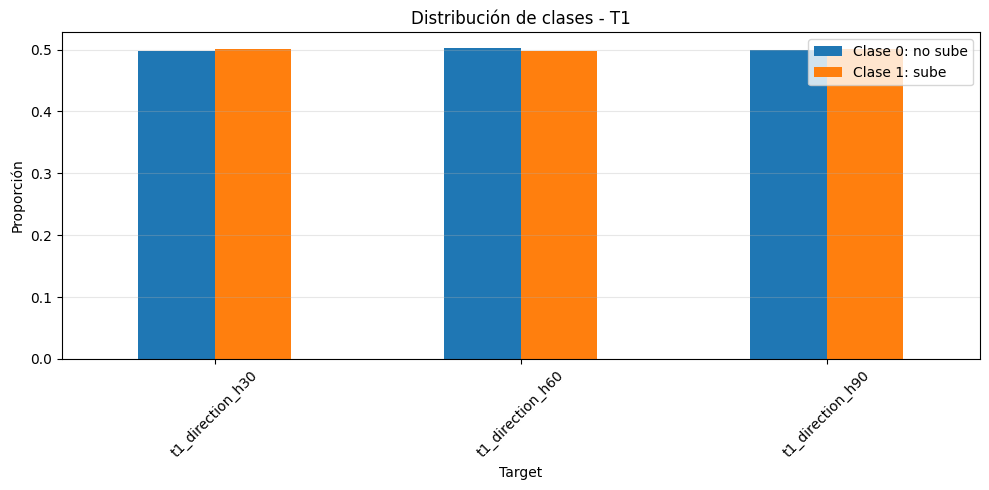

,target,horizon,class_0_count,class_1_count,class_0_ratio,class_1_ratio,balance_gap,balance_status
0,t1_direction_h30,30,444457,447617,0.498229,0.501771,0.003542,balanceado
1,t1_direction_h60,60,448509,443565,0.502771,0.497229,0.005542,balanceado
2,t1_direction_h90,90,445638,446436,0.499553,0.500447,0.000895,balanceado


In [25]:
# =========================================================
# 3.2 Distribución de clases - T1
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

summary_t1_classes = []

for H in horizons:
    target_col = f"t1_direction_h{H}"

    counts = df_t1[target_col].value_counts().sort_index()
    ratios = df_t1[target_col].value_counts(normalize=True).sort_index()

    summary_t1_classes.append({
        "target": target_col,
        "horizon": H,
        "class_0_count": counts.get(0, 0),
        "class_1_count": counts.get(1, 0),
        "class_0_ratio": ratios.get(0, 0),
        "class_1_ratio": ratios.get(1, 0),
        "balance_gap": abs(ratios.get(1, 0) - ratios.get(0, 0))
    })

df_t1_class_distribution = pd.DataFrame(summary_t1_classes)

display(df_t1_class_distribution)

# =========================================================
# Gráfico de distribución de clases - T1
# =========================================================

plot_df = df_t1_class_distribution.set_index("target")[
    ["class_0_ratio", "class_1_ratio"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Distribución de clases - T1")
ax.set_xlabel("Target")
ax.set_ylabel("Proporción")
ax.legend(["Clase 0: no sube", "Clase 1: sube"])
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# Interpretación rápida del balance
# =========================================================

df_t1_class_distribution["balance_status"] = pd.cut(
    df_t1_class_distribution["balance_gap"],
    bins=[-0.01, 0.05, 0.15, 1.0],
    labels=["balanceado", "moderadamente desbalanceado", "desbalanceado"]
)

display(df_t1_class_distribution)



Este análisis permite identificar si T1 mantiene una distribución razonablemente equilibrada entre clases para los horizontes de 30, 60 y 90 minutos.
Un `balance_gap` bajo indica mayor equilibrio entre clases, mientras que valores elevados sugieren mayor predominancia de una clase sobre la otra.

**Observaciones rápidas:**

- Los tres horizontes presentan una distribución extremadamente balanceada entre clases, con proporciones muy cercanas al 50/50.
- El balance_gap es prácticamente nulo en todos los casos, indicando ausencia de desbalance estadístico significativo.
- El horizonte de 90 minutos presenta el mejor equilibrio entre clases (balance_gap = 0.000895).
- Desde el punto de vista estadístico, T1 constituye un target favorable para modelos de clasificación, ya que no requiere técnicas especiales de balanceo de clases.
- Sin embargo, este alto equilibrio también puede sugerir una elevada dificultad predictiva, consistente con la naturaleza ruidosa y eficiente de los mercados financieros.

### **3.3 Frecuencia operativa**

Aunque T1 no representa explícitamente trades reales como T3 o T4, sí permite analizar la frecuencia de señales direccionales generadas por el target.

En este contexto, la frecuencia operativa puede interpretarse como la densidad de oportunidades direccionales presentes en el dataset para cada horizonte temporal.

Debido a que T1 genera una etiqueta para prácticamente cada observación disponible, este análisis permite evaluar:

- densidad de señales
- persistencia direccional
- proporción efectiva de observaciones utilizables
- impacto del horizonte sobre la disponibilidad de datos

,target,horizon,total_rows,valid_signals,signal_rate,long_signals,short_signals,long_ratio,short_ratio
0,t1_direction_h30,30,892074,892074,1.0,447617,444457,0.501771,0.498229
1,t1_direction_h60,60,892074,892074,1.0,443565,448509,0.497229,0.502771
2,t1_direction_h90,90,892074,892074,1.0,446436,445638,0.500447,0.499553


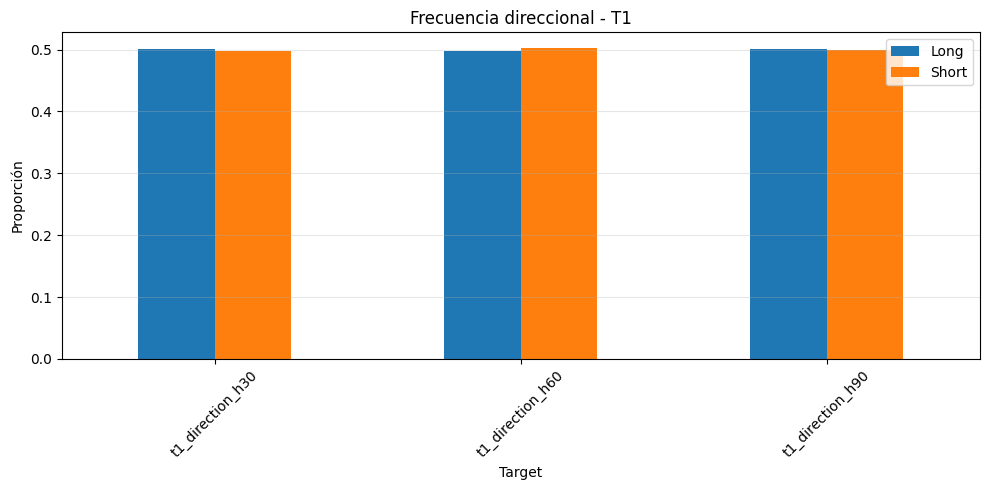

In [27]:
# =========================================================
# 3.3 Frecuencia operativa - T1
# =========================================================

summary_t1_frequency = []

total_rows = len(df_t1)

for H in horizons:

    target_col = f"t1_direction_h{H}"

    valid_signals = df_t1[target_col].notna().sum()

    long_signals = (df_t1[target_col] == 1).sum()
    short_signals = (df_t1[target_col] == 0).sum()

    signal_rate = valid_signals / total_rows

    long_ratio = long_signals / valid_signals
    short_ratio = short_signals / valid_signals

    summary_t1_frequency.append({
        "target": target_col,
        "horizon": H,
        "total_rows": total_rows,
        "valid_signals": valid_signals,
        "signal_rate": signal_rate,
        "long_signals": long_signals,
        "short_signals": short_signals,
        "long_ratio": long_ratio,
        "short_ratio": short_ratio
    })

df_t1_frequency = pd.DataFrame(summary_t1_frequency)

display(df_t1_frequency)

# =========================================================
# Visualización frecuencia direccional
# =========================================================

plot_df = df_t1_frequency.set_index("target")[
    ["long_ratio", "short_ratio"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Frecuencia direccional - T1")
ax.set_xlabel("Target")
ax.set_ylabel("Proporción")
ax.legend(["Long", "Short"])
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Este análisis permitirá comparar posteriormente la densidad operativa de T1 frente a targets más selectivos como T2, T3 y T4, donde la incorporación de thresholds, reglas operativas y barreras reducirá progresivamente la cantidad efectiva de señales disponibles.

**Observaciones rápidas:**

* T1 genera señales para prácticamente todas las observaciones disponibles (`signal_rate = 1.0`), lo que confirma su carácter altamente denso y no selectivo.

* La frecuencia direccional permanece extremadamente equilibrada entre señales long y short en los tres horizontes analizados.

* No se observa directional bias significativo en ninguno de los horizontes evaluados.

* El aumento del horizonte temporal no modifica sustancialmente la densidad operativa ni la distribución de señales.

* Desde el punto de vista operativo, T1 constituye un target de alta frecuencia y baja selectividad, consistente con una formulación direccional pura basada únicamente en el signo del retorno forward.


### **3.4. Estabilidad Temporal**

Uno de los aspectos más importantes en problemas de Machine Learning financiero consiste en evaluar si las propiedades estadísticas del target permanecen relativamente estables a lo largo del tiempo.

En mercados financieros, es frecuente observar cambios estructurales asociados a:

* volatilidad
* eventos macroeconómicos
* cambios de régimen
* comportamiento de participantes
* variaciones en liquidez

Como consecuencia, un target que parece adecuadamente balanceado en términos globales puede presentar períodos específicos con distribuciones significativamente distintas.

El objetivo de esta sección consiste en analizar la estabilidad temporal de T1 mediante:

* comportamiento mensual
* comportamiento trimestral
* estabilidad rolling
* drift temporal
* cambios de distribución en el tiempo


#### **3.4.1 Distribución mensual de clases**

In [28]:
# =========================================================
# 3.4.1 Distribución mensual de clases - T1
# =========================================================

df_t1["year_month"] = df_t1["date"].dt.to_period("M")

monthly_results_t1 = []

for H in horizons:

    target_col = f"t1_direction_h{H}"

    monthly_stats = (
        df_t1
        .groupby("year_month")[target_col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reset_index()
    )

    monthly_stats.columns = [
        "year_month",
        "class_0_ratio",
        "class_1_ratio"
    ]

    monthly_stats["target"] = target_col
    monthly_stats["horizon"] = H

    monthly_stats["balance_gap"] = (
        monthly_stats["class_1_ratio"] -
        monthly_stats["class_0_ratio"]
    ).abs()

    monthly_results_t1.append(monthly_stats)

df_t1_monthly = pd.concat(monthly_results_t1, ignore_index=True)

display(df_t1_monthly.head())

,year_month,class_0_ratio,class_1_ratio,target,horizon,balance_gap
0,2020-01,0.494779,0.505221,t1_direction_h30,30,0.010441
1,2020-02,0.513551,0.486449,t1_direction_h30,30,0.027103
2,2020-03,0.496203,0.503797,t1_direction_h30,30,0.007594
3,2020-04,0.486213,0.513787,t1_direction_h30,30,0.027575
4,2020-05,0.488787,0.511213,t1_direction_h30,30,0.022425


#### **3.4.2 Evolución temporal del balance**


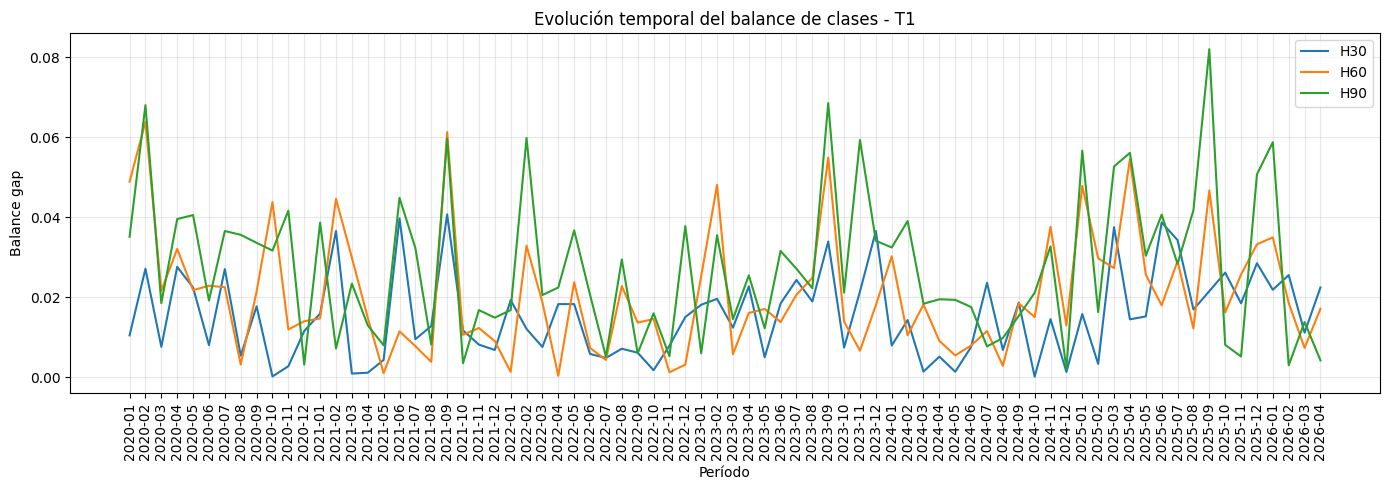

In [29]:
# =========================================================
# Evolución temporal del balance
# =========================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

for H in horizons:

    temp = df_t1_monthly[
        df_t1_monthly["horizon"] == H
    ]

    ax.plot(
        temp["year_month"].astype(str),
        temp["balance_gap"],
        label=f"H{H}"
    )

ax.set_title("Evolución temporal del balance de clases - T1")
ax.set_xlabel("Período")
ax.set_ylabel("Balance gap")
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### **3.4.3 Estadísticas de estabilidad temporal**


In [30]:
# =========================================================
# Estadísticas resumen de estabilidad temporal
# =========================================================

stability_summary_t1 = (
    df_t1_monthly
    .groupby("horizon")["balance_gap"]
    .agg([
        "mean",
        "std",
        "min",
        "max"
    ])
    .reset_index()
)

stability_summary_t1.columns = [
    "horizon",
    "mean_balance_gap",
    "std_balance_gap",
    "min_balance_gap",
    "max_balance_gap"
]

display(stability_summary_t1)

,horizon,mean_balance_gap,std_balance_gap,min_balance_gap,max_balance_gap
0,30,0.015433,0.010768,0.000144,0.040698
1,60,0.020808,0.015070,0.000332,0.063822
2,90,0.027507,0.018353,0.002030,0.082007


#### **3.4.4 Rolling balance stability**

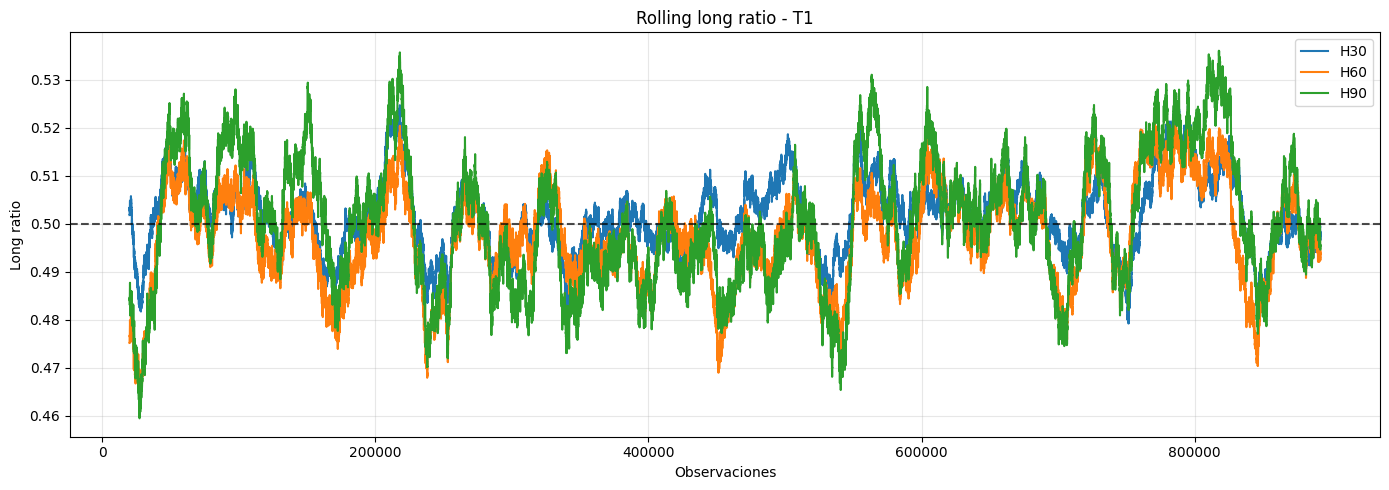

In [31]:
# =========================================================
# Rolling stability del balance
# =========================================================

rolling_window = 20000

fig, ax = plt.subplots(figsize=(14, 5))

for H in horizons:

    target_col = f"t1_direction_h{H}"

    rolling_long_ratio = (
        df_t1[target_col]
        .rolling(rolling_window)
        .mean()
    )

    ax.plot(
        rolling_long_ratio,
        label=f"H{H}"
    )

ax.axhline(0.5, color="black", linestyle="--", alpha=0.7)

ax.set_title("Rolling long ratio - T1")
ax.set_xlabel("Observaciones")
ax.set_ylabel("Long ratio")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Este análisis permitirá detectar posibles períodos de:

* directional bias
* desbalance temporal
* drift estadístico
* cambios estructurales del mercado

aspectos especialmente relevantes en contextos de Machine Learning aplicado a series financieras no estacionarias.

**Observaciones rápidas:**

* T1 mantiene una estabilidad temporal relativamente alta en los tres horizontes analizados, con balances mensuales generalmente cercanos al 50/50.

* No se observan períodos prolongados de directional bias persistente, lo que sugiere ausencia de drift estructural severo en la distribución de clases.

* El horizonte de 30 minutos presenta la mayor estabilidad temporal, con el menor `mean_balance_gap` y menor volatilidad en el balance mensual.

* A medida que aumenta el horizonte temporal, también aumenta la variabilidad del balance de clases, especialmente en H90.

* El análisis rolling confirma que las proporciones long/short oscilan alrededor de 0.50 durante todo el período analizado, aunque con desviaciones transitorias asociadas probablemente a cambios de régimen o condiciones específicas de mercado.

* En términos generales, T1 presenta una distribución temporal robusta y estable, favorable para procesos de entrenamiento y validación temporal en modelos de Machine Learning financiero.



### **3.5. Sensibilidad paramétrica - T1**


**Sensibilidad al horizonte temporal**

En el caso de T1, el principal parámetro de construcción corresponde al horizonte temporal (H) utilizado para calcular el retorno forward.

Modificar el horizonte implica alterar directamente la escala temporal del problema predictivo, afectando potencialmente:

* balance estadístico de clases
* estabilidad temporal
* frecuencia de señales
* nivel de ruido presente en el target
* persistencia de movimientos direccionales

Con el objetivo de evaluar esta sensibilidad, se analizaron tres horizontes distintos:

* (H = 30) minutos
* (H = 60) minutos
* (H = 90) minutos

Los resultados obtenidos muestran que el target T1 mantiene una distribución altamente balanceada en los tres horizontes evaluados. Sin embargo, se observan diferencias relevantes en términos de estabilidad temporal.

A medida que aumenta el horizonte temporal:

* aumenta ligeramente la variabilidad del balance de clases
* crece el `mean_balance_gap`
* se incrementa la volatilidad temporal de las proporciones direccionales

En particular:

* H30 presenta la mayor estabilidad estadística
* H60 muestra un incremento moderado de variabilidad
* H90 exhibe mayores oscilaciones temporales y directional bias transitorios

El análisis rolling confirma que los tres horizontes permanecen relativamente cercanos al equilibrio teórico del 50/50, aunque los horizontes más amplios presentan desviaciones más pronunciadas durante ciertos períodos específicos de mercado.

Estos resultados sugieren que horizontes más largos podrían incorporar estructuras direccionales más persistentes, pero también una mayor sensibilidad a cambios de régimen y condiciones de mercado no estacionarias.

En consecuencia, existe un compromiso natural entre:

* estabilidad estadística
* persistencia direccional
* sensibilidad al ruido
* complejidad temporal del problema predictivo

aspecto que será especialmente relevante en las etapas posteriores de modelado y evaluación operativa.


### **3.6. Análisis por régimen intradiario**


Además del análisis global del target T1, resulta relevante estudiar cómo cambia su comportamiento estadístico según distintos regímenes intradiarios representados por la variable `regime_id`.

En mercados intradiarios, las condiciones de negociación pueden variar significativamente a lo largo del día debido a factores como:

* apertura de mercado
* aumento o disminución de liquidez
* volatilidad asociada a noticias
* participación institucional
* solapamiento entre sesiones

Como consecuencia, un target que parece estable de manera global podría presentar comportamientos distintos dependiendo del régimen operativo considerado.

El objetivo de esta sección consiste en evaluar si T1 presenta diferencias relevantes entre regímenes intradiarios en términos de:

* distribución de clases
* directional bias
* frecuencia de señales
* estabilidad estadística
* comportamiento direccional


#### **3.6.1 Distribución de clases por `regime_id`**


In [33]:
# =========================================================
# 3.6.1 Distribución de clases por régimen - T1
# =========================================================

regime_results_t1 = []

for H in horizons:

    target_col = f"t1_direction_h{H}"

    temp = (
        df_t1
        .groupby("regime_id")[target_col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reset_index()
    )

    temp.columns = [
        "regime_id",
        "class_0_ratio",
        "class_1_ratio"
    ]

    temp["target"] = target_col
    temp["horizon"] = H

    temp["balance_gap"] = (
        temp["class_1_ratio"] -
        temp["class_0_ratio"]
    ).abs()

    regime_results_t1.append(temp)

df_t1_regime = pd.concat(regime_results_t1, ignore_index=True)

display(df_t1_regime)

,regime_id,class_0_ratio,class_1_ratio,target,horizon,balance_gap
0,0,0.504892,0.495108,t1_direction_h30,30,0.009784
1,1,0.479878,0.520122,t1_direction_h30,30,0.040243
2,2,0.477756,0.522244,t1_direction_h30,30,0.044488
3,3,0.498602,0.501398,t1_direction_h30,30,0.002796
4,4,0.538349,0.461651,t1_direction_h30,30,0.076698
5,0,0.508910,0.491090,t1_direction_h60,60,0.017819
6,1,0.451733,0.548267,t1_direction_h60,60,0.096534
7,2,0.490726,0.509274,t1_direction_h60,60,0.018549
8,3,0.508841,0.491159,t1_direction_h60,60,0.017681
9,4,0.537067,0.462933,t1_direction_h60,60,0.074134


#### **3.6.2 Visualización del balance por régimen**


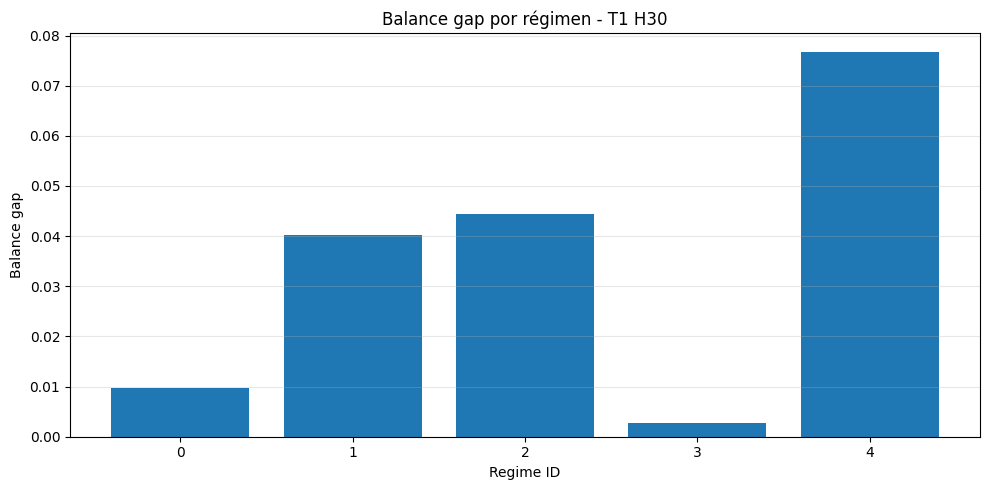

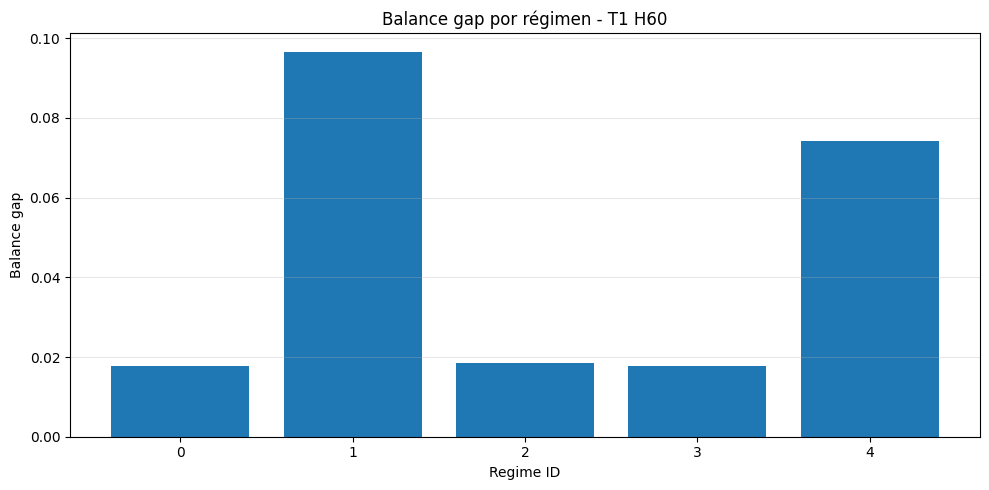

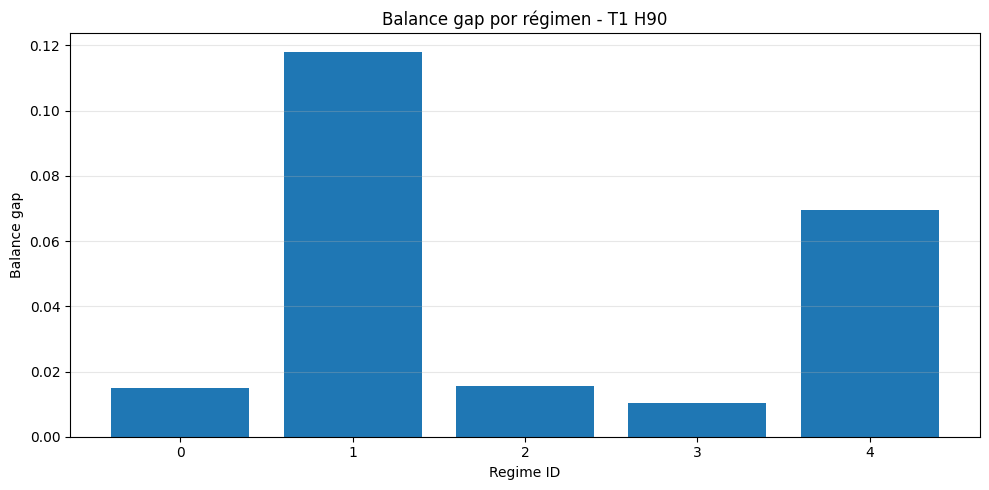

In [34]:
# =========================================================
# Balance gap por régimen
# =========================================================

import matplotlib.pyplot as plt

for H in horizons:

    temp = df_t1_regime[
        df_t1_regime["horizon"] == H
    ]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        temp["regime_id"].astype(str),
        temp["balance_gap"]
    )

    ax.set_title(f"Balance gap por régimen - T1 H{H}")
    ax.set_xlabel("Regime ID")
    ax.set_ylabel("Balance gap")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

#### **3.6.3 Frecuencia de observaciones por régimen**

In [35]:
# =========================================================
# Cantidad de observaciones por régimen
# =========================================================

regime_frequency_t1 = (
    df_t1["regime_id"]
    .value_counts()
    .sort_index()
    .reset_index()
)

regime_frequency_t1.columns = [
    "regime_id",
    "n_observations"
]

regime_frequency_t1["ratio"] = (
    regime_frequency_t1["n_observations"] /
    regime_frequency_t1["n_observations"].sum()
)

display(regime_frequency_t1)

,regime_id,n_observations,ratio
0,0,225262,0.252515
1,1,88860,0.099611
2,2,88901,0.099657
3,3,444591,0.498379
4,4,44460,0.049839


#### **3.6.4 Directional bias por régimen**


In [36]:
# =========================================================
# Directional bias por régimen
# =========================================================

directional_bias_t1 = []

for H in horizons:

    target_col = f"t1_direction_h{H}"

    temp = (
        df_t1
        .groupby("regime_id")[target_col]
        .mean()
        .reset_index()
    )

    temp.columns = [
        "regime_id",
        "long_ratio"
    ]

    temp["target"] = target_col
    temp["horizon"] = H

    temp["directional_bias"] = (
        temp["long_ratio"] - 0.5
    )

    directional_bias_t1.append(temp)

df_directional_bias_t1 = pd.concat(
    directional_bias_t1,
    ignore_index=True
)

display(df_directional_bias_t1)

,regime_id,long_ratio,target,horizon,directional_bias
0,0,0.495108,t1_direction_h30,30,-0.004892
1,1,0.520122,t1_direction_h30,30,0.020122
2,2,0.522244,t1_direction_h30,30,0.022244
3,3,0.501398,t1_direction_h30,30,0.001398
4,4,0.461651,t1_direction_h30,30,-0.038349
5,0,0.491090,t1_direction_h60,60,-0.008910
6,1,0.548267,t1_direction_h60,60,0.048267
7,2,0.509274,t1_direction_h60,60,0.009274
8,3,0.491159,t1_direction_h60,60,-0.008841
9,4,0.462933,t1_direction_h60,60,-0.037067


#### **3.6.5 Interpretación del análisis por régimen**


Este análisis permitirá identificar:

* regímenes con mayor directional bias
* períodos intradiarios más balanceados
* regímenes potencialmente más estables
* segmentos temporales con mayor ruido estadístico
* posibles diferencias estructurales entre horizontes

Estos resultados serán especialmente relevantes en etapas posteriores de modelado, ya que podrían justificar:

* modelos específicos por régimen
* filtrado de determinados períodos del día
* selección de targets según contexto intradiario
* restricciones operativas basadas en estabilidad estadística

En consecuencia, el análisis por `regime_id` constituye una herramienta importante para evaluar no solo la robustez global de T1, sino también su comportamiento bajo distintos contextos operativos intradiarios.

**Observaciones rápidas:**

* El análisis por `regime_id` muestra que el comportamiento de T1 no es homogéneo entre regímenes intradiarios, a pesar del fuerte balance global observado previamente.

* Los regímenes `0` y `3` presentan los balances más estables y cercanos al 50/50 en los tres horizontes evaluados.

* El régimen `1` exhibe un directional bias positivo persistente, especialmente en H60 y H90, donde predominan señales long.

* El régimen `4` presenta el directional bias negativo más fuerte, con predominancia consistente de señales short en todos los horizontes.

* A medida que aumenta el horizonte temporal, los directional bias por régimen se vuelven más pronunciados, especialmente en los regímenes `1` y `4`.

* El régimen `3` concentra aproximadamente el 50% de todas las observaciones del dataset, convirtiéndose en el contexto operativo dominante.

* Los resultados sugieren que ciertas dinámicas direccionales podrían estar asociadas a períodos intradiarios específicos, lo que potencialmente justificaría estrategias o modelos diferenciados por régimen en etapas posteriores de la investigación.

* En términos generales, aunque T1 presenta estabilidad global, el análisis segmentado revela estructuras intradiarias relevantes que no son visibles en el análisis agregado del dataset.


### **3.7. Observaciones e interpretación**

El análisis estadístico realizado sobre T1 muestra que el target presenta propiedades globales relativamente robustas desde el punto de vista del balance de clases y estabilidad temporal.

En los tres horizontes evaluados, la distribución entre señales long y short permanece extremadamente cercana al equilibrio teórico del 50/50, sin evidencia de desbalances estructurales severos. Esta característica resulta favorable para el entrenamiento de modelos de clasificación, ya que reduce la necesidad de técnicas específicas de balanceo de clases.

Asimismo, T1 exhibe una elevada estabilidad temporal a nivel agregado, manteniendo proporciones direccionales relativamente consistentes a lo largo del período analizado. El análisis rolling confirma que las oscilaciones del balance permanecen acotadas alrededor del equilibrio esperado, aunque con variaciones transitorias asociadas probablemente a cambios de régimen y condiciones específicas de mercado.

Sin embargo, el análisis por horizonte temporal muestra que horizontes más amplios introducen una mayor variabilidad estadística y directional bias transitorio. En particular, H90 presenta mayores desviaciones temporales respecto al equilibrio observado en H30, sugiriendo una mayor sensibilidad a dinámicas estructurales del mercado.

Por otro lado, el análisis segmentado por `regime_id` revela que la aparente estabilidad global de T1 oculta diferencias relevantes entre distintos contextos intradiarios. Algunos regímenes presentan directional bias persistentes, especialmente en horizontes más amplios, lo que sugiere que ciertas dinámicas direccionales podrían estar asociadas a períodos específicos del día.

Desde el punto de vista operativo, T1 constituye un target altamente denso y poco selectivo, ya que genera señales para prácticamente todas las observaciones disponibles. Esta característica simplifica el problema de clasificación, pero también implica una elevada exposición al ruido financiero y una limitada capacidad de filtrado de movimientos poco relevantes.

En consecuencia, aunque T1 presenta propiedades estadísticas favorables en términos de balance y estabilidad, su formulación puramente direccional continúa siendo relativamente abstracta desde el punto de vista operativo.

Esta limitación motiva naturalmente la transición hacia targets más selectivos y estructurados, comenzando por T2, donde se introducen umbrales mínimos de relevancia con el objetivo de reducir ruido y mejorar la calidad económica de las señales generadas.


## **4. T2 - Investigación estadística**

### **4.1 Construcción práctica de T2**


T2 redefine el problema como una clasificación ternaria, incorporando un umbral mínimo para separar movimientos relevantes de movimientos poco significativos.

Las clases se definen como:

* `1`: movimiento positivo significativo
* `-1`: movimiento negativo significativo
* `0`: movimiento no significativo

A diferencia de T1, que clasifica cualquier variación positiva o negativa, T2 busca filtrar fluctuaciones pequeñas que probablemente correspondan a ruido de mercado.

Para cada horizonte temporal $H$, se calcula primero el movimiento futuro en puntos:

$$
\Delta_{t,H} = P_{t+H} - P_t
$$

Luego se define un threshold empírico a partir del percentil $p$ del valor absoluto del movimiento futuro:

$$
threshold_{H,p} = percentile_p(|\Delta_{t,H}|)
$$

Finalmente, el target T2 se construye como:

$$
T2 =
\begin{cases}
1, & \Delta_{t,H} > threshold_{H,p} \\
-1, & \Delta_{t,H} < -threshold_{H,p} \\
0, & |\Delta_{t,H}| \leq threshold_{H,p}
\end{cases}
$$

donde:

- $\Delta_{t,H}$: variación del precio en el horizonte $H$
- $threshold_{H,p}$: umbral calculado para el horizonte $H$ utilizando el percentil $p$

En esta investigación se evaluarán los horizontes de 30, 60 y 90 minutos, utilizando distintos percentiles para analizar cómo cambia el balance de clases, la frecuencia de señales y la estabilidad del target.

In [38]:
# =========================================================
# 4.1 Construcción práctica de T2
# =========================================================

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Copia de trabajo
df_t2 = mnq_intraday.copy()

# Asegurar orden temporal
df_t2["date"] = pd.to_datetime(df_t2["date"])
df_t2 = df_t2.sort_values("date").reset_index(drop=True)

# Horizontes y percentiles a evaluar
horizons = [30, 60, 90]
percentiles = [30, 40, 50, 55, 60, 65, 70]

# =========================================================
# 1) Calcular movimientos futuros en puntos
# =========================================================

for H in horizons:
    df_t2[f"delta_h{H}"] = df_t2["close"].shift(-H) - df_t2["close"]

# =========================================================
# 2) Calcular thresholds empíricos por horizonte y percentil
# =========================================================

threshold_rows = []

for H in horizons:

    delta_col = f"delta_h{H}"
    abs_delta = df_t2[delta_col].abs().dropna()

    for p in percentiles:

        threshold = np.percentile(abs_delta, p)

        threshold_rows.append({
            "horizon": H,
            "percentile": p,
            "threshold_pts": threshold,
            "threshold_usd": threshold * 2  # MNQ: 1 punto = 2 USD
        })

df_t2_thresholds = pd.DataFrame(threshold_rows)

# =========================================================
# Mostrar tabla de thresholds
# =========================================================

display(Markdown("## Grid de thresholds empíricos - T2"))
display(df_t2_thresholds)

# =========================================================
# 3) Construir targets T2 para cada horizonte y percentil
# =========================================================

for _, row in df_t2_thresholds.iterrows():

    H = int(row["horizon"])
    p = int(row["percentile"])
    threshold = row["threshold_pts"]

    delta_col = f"delta_h{H}"
    target_col = f"t2_p{p}_h{H}"

    df_t2[target_col] = np.select(
        [
            df_t2[delta_col] > threshold,
            df_t2[delta_col] < -threshold
        ],
        [
            1,
            -1
        ],
        default=0
    )

# =========================================================
# Eliminar filas sin información futura suficiente
# =========================================================

delta_cols_t2 = [f"delta_h{H}" for H in horizons]

df_t2 = df_t2.dropna(subset=delta_cols_t2).reset_index(drop=True)

# =========================================================
# Revisión inicial de targets construidos
# =========================================================

target_cols_t2 = [
    f"t2_p{p}_h{H}"
    for H in horizons
    for p in percentiles
]

display(Markdown("## Revisión inicial de targets T2"))

display(
    df_t2[
        ["date", "close"] +
        delta_cols_t2 +
        target_cols_t2[:6]
    ].head()
)

## Grid de thresholds empíricos - T2

,horizon,percentile,threshold_pts,threshold_usd
0,30,30,11.00,22.0
1,30,40,16.25,32.5
2,30,50,23.00,46.0
3,30,55,27.25,54.5
4,30,60,32.25,64.5
5,30,65,38.50,77.0
6,30,70,46.25,92.5
7,60,30,17.25,34.5
8,60,40,25.50,51.0
9,60,50,36.00,72.0


## Revisión inicial de targets T2

,date,close,delta_h30,delta_h60,delta_h90,t2_p30_h30,t2_p40_h30,t2_p50_h30,t2_p55_h30,t2_p60_h30,t2_p65_h30
0,2020-01-02,8818.75,15.75,25.25,-5.5,1,0,0,0,0,0
1,2020-01-02,8837.50,-3.75,6.50,-10.0,0,0,0,0,0,0
2,2020-01-02,8838.25,-1.50,6.00,-28.5,0,0,0,0,0,0
3,2020-01-02,8841.50,-4.25,0.75,-12.5,0,0,0,0,0,0
4,2020-01-02,8842.00,0.00,-0.75,-9.5,0,0,0,0,0,0


Con esto quedan construidas múltiples variantes de T2, combinando horizontes y percentiles. Luego evaluamos cuál configuración produce mejor balance, frecuencia operativa y estabilidad.



### **4.2 Distribución de clases**

A diferencia de T1, el target T2 introduce una tercera clase asociada a movimientos no significativos. Como consecuencia, la distribución de clases pasa a depender directamente de:

- horizonte temporal
- threshold utilizado
- magnitud de los movimientos del mercado

En general, thresholds más bajos producen targets más densos y con menor proporción de clase neutra, mientras que thresholds más altos generan targets más selectivos y con mayor cantidad de observaciones clasificadas como 0.

El objetivo de esta sección consiste en analizar cómo distintas configuraciones de T2 afectan:

- balance entre clases
- frecuencia de señales significativas
- proporción de clase neutra
- selectividad del target
- dificultad potencial del problema de clasificación

## Distribución de clases - T2

,target,horizon,percentile,class_-1_count,class_0_count,class_1_count,class_-1_ratio,class_0_ratio,class_1_ratio,signal_ratio,neutral_ratio,long_short_gap
0,t2_p30_h30,30,30,307999,270104,313971,0.345262,0.302782,0.351956,0.697218,0.302782,0.006695
1,t2_p40_h30,30,40,263714,358950,269410,0.295619,0.402377,0.302004,0.597623,0.402377,0.006385
2,t2_p50_h30,30,50,220430,446882,224762,0.247098,0.500947,0.251954,0.499053,0.500947,0.004856
3,t2_p55_h30,30,55,198716,491368,201990,0.222757,0.550815,0.226427,0.449185,0.550815,0.003670
4,t2_p60_h30,30,60,176916,535374,179784,0.198320,0.600145,0.201535,0.399855,0.600145,0.003215
5,t2_p65_h30,30,65,154423,580527,157124,0.173106,0.650761,0.176133,0.349239,0.650761,0.003028
6,t2_p70_h30,30,70,131912,625437,134725,0.147871,0.701104,0.151024,0.298896,0.701104,0.003153
7,t2_p30_h60,60,30,310525,269486,312063,0.348093,0.302089,0.349817,0.697911,0.302089,0.001724
8,t2_p40_h60,60,40,264432,358575,269067,0.296424,0.401957,0.301620,0.598043,0.401957,0.005196
9,t2_p50_h60,60,50,218486,446805,226783,0.244919,0.500861,0.254220,0.499139,0.500861,0.009301


## Resumen compacto de distribución - T2

,target,horizon,percentile,class_-1_ratio,class_0_ratio,class_1_ratio,signal_ratio,neutral_ratio,long_short_gap
0,t2_p30_h30,30,30,0.345262,0.302782,0.351956,0.697218,0.302782,0.006695
1,t2_p40_h30,30,40,0.295619,0.402377,0.302004,0.597623,0.402377,0.006385
2,t2_p50_h30,30,50,0.247098,0.500947,0.251954,0.499053,0.500947,0.004856
3,t2_p55_h30,30,55,0.222757,0.550815,0.226427,0.449185,0.550815,0.003670
4,t2_p60_h30,30,60,0.198320,0.600145,0.201535,0.399855,0.600145,0.003215
5,t2_p65_h30,30,65,0.173106,0.650761,0.176133,0.349239,0.650761,0.003028
6,t2_p70_h30,30,70,0.147871,0.701104,0.151024,0.298896,0.701104,0.003153
7,t2_p30_h60,60,30,0.348093,0.302089,0.349817,0.697911,0.302089,0.001724
8,t2_p40_h60,60,40,0.296424,0.401957,0.301620,0.598043,0.401957,0.005196
9,t2_p50_h60,60,50,0.244919,0.500861,0.254220,0.499139,0.500861,0.009301


## Señales vs clase neutra - T2

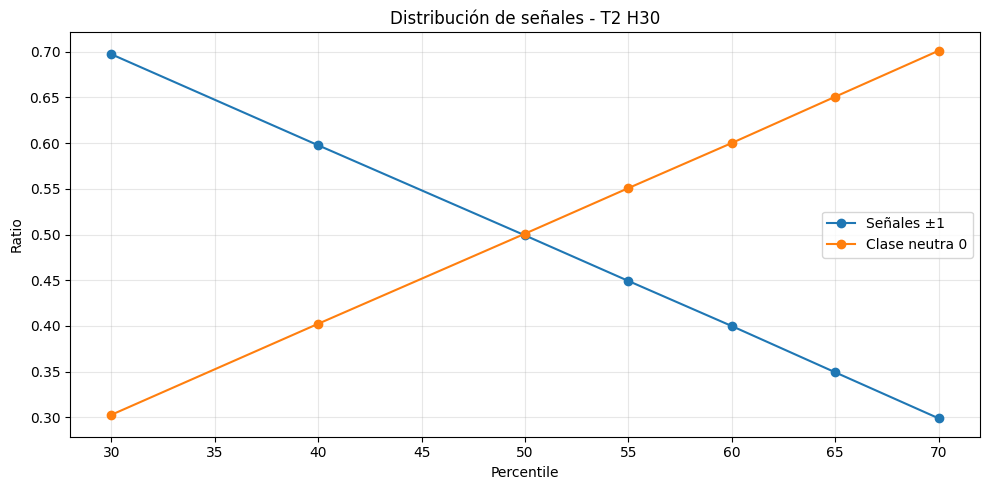

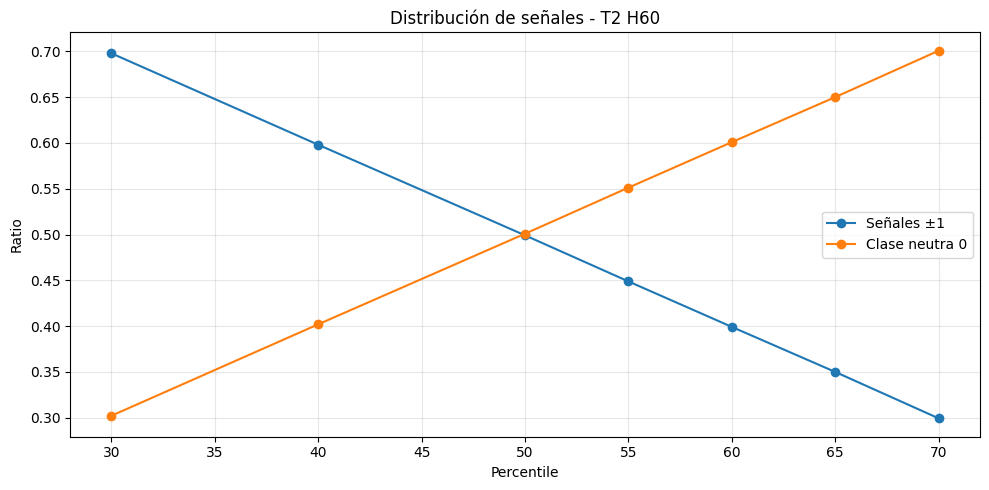

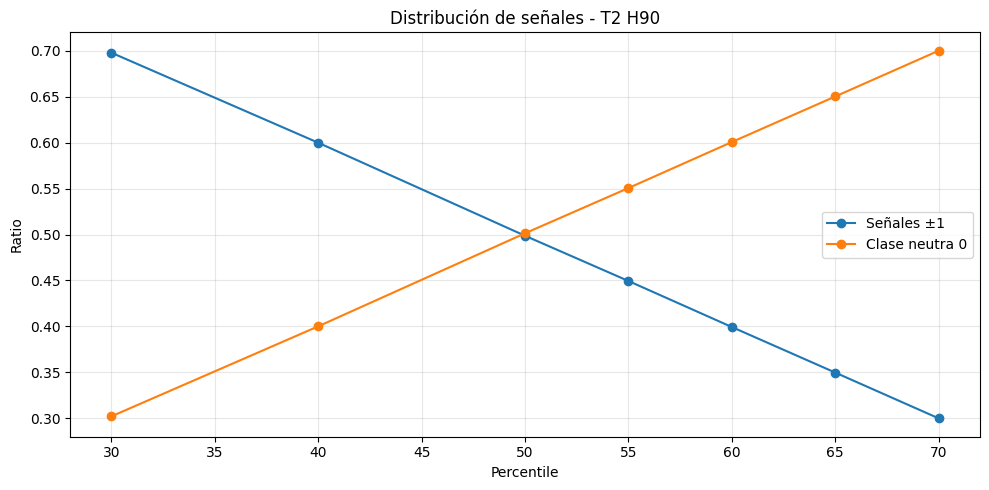

## Balance long vs short - T2

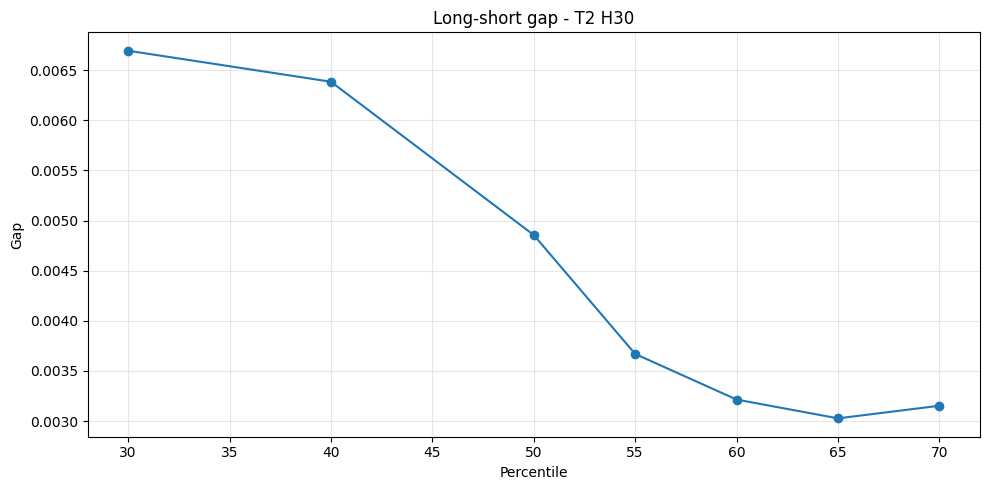

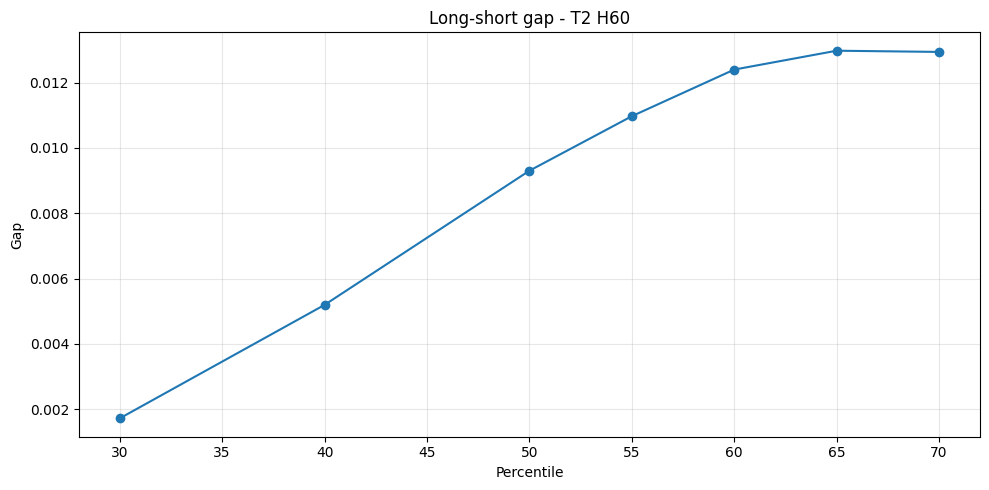

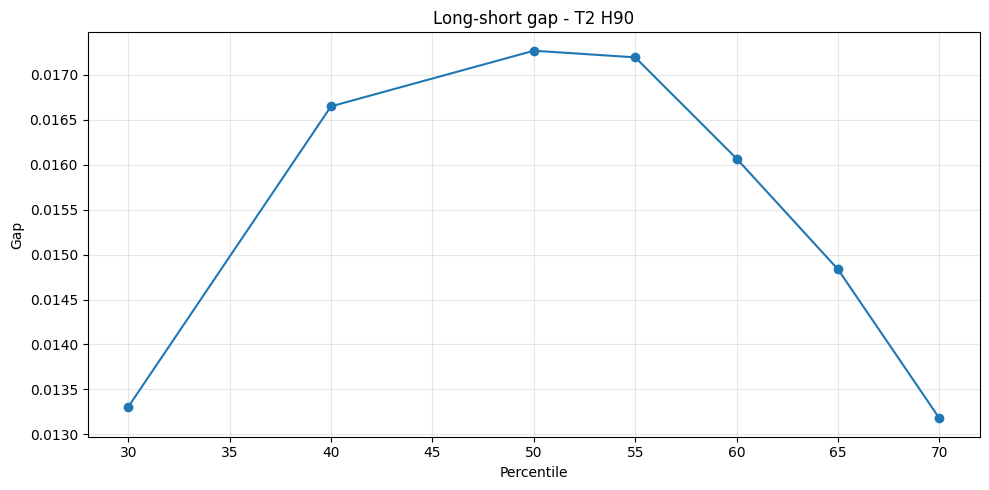

In [39]:
# =========================================================
# 4.2 Distribución de clases - T2
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

summary_t2_classes = []

for H in horizons:

    for p in percentiles:

        target_col = f"t2_p{p}_h{H}"

        counts = (
            df_t2[target_col]
            .value_counts()
            .sort_index()
        )

        ratios = (
            df_t2[target_col]
            .value_counts(normalize=True)
            .sort_index()
        )

        summary_t2_classes.append({
            "target": target_col,
            "horizon": H,
            "percentile": p,

            "class_-1_count": counts.get(-1, 0),
            "class_0_count": counts.get(0, 0),
            "class_1_count": counts.get(1, 0),

            "class_-1_ratio": ratios.get(-1, 0),
            "class_0_ratio": ratios.get(0, 0),
            "class_1_ratio": ratios.get(1, 0),

            "signal_ratio": (
                ratios.get(-1, 0) +
                ratios.get(1, 0)
            ),

            "neutral_ratio": ratios.get(0, 0),

            "long_short_gap": abs(
                ratios.get(1, 0) -
                ratios.get(-1, 0)
            )
        })

df_t2_class_distribution = pd.DataFrame(summary_t2_classes)

# =========================================================
# Mostrar distribución completa
# =========================================================

display(Markdown("## Distribución de clases - T2"))
display(df_t2_class_distribution)

# =========================================================
# Resumen compacto
# =========================================================

summary_view_t2 = df_t2_class_distribution[
    [
        "target",
        "horizon",
        "percentile",
        "class_-1_ratio",
        "class_0_ratio",
        "class_1_ratio",
        "signal_ratio",
        "neutral_ratio",
        "long_short_gap"
    ]
]

display(Markdown("## Resumen compacto de distribución - T2"))
display(summary_view_t2)

# =========================================================
# Visualización señal vs clase neutra
# =========================================================

display(Markdown("## Señales vs clase neutra - T2"))

for H in horizons:

    temp = summary_view_t2[
        summary_view_t2["horizon"] == H
    ]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        temp["percentile"],
        temp["signal_ratio"],
        marker="o",
        label="Señales ±1"
    )

    ax.plot(
        temp["percentile"],
        temp["neutral_ratio"],
        marker="o",
        label="Clase neutra 0"
    )

    ax.set_title(f"Distribución de señales - T2 H{H}")
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Ratio")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# =========================================================
# Balance long vs short
# =========================================================

display(Markdown("## Balance long vs short - T2"))

for H in horizons:

    temp = summary_view_t2[
        summary_view_t2["horizon"] == H
    ]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        temp["percentile"],
        temp["long_short_gap"],
        marker="o"
    )

    ax.set_title(f"Long-short gap - T2 H{H}")
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Gap")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Este análisis permitirá estudiar cómo la incorporación de thresholds modifica progresivamente la estructura estadística del target respecto a T1, especialmente en términos de:

- reducción de ruido
- disminución de frecuencia operativa
- aumento de selectividad
- aparición de clase neutra
- cambios en balance estadístico

aspectos centrales para evaluar posteriormente la capacidad predictiva y operativa de T2.

**Observaciones rápidas:**

* La incorporación de thresholds modifica drásticamente la estructura estadística del target respecto a T1, introduciendo una clase neutra dominante a medida que aumenta el percentil.

* Existe una relación prácticamente lineal entre el percentil utilizado y la selectividad del target:

  * percentiles bajos → mayor cantidad de señales
  * percentiles altos → mayor proporción de clase neutra

* Los percentiles 30–40 generan targets relativamente densos, con aproximadamente 60–70% de señales operativas (`±1`).

* A partir de percentiles 60–70, la clase neutra supera ampliamente el 60–70% del dataset, reduciendo significativamente la frecuencia operativa.

* El percentil 50 produce una estructura casi perfectamente equilibrada:

  * ~50% señales
  * ~50% clase neutra

* El balance entre señales long y short permanece relativamente estable en H30, pero comienza a deteriorarse levemente en H60 y especialmente en H90.

* El horizonte H90 presenta el mayor `long_short_gap`, indicando aparición progresiva de directional bias en horizontes más amplios.

* A pesar del filtrado introducido por T2, el desbalance entre clases direccionales (`-1` vs `+1`) continúa siendo relativamente bajo en todas las configuraciones evaluadas.

* El comportamiento observado confirma que T2 introduce un mecanismo efectivo de reducción de ruido, permitiendo controlar explícitamente el tradeoff entre:

  * frecuencia operativa
  * selectividad
  * densidad de señales
  * estabilidad estadística

* En términos prácticos:

  * percentiles bajos → targets más frecuentes pero potencialmente más ruidosos
  * percentiles altos → targets más selectivos pero menos operables

* Estos resultados sugieren que percentiles intermedios (40–55) podrían representar un compromiso razonable entre densidad operativa y filtrado de ruido para etapas posteriores de modelado.


### **4.3 Frecuencia operativa**

Uno de los principales efectos introducidos por T2 corresponde a la reducción explícita de la frecuencia operativa mediante la incorporación de thresholds de relevancia.

A diferencia de T1, donde prácticamente todas las observaciones generan una señal direccional, T2 clasifica una parte importante del dataset como movimientos no significativos (0), filtrando fluctuaciones pequeñas potencialmente asociadas a ruido de mercado.

El objetivo de esta sección consiste en analizar cómo distintas configuraciones de horizonte y percentil afectan:

- cantidad de señales operativas
- frecuencia efectiva de trades potenciales
- densidad del target
- selectividad estadística
- balance entre señales y períodos neutrales

In [40]:
# =========================================================
# 4.3 Frecuencia operativa - T2
# =========================================================

from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt

frequency_rows_t2 = []

for H in horizons:

    for p in percentiles:

        target_col = f"t2_p{p}_h{H}"

        total_rows = len(df_t2)

        n_long = (df_t2[target_col] == 1).sum()
        n_short = (df_t2[target_col] == -1).sum()
        n_neutral = (df_t2[target_col] == 0).sum()

        n_signals = n_long + n_short

        signal_rate = n_signals / total_rows
        neutral_rate = n_neutral / total_rows

        long_ratio_signals = (
            n_long / n_signals
            if n_signals > 0 else 0
        )

        short_ratio_signals = (
            n_short / n_signals
            if n_signals > 0 else 0
        )

        frequency_rows_t2.append({
            "target": target_col,
            "horizon": H,
            "percentile": p,

            "total_rows": total_rows,

            "n_long": n_long,
            "n_short": n_short,
            "n_neutral": n_neutral,

            "n_signals": n_signals,

            "signal_rate": signal_rate,
            "neutral_rate": neutral_rate,

            "long_ratio_signals": long_ratio_signals,
            "short_ratio_signals": short_ratio_signals
        })

df_t2_frequency = pd.DataFrame(frequency_rows_t2)

display(Markdown("## Frecuencia operativa - T2"))
display(df_t2_frequency)

## Frecuencia operativa - T2

,target,horizon,percentile,total_rows,n_long,n_short,n_neutral,n_signals,signal_rate,neutral_rate,long_ratio_signals,short_ratio_signals
0,t2_p30_h30,30,30,892074,313971,307999,270104,621970,0.697218,0.302782,0.504801,0.495199
1,t2_p40_h30,30,40,892074,269410,263714,358950,533124,0.597623,0.402377,0.505342,0.494658
2,t2_p50_h30,30,50,892074,224762,220430,446882,445192,0.499053,0.500947,0.504865,0.495135
3,t2_p55_h30,30,55,892074,201990,198716,491368,400706,0.449185,0.550815,0.504085,0.495915
4,t2_p60_h30,30,60,892074,179784,176916,535374,356700,0.399855,0.600145,0.504020,0.495980
5,t2_p65_h30,30,65,892074,157124,154423,580527,311547,0.349239,0.650761,0.504335,0.495665
6,t2_p70_h30,30,70,892074,134725,131912,625437,266637,0.298896,0.701104,0.505275,0.494725
7,t2_p30_h60,60,30,892074,312063,310525,269486,622588,0.697911,0.302089,0.501235,0.498765
8,t2_p40_h60,60,40,892074,269067,264432,358575,533499,0.598043,0.401957,0.504344,0.495656
9,t2_p50_h60,60,50,892074,226783,218486,446805,445269,0.499139,0.500861,0.509317,0.490683


In [41]:
# =========================================================
# Resumen compacto frecuencia operativa
# =========================================================

summary_frequency_t2 = df_t2_frequency[
    [
        "target",
        "horizon",
        "percentile",
        "n_signals",
        "signal_rate",
        "neutral_rate",
        "long_ratio_signals",
        "short_ratio_signals"
    ]
]

display(Markdown("## Resumen compacto de frecuencia operativa - T2"))
display(summary_frequency_t2)

## Resumen compacto de frecuencia operativa - T2

,target,horizon,percentile,n_signals,signal_rate,neutral_rate,long_ratio_signals,short_ratio_signals
0,t2_p30_h30,30,30,621970,0.697218,0.302782,0.504801,0.495199
1,t2_p40_h30,30,40,533124,0.597623,0.402377,0.505342,0.494658
2,t2_p50_h30,30,50,445192,0.499053,0.500947,0.504865,0.495135
3,t2_p55_h30,30,55,400706,0.449185,0.550815,0.504085,0.495915
4,t2_p60_h30,30,60,356700,0.399855,0.600145,0.504020,0.495980
5,t2_p65_h30,30,65,311547,0.349239,0.650761,0.504335,0.495665
6,t2_p70_h30,30,70,266637,0.298896,0.701104,0.505275,0.494725
7,t2_p30_h60,60,30,622588,0.697911,0.302089,0.501235,0.498765
8,t2_p40_h60,60,40,533499,0.598043,0.401957,0.504344,0.495656
9,t2_p50_h60,60,50,445269,0.499139,0.500861,0.509317,0.490683


## Evolución de frecuencia operativa - T2

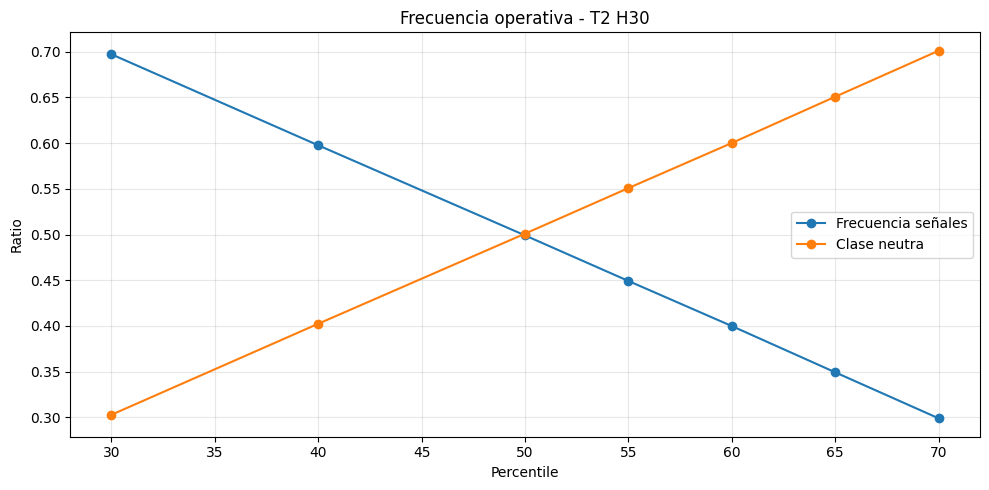

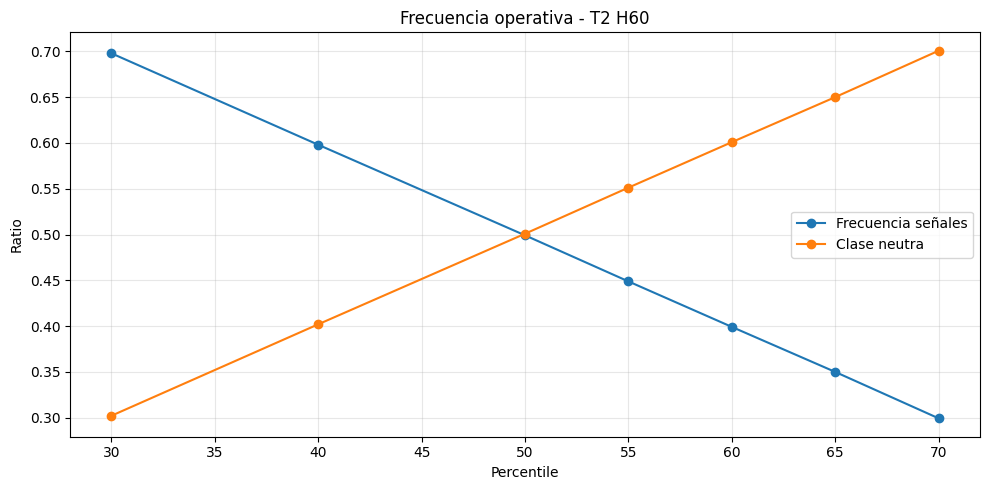

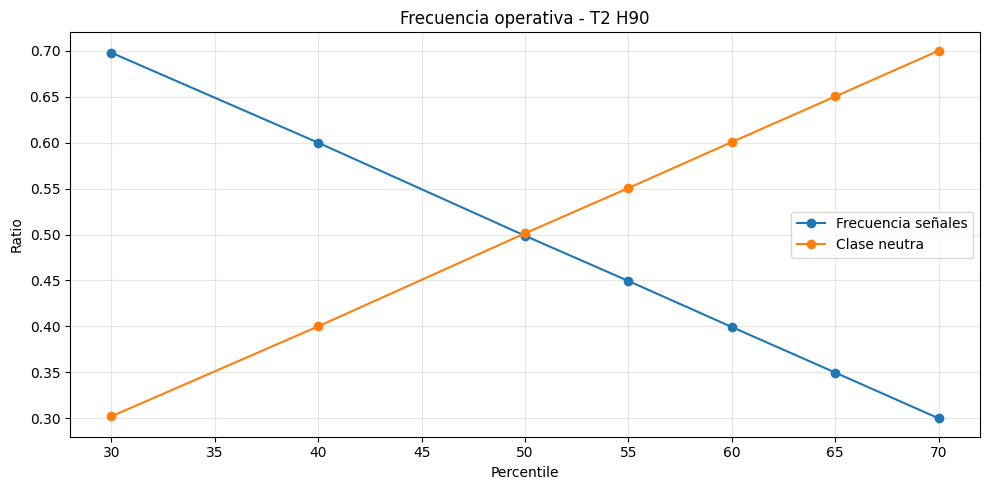

In [42]:
# =========================================================
# Evolución de frecuencia operativa
# =========================================================

display(Markdown("## Evolución de frecuencia operativa - T2"))

for H in horizons:

    temp = summary_frequency_t2[
        summary_frequency_t2["horizon"] == H
    ]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        temp["percentile"],
        temp["signal_rate"],
        marker="o",
        label="Frecuencia señales"
    )

    ax.plot(
        temp["percentile"],
        temp["neutral_rate"],
        marker="o",
        label="Clase neutra"
    )

    ax.set_title(f"Frecuencia operativa - T2 H{H}")
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Ratio")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Balance operativo long vs short - T2

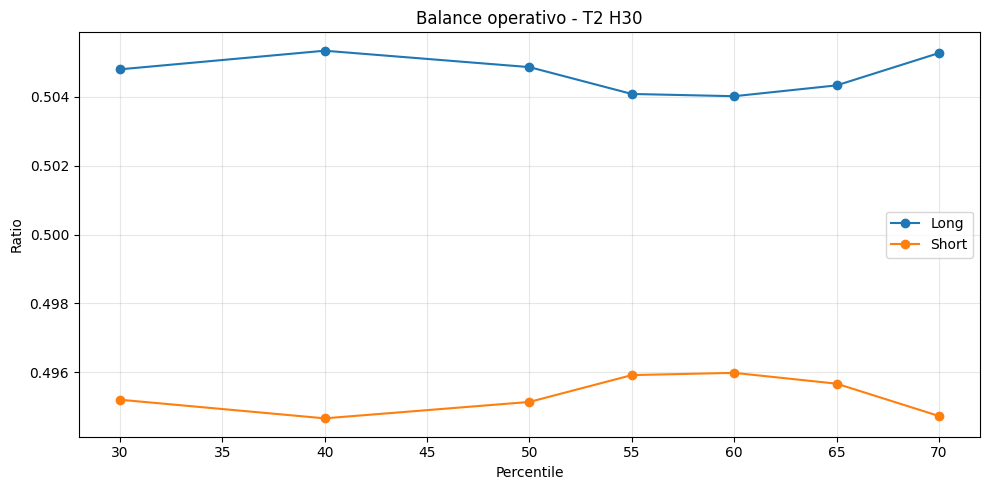

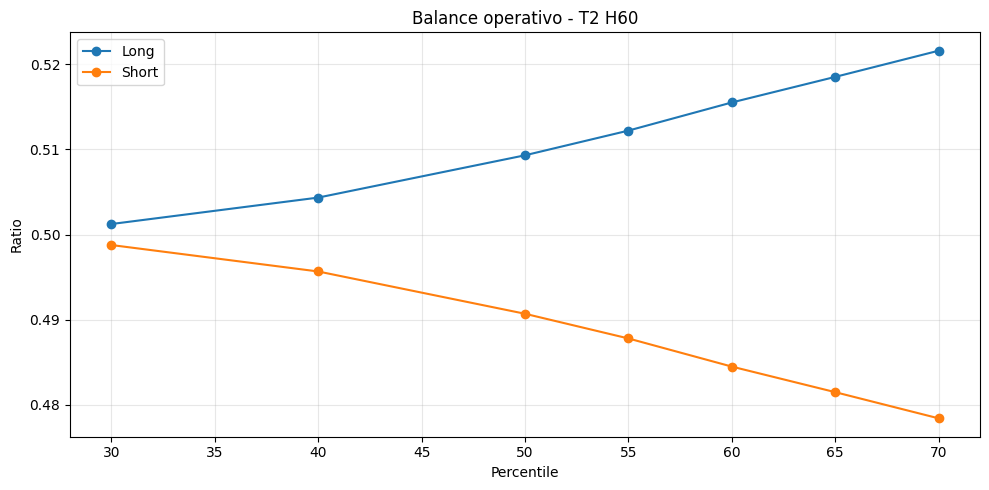

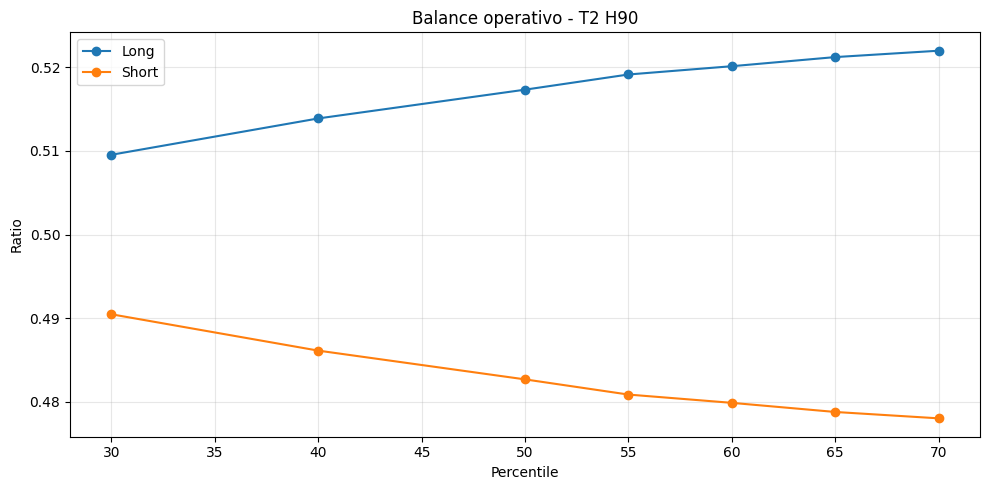

In [43]:
# =========================================================
# Balance operativo long vs short
# =========================================================

display(Markdown("## Balance operativo long vs short - T2"))

for H in horizons:

    temp = summary_frequency_t2[
        summary_frequency_t2["horizon"] == H
    ]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        temp["percentile"],
        temp["long_ratio_signals"],
        marker="o",
        label="Long"
    )

    ax.plot(
        temp["percentile"],
        temp["short_ratio_signals"],
        marker="o",
        label="Short"
    )

    ax.set_title(f"Balance operativo - T2 H{H}")
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Ratio")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Este análisis permitirá estudiar cómo T2 transforma progresivamente un target altamente denso y no selectivo (T1) en una estructura más filtrada y operativa, controlando explícitamente la frecuencia de señales mediante la elección del threshold.

**Observaciones rápidas:**

* La frecuencia operativa de T2 disminuye de forma prácticamente lineal a medida que aumenta el percentil utilizado para definir el threshold.

* Los percentiles bajos (`p30–p40`) generan targets relativamente densos, manteniendo aproximadamente entre 60% y 70% de señales operativas.

* Los percentiles intermedios (`p50`) producen una estructura casi perfectamente equilibrada entre:

  * observaciones operativas (`±1`)
  * observaciones neutrales (`0`)

* Los percentiles altos (`p65–p70`) transforman T2 en un target altamente selectivo, donde aproximadamente el 70% de las observaciones quedan clasificadas como neutras.

* La reducción de frecuencia operativa es prácticamente idéntica en H30, H60 y H90, lo que indica una relación muy estable entre percentil y densidad de señales.

* En H30, el balance operativo entre señales long y short permanece extremadamente cercano al equilibrio en todos los percentiles evaluados.

* A medida que aumenta el horizonte temporal, comienza a observarse una predominancia progresiva de señales long, especialmente en H60 y H90.

* El directional bias operativo se vuelve más visible en percentiles altos y horizontes amplios, donde las señales long alcanzan aproximadamente 52% del total de señales operativas.

* Esto sugiere que movimientos extremos de mayor duración presentan una ligera asimetría alcista dentro del dataset analizado.

* Desde el punto de vista operativo, T2 permite controlar explícitamente el tradeoff entre:

  * frecuencia de señales
  * selectividad
  * densidad operativa
  * reducción de ruido

* En términos prácticos:

  * percentiles bajos → mayor cantidad de oportunidades pero potencialmente más ruido
  * percentiles altos → menor frecuencia pero señales potencialmente más relevantes

* Los resultados sugieren nuevamente que configuraciones intermedias (`p40–p55`) podrían representar un equilibrio razonable entre operabilidad y filtrado estadístico para etapas posteriores de modelado.


### **4.4. Estabilidad Temporal**

Uno de los principales objetivos de T2 consiste en reducir el ruido estadístico presente en T1 mediante la incorporación de thresholds de relevancia. Sin embargo, este filtrado también puede modificar la estabilidad temporal del target, especialmente en configuraciones más selectivas.

El objetivo de esta sección consiste en analizar cómo distintos horizontes y percentiles afectan:

- estabilidad del balance de clases
- drift temporal
- persistencia de directional bias
- robustez estadística
- comportamiento rolling del target

En particular, resulta importante evaluar si los movimientos considerados “significativos” mantienen propiedades relativamente consistentes a lo largo del tiempo o si presentan cambios estructurales relevantes según las condiciones del mercado.


In [44]:
# =========================================================
# 4.4 Estabilidad temporal - T2
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# =========================================================
# Crear columna mensual
# =========================================================

df_t2["year_month"] = df_t2["date"].dt.to_period("M")

monthly_stability_t2 = []

for H in horizons:

    for p in percentiles:

        target_col = f"t2_p{p}_h{H}"

        temp = (
            df_t2
            .groupby("year_month")[target_col]
            .value_counts(normalize=True)
            .unstack(fill_value=0)
            .reset_index()
        )

        temp.columns = [
            "year_month",
            "class_-1_ratio",
            "class_0_ratio",
            "class_1_ratio"
        ]

        temp["target"] = target_col
        temp["horizon"] = H
        temp["percentile"] = p

        temp["signal_ratio"] = (
            temp["class_-1_ratio"] +
            temp["class_1_ratio"]
        )

        temp["long_short_gap"] = (
            temp["class_1_ratio"] -
            temp["class_-1_ratio"]
        ).abs()

        monthly_stability_t2.append(temp)

df_t2_monthly_stability = pd.concat(
    monthly_stability_t2,
    ignore_index=True
)

display(Markdown("## Distribución temporal mensual - T2"))
display(df_t2_monthly_stability.head())

## Distribución temporal mensual - T2

,year_month,class_-1_ratio,class_0_ratio,class_1_ratio,target,horizon,percentile,signal_ratio,long_short_gap
0,2020-01,0.217371,0.565733,0.216896,t2_p30_h30,30,30,0.434267,0.000475
1,2020-02,0.296206,0.428309,0.275485,t2_p30_h30,30,30,0.571691,0.020720
2,2020-03,0.411841,0.169435,0.418723,t2_p30_h30,30,30,0.830565,0.006882
3,2020-04,0.338621,0.287625,0.373754,t2_p30_h30,30,30,0.712375,0.035133
4,2020-05,0.313953,0.340781,0.345266,t2_p30_h30,30,30,0.659219,0.031312


In [45]:
# =========================================================
# Estadísticas resumen de estabilidad
# =========================================================

stability_summary_t2 = (
    df_t2_monthly_stability
    .groupby(["horizon", "percentile"])
    .agg({
        "signal_ratio": ["mean", "std"],
        "long_short_gap": ["mean", "std"]
    })
)

stability_summary_t2.columns = [
    "mean_signal_ratio",
    "std_signal_ratio",
    "mean_long_short_gap",
    "std_long_short_gap"
]

stability_summary_t2 = (
    stability_summary_t2
    .reset_index()
)

display(Markdown("## Resumen estadístico de estabilidad temporal - T2"))
display(stability_summary_t2)

## Resumen estadístico de estabilidad temporal - T2

,horizon,percentile,mean_signal_ratio,std_signal_ratio,mean_long_short_gap,std_long_short_gap
0,30,30,0.698961,0.082266,0.015804,0.010237
1,30,40,0.599823,0.096338,0.014806,0.009118
2,30,50,0.501496,0.103186,0.013600,0.008101
3,30,55,0.451650,0.104527,0.012426,0.007504
4,30,60,0.402308,0.103709,0.011422,0.007465
5,30,65,0.351632,0.101382,0.010163,0.006910
6,30,70,0.301243,0.096952,0.009318,0.006839
7,60,30,0.699608,0.083364,0.018547,0.012294
8,60,40,0.600131,0.097677,0.017253,0.012621
9,60,50,0.501498,0.105718,0.016546,0.013894


## Evolución temporal de frecuencia operativa - T2

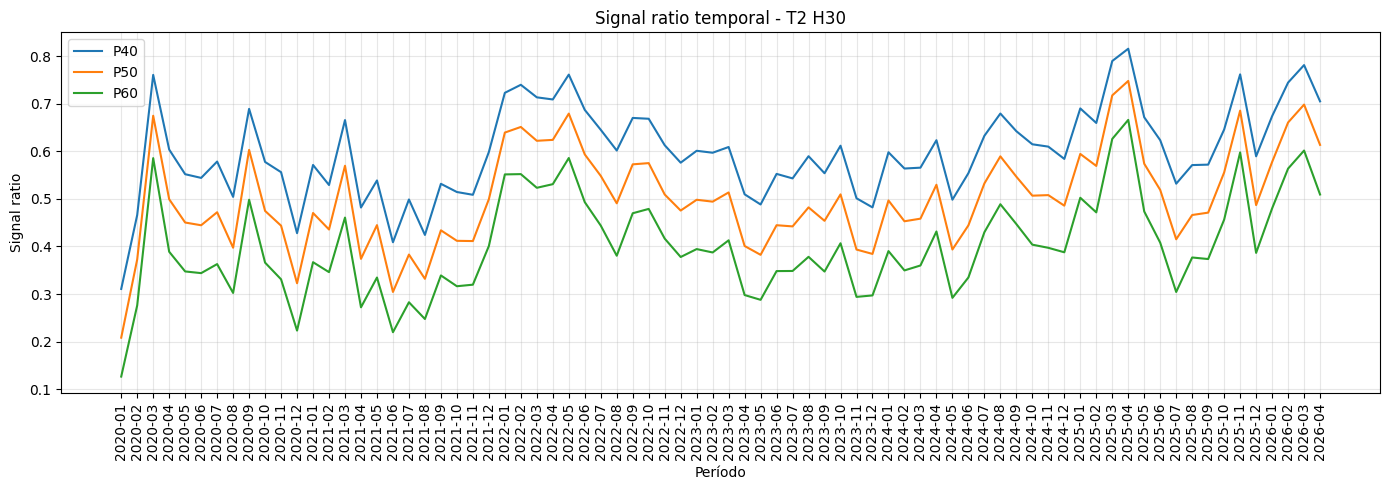

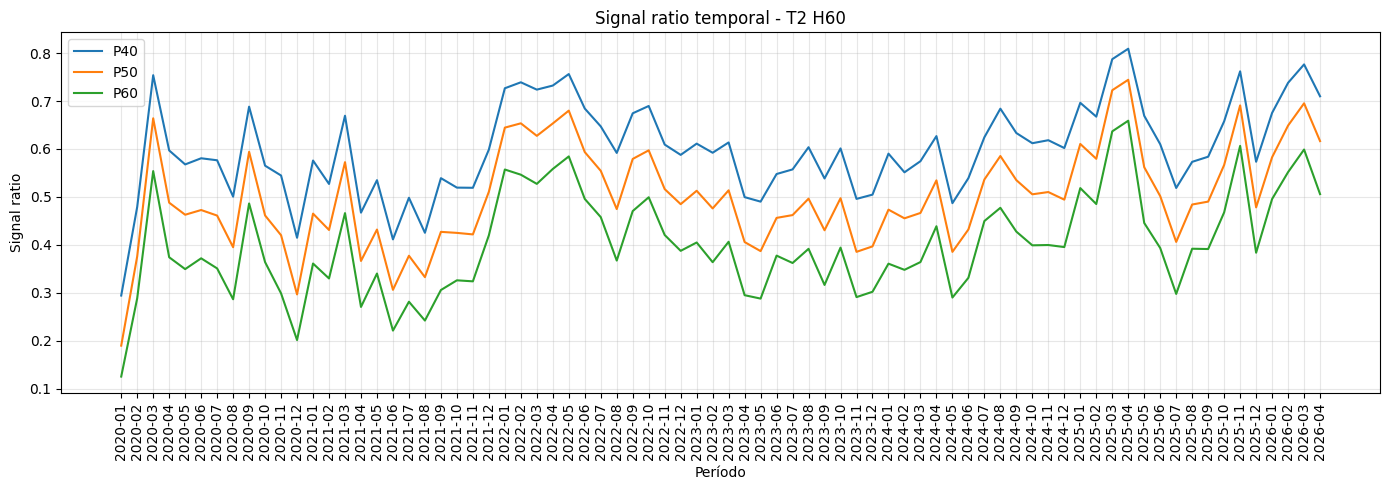

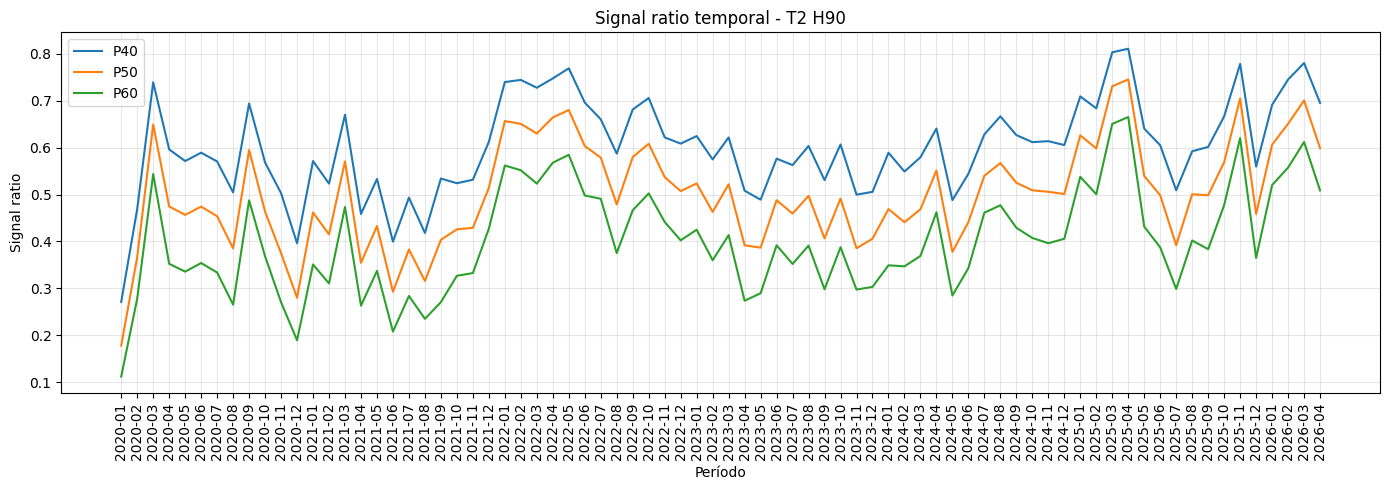

In [46]:
# =========================================================
# Evolución temporal de frecuencia operativa
# =========================================================

display(Markdown("## Evolución temporal de frecuencia operativa - T2"))

selected_percentiles = [40, 50, 60]

for H in horizons:

    fig, ax = plt.subplots(figsize=(14, 5))

    for p in selected_percentiles:

        temp = df_t2_monthly_stability[
            (df_t2_monthly_stability["horizon"] == H) &
            (df_t2_monthly_stability["percentile"] == p)
        ]

        ax.plot(
            temp["year_month"].astype(str),
            temp["signal_ratio"],
            label=f"P{p}"
        )

    ax.set_title(f"Signal ratio temporal - T2 H{H}")
    ax.set_xlabel("Período")
    ax.set_ylabel("Signal ratio")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## Evolución temporal del directional bias - T2

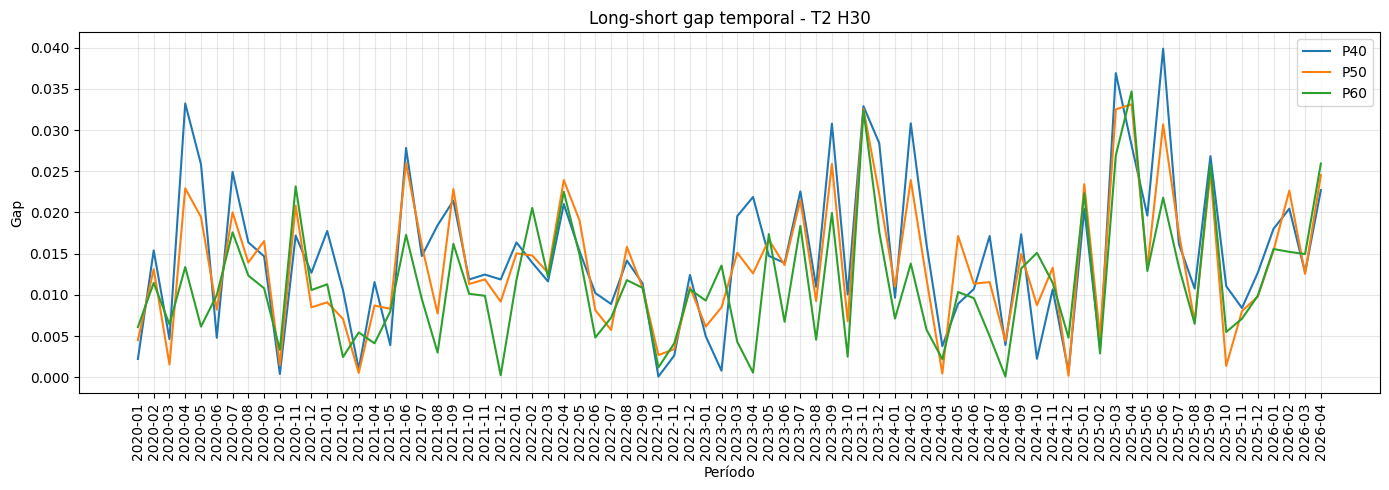

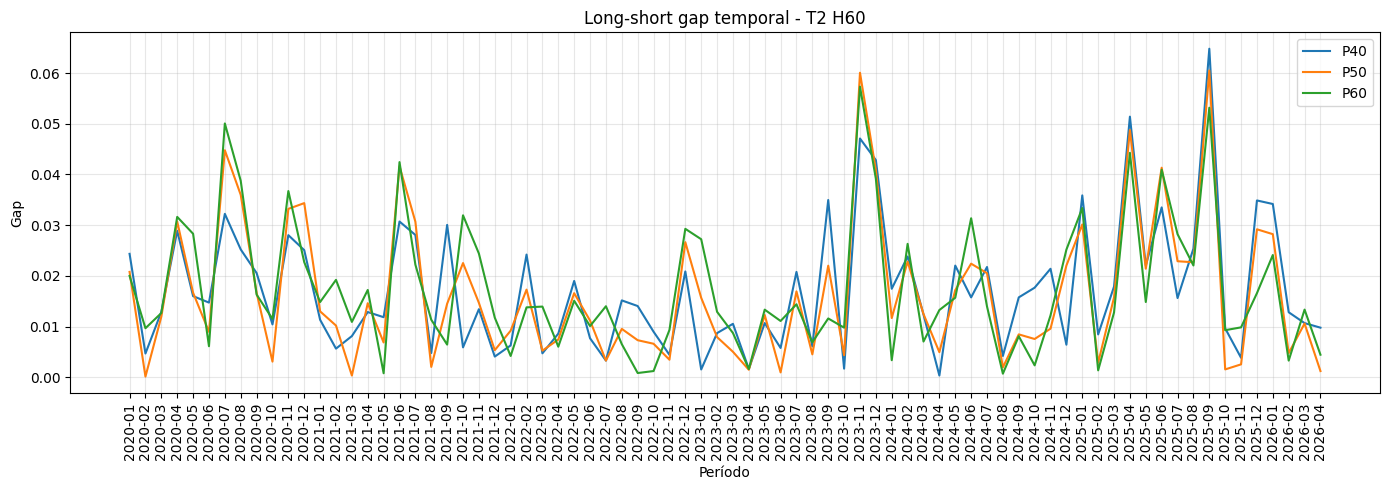

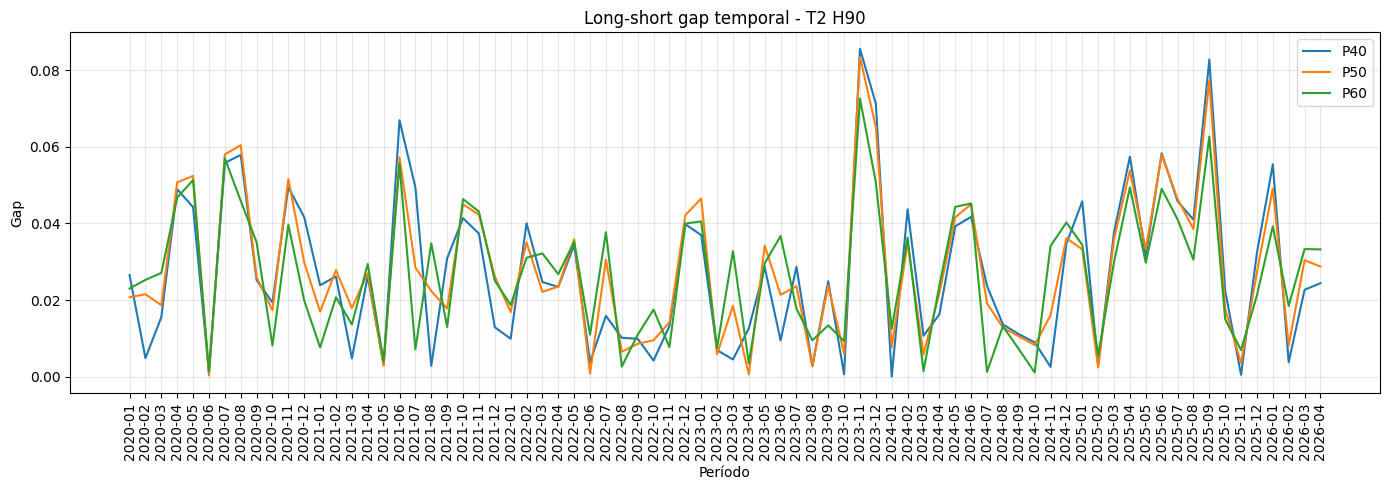

In [47]:
# =========================================================
# Evolución temporal del directional bias
# =========================================================

display(Markdown("## Evolución temporal del directional bias - T2"))

for H in horizons:

    fig, ax = plt.subplots(figsize=(14, 5))

    for p in selected_percentiles:

        temp = df_t2_monthly_stability[
            (df_t2_monthly_stability["horizon"] == H) &
            (df_t2_monthly_stability["percentile"] == p)
        ]

        ax.plot(
            temp["year_month"].astype(str),
            temp["long_short_gap"],
            label=f"P{p}"
        )

    ax.set_title(f"Long-short gap temporal - T2 H{H}")
    ax.set_xlabel("Período")
    ax.set_ylabel("Gap")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## Rolling signal ratio - T2

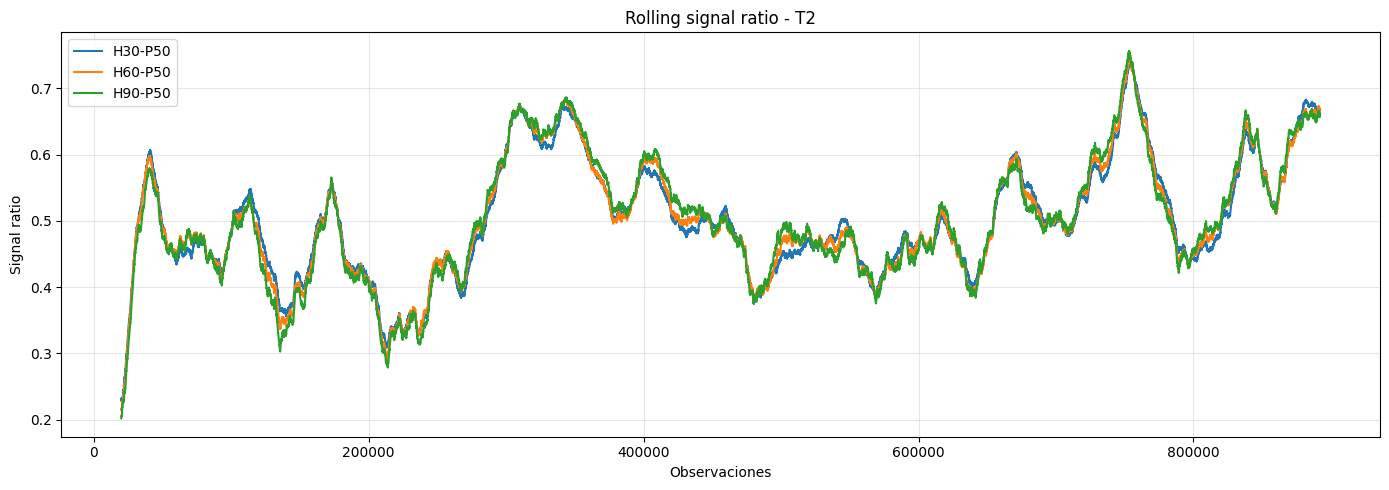

In [48]:
# =========================================================
# Rolling signal ratio
# =========================================================

display(Markdown("## Rolling signal ratio - T2"))

rolling_window = 20000

selected_configs = [
    (30, 50),
    (60, 50),
    (90, 50)
]

fig, ax = plt.subplots(figsize=(14, 5))

for H, p in selected_configs:

    target_col = f"t2_p{p}_h{H}"

    signal_series = (
        (df_t2[target_col] != 0)
        .astype(int)
    )

    rolling_signal_ratio = (
        signal_series
        .rolling(rolling_window)
        .mean()
    )

    ax.plot(
        rolling_signal_ratio,
        label=f"H{H}-P{p}"
    )

ax.set_title("Rolling signal ratio - T2")
ax.set_xlabel("Observaciones")
ax.set_ylabel("Signal ratio")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Este análisis permitirá evaluar si el filtrado introducido por T2 no solo reduce ruido, sino también si mantiene propiedades suficientemente estables y robustas para ser utilizadas posteriormente en modelos de Machine Learning y sistemas operativos de trading.

**Observaciones rápidas:**

* La frecuencia operativa de T2 presenta variaciones temporales importantes a lo largo de todo el período analizado, evidenciando que la densidad de señales depende fuertemente del régimen de volatilidad del mercado.

* Durante períodos de alta volatilidad, especialmente en 2020, 2022 y ciertos tramos de 2025–2026, el `signal_ratio` aumenta considerablemente incluso para thresholds altos.

* En escenarios de baja volatilidad, la clase neutra domina gran parte del dataset, reduciendo significativamente la cantidad de señales operativas disponibles.

* El comportamiento temporal de los distintos percentiles mantiene una estructura muy consistente:

  * P40 siempre genera más señales
  * P50 ocupa una posición intermedia
  * P60 produce targets mucho más selectivos

* El rolling signal ratio confirma que T2 no posee una frecuencia operativa estacionaria, sino que responde dinámicamente a cambios estructurales del mercado y volatilidad intrínseca del activo.

* A pesar de estas fluctuaciones, las tres configuraciones evaluadas (H30, H60 y H90) muestran trayectorias rolling muy similares, indicando coherencia estructural entre horizontes.

* La desviación estándar del `signal_ratio` aumenta levemente en horizontes más largos, especialmente en H90, sugiriendo menor estabilidad temporal en targets de mayor duración.

* El directional bias temporal permanece relativamente bajo en H30, pero aumenta progresivamente en H60 y especialmente en H90.

* Los mayores spikes de `long_short_gap` aparecen durante períodos de fuerte tendencia direccional del mercado, donde predominan movimientos alcistas prolongados.

* Incluso en los peores casos, el desbalance long-short sigue siendo moderado comparado con problemas clásicos de clasificación financiera extremadamente desbalanceados.

* Los thresholds altos no necesariamente mejoran la estabilidad temporal; en muchos casos continúan mostrando variaciones importantes asociadas a cambios de volatilidad del mercado.

* En términos generales, T2 logra:

  * reducir ruido respecto a T1
  * controlar explícitamente la frecuencia operativa
  * mantener un balance razonable entre clases
  * conservar estabilidad estructural aceptable

* Sin embargo, los resultados también muestran que la dinámica temporal del mercado continúa impactando significativamente la distribución estadística del target, especialmente en horizontes amplios y movimientos extremos.


### **4.5. Sensibilidad paramétrica - T2**


El target T2 depende directamente de dos parámetros fundamentales:

* horizonte temporal (`H`)
* threshold de discretización (`percentile`)

Ambos parámetros determinan la estructura estadística del target y modifican directamente:

* frecuencia operativa
* balance entre clases
* densidad de señales
* directional bias
* estabilidad temporal
* nivel de ruido incorporado

El objetivo de esta sección consiste en estudiar cómo distintas configuraciones de parámetros alteran las propiedades estadísticas y operativas de T2, permitiendo identificar regiones potencialmente más robustas para etapas posteriores de modelado.

En términos conceptuales:

* horizontes cortos tienden a generar targets más sensibles al ruido de microestructura
* horizontes largos capturan movimientos más amplios, aunque pueden introducir mayor directional bias y menor estabilidad

Por otro lado:

* thresholds bajos generan targets densos y frecuentes
* thresholds altos producen targets más selectivos y conservadores

En consecuencia, T2 puede interpretarse como una familia de targets parametrizados, donde distintas combinaciones de horizonte y percentil representan distintos compromisos entre:

* operabilidad
* estabilidad
* frecuencia de señales
* selectividad
* dificultad predictiva


## Resumen de sensibilidad paramétrica - T2

,target,horizon,percentile,signal_ratio,neutral_ratio,long_short_gap
0,t2_p30_h30,30,30,0.697218,0.302782,0.006695
1,t2_p40_h30,30,40,0.597623,0.402377,0.006385
2,t2_p50_h30,30,50,0.499053,0.500947,0.004856
3,t2_p55_h30,30,55,0.449185,0.550815,0.003670
4,t2_p60_h30,30,60,0.399855,0.600145,0.003215
5,t2_p65_h30,30,65,0.349239,0.650761,0.003028
6,t2_p70_h30,30,70,0.298896,0.701104,0.003153
7,t2_p30_h60,60,30,0.697911,0.302089,0.001724
8,t2_p40_h60,60,40,0.598043,0.401957,0.005196
9,t2_p50_h60,60,50,0.499139,0.500861,0.009301


## Heatmap de frecuencia operativa - T2

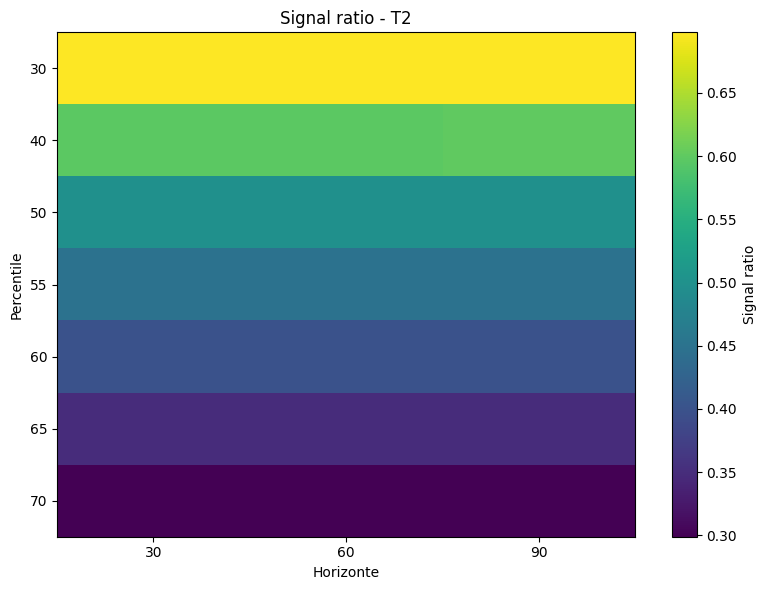

## Heatmap directional bias - T2

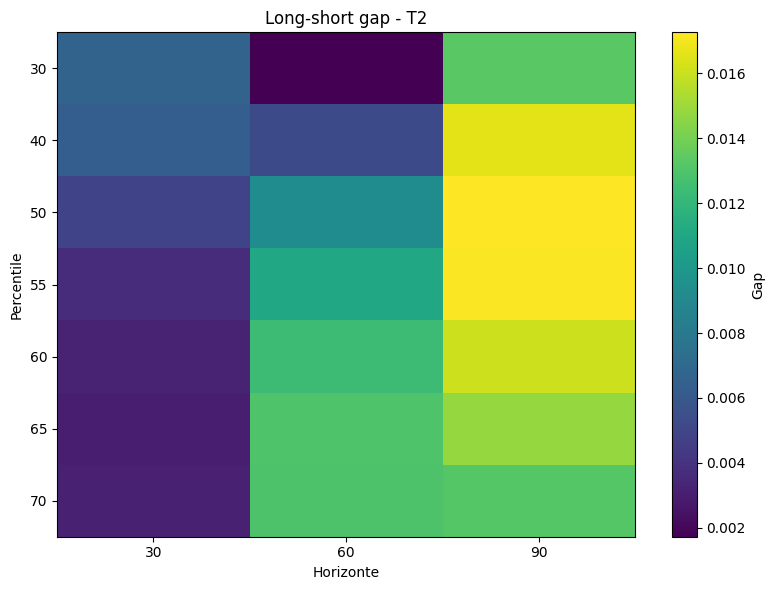

## Evolución paramétrica de frecuencia operativa - T2

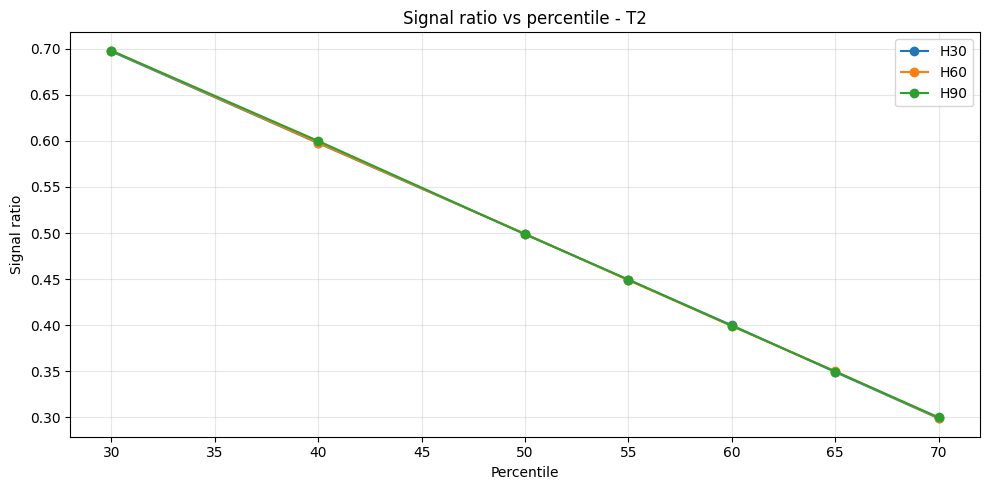

## Evolución paramétrica del directional bias - T2

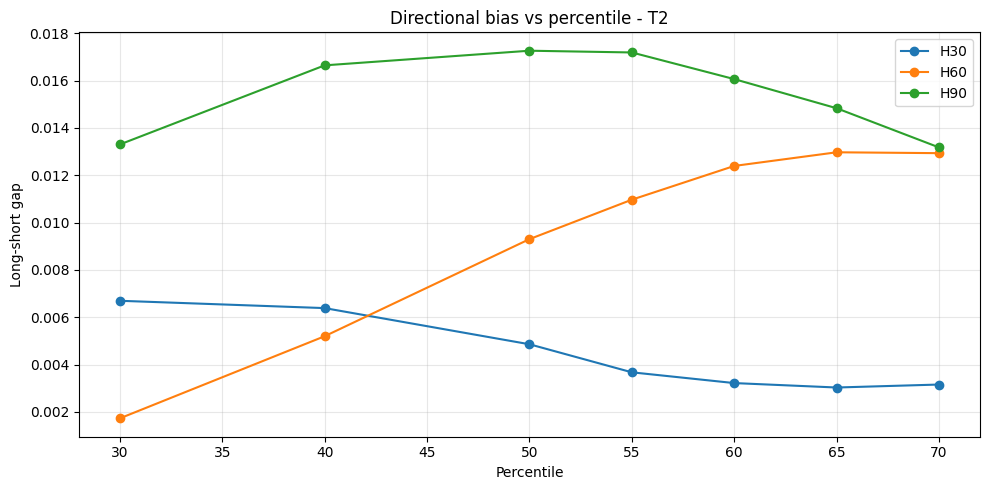

In [49]:
# =========================================================
# 4.5 Sensibilidad paramétrica - T2
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# =========================================================
# Construir resumen paramétrico
# =========================================================

parametric_rows_t2 = []

for H in horizons:

    for p in percentiles:

        target_col = f"t2_p{p}_h{H}"

        counts = (
            df_t2[target_col]
            .value_counts(normalize=True)
            .sort_index()
        )

        signal_ratio = (
            counts.get(-1, 0) +
            counts.get(1, 0)
        )

        neutral_ratio = counts.get(0, 0)

        long_short_gap = abs(
            counts.get(1, 0) -
            counts.get(-1, 0)
        )

        parametric_rows_t2.append({
            "target": target_col,
            "horizon": H,
            "percentile": p,

            "signal_ratio": signal_ratio,
            "neutral_ratio": neutral_ratio,
            "long_short_gap": long_short_gap
        })

df_t2_parametric = pd.DataFrame(parametric_rows_t2)

display(Markdown("## Resumen de sensibilidad paramétrica - T2"))
display(df_t2_parametric)

# =========================================================
# Heatmap frecuencia operativa
# =========================================================

display(Markdown("## Heatmap de frecuencia operativa - T2"))

pivot_signal = df_t2_parametric.pivot(
    index="percentile",
    columns="horizon",
    values="signal_ratio"
)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    pivot_signal,
    aspect="auto"
)

ax.set_xticks(range(len(pivot_signal.columns)))
ax.set_xticklabels(pivot_signal.columns)

ax.set_yticks(range(len(pivot_signal.index)))
ax.set_yticklabels(pivot_signal.index)

ax.set_xlabel("Horizonte")
ax.set_ylabel("Percentile")
ax.set_title("Signal ratio - T2")

cbar = plt.colorbar(im)
cbar.set_label("Signal ratio")

plt.tight_layout()
plt.show()

# =========================================================
# Heatmap directional bias
# =========================================================

display(Markdown("## Heatmap directional bias - T2"))

pivot_gap = df_t2_parametric.pivot(
    index="percentile",
    columns="horizon",
    values="long_short_gap"
)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    pivot_gap,
    aspect="auto"
)

ax.set_xticks(range(len(pivot_gap.columns)))
ax.set_xticklabels(pivot_gap.columns)

ax.set_yticks(range(len(pivot_gap.index)))
ax.set_yticklabels(pivot_gap.index)

ax.set_xlabel("Horizonte")
ax.set_ylabel("Percentile")
ax.set_title("Long-short gap - T2")

cbar = plt.colorbar(im)
cbar.set_label("Gap")

plt.tight_layout()
plt.show()

# =========================================================
# Evolución paramétrica de frecuencia operativa
# =========================================================

display(Markdown("## Evolución paramétrica de frecuencia operativa - T2"))

fig, ax = plt.subplots(figsize=(10, 5))

for H in horizons:

    temp = df_t2_parametric[
        df_t2_parametric["horizon"] == H
    ]

    ax.plot(
        temp["percentile"],
        temp["signal_ratio"],
        marker="o",
        label=f"H{H}"
    )

ax.set_title("Signal ratio vs percentile - T2")
ax.set_xlabel("Percentile")
ax.set_ylabel("Signal ratio")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# Evolución paramétrica del directional bias
# =========================================================

display(Markdown("## Evolución paramétrica del directional bias - T2"))

fig, ax = plt.subplots(figsize=(10, 5))

for H in horizons:

    temp = df_t2_parametric[
        df_t2_parametric["horizon"] == H
    ]

    ax.plot(
        temp["percentile"],
        temp["long_short_gap"],
        marker="o",
        label=f"H{H}"
    )

ax.set_title("Directional bias vs percentile - T2")
ax.set_xlabel("Percentile")
ax.set_ylabel("Long-short gap")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



Este análisis permitirá identificar configuraciones de T2 potencialmente más robustas, equilibradas y operables, proporcionando una base objetiva para seleccionar targets candidatos en las etapas posteriores de entrenamiento y evaluación de modelos de Machine Learning.

**Observaciones rápidas:**

* La sensibilidad paramétrica de T2 está dominada principalmente por el percentil utilizado, mientras que el horizonte temporal tiene un impacto mucho menor sobre la frecuencia operativa.

* El `signal_ratio` disminuye de forma casi perfectamente lineal al aumentar el percentil:

  * ~70% señales en P30
  * ~50% señales en P50
  * ~30% señales en P70

* Los heatmaps muestran que la frecuencia operativa es prácticamente idéntica entre H30, H60 y H90 para un mismo percentil, indicando una estructura extremadamente estable respecto al horizonte.

* Esto sugiere que el parámetro más influyente de T2 no es el horizonte temporal, sino el nivel de filtrado impuesto por el threshold.

* El directional bias presenta un comportamiento mucho más sensible al horizonte:

  * H30 mantiene un gap muy bajo y estable
  * H60 introduce un sesgo progresivo hacia señales long
  * H90 muestra el mayor desbalance estructural

* El aumento del directional bias en H60 y H90 sugiere que movimientos amplios y prolongados tienden a presentar una asimetría alcista dentro del dataset analizado.

* En H30, el directional bias incluso disminuye levemente al aumentar el percentil, indicando un target relativamente robusto y equilibrado.

* En contraste, H60 y H90 muestran un incremento importante del long-short gap en percentiles intermedios (`P50–P65`).

* Los percentiles intermedios (`P40–P55`) aparecen nuevamente como una región de compromiso razonable:

  * frecuencia operativa moderada
  * directional bias relativamente controlado
  * equilibrio entre densidad y selectividad

* Los thresholds altos (`P65–P70`) producen targets altamente filtrados, pero no necesariamente más balanceados ni más estables desde el punto de vista direccional.

* El comportamiento observado confirma que T2 permite controlar explícitamente el tradeoff entre:

  * ruido
  * frecuencia operativa
  * balance estadístico
  * directional bias
  * selectividad del target

* En términos prácticos:

  * percentiles bajos → targets densos y más operables
  * percentiles altos → targets más conservadores y selectivos
  * horizontes largos → mayor directional bias y menor neutralidad estadística

* Estos resultados proporcionan una base objetiva para seleccionar configuraciones candidatas de T2 en las etapas posteriores de modelado y evaluación predictiva.



### **4.6. Análisis por régimen intradiario**


Además del análisis global de T2, resulta relevante estudiar cómo cambia su comportamiento estadístico según distintos regímenes intradiarios representados por la variable `regime_id`.

En el caso de T2, este análisis adquiere especial importancia debido a que el target incorpora thresholds de relevancia y, por lo tanto, depende directamente de la intensidad de los movimientos del mercado en cada período del día.

Las condiciones intradiarias pueden modificar significativamente:

* frecuencia de movimientos significativos
* volatilidad
* directional bias
* densidad de señales
* balance estadístico entre clases

Como consecuencia, ciertas configuraciones de T2 podrían resultar más operables o más estables en determinados regímenes específicos.

El objetivo de esta sección consiste en evaluar cómo cambia T2 entre distintos regímenes intradiarios en términos de:

* distribución de clases
* frecuencia operativa
* directional bias
* estabilidad estadística
* densidad de señales significativas

## Distribución por régimen intradiario - T2

,regime_id,class_-1_ratio,class_0_ratio,class_1_ratio,target,horizon,percentile,signal_ratio,long_short_gap
0,0,0.290040,0.424000,0.285960,t2_p30_h30,30,30,0.576000,0.004080
1,1,0.324972,0.309419,0.365609,t2_p30_h30,30,30,0.690581,0.040637
2,2,0.387645,0.180988,0.431367,t2_p30_h30,30,30,0.819012,0.043723
3,3,0.362781,0.269805,0.367414,t2_p30_h30,30,30,0.730195,0.004633
4,4,0.405668,0.248650,0.345682,t2_p30_h30,30,30,0.751350,0.059987


## Resumen compacto por régimen - T2

,regime_id,target,horizon,percentile,signal_ratio,class_0_ratio,long_short_gap
0,0,t2_p30_h30,30,30,0.576000,0.424000,0.004080
1,1,t2_p30_h30,30,30,0.690581,0.309419,0.040637
2,2,t2_p30_h30,30,30,0.819012,0.180988,0.043723
3,3,t2_p30_h30,30,30,0.730195,0.269805,0.004633
4,4,t2_p30_h30,30,30,0.751350,0.248650,0.059987
...,...,...,...,...,...,...,...
100,0,t2_p70_h90,90,70,0.179626,0.820374,0.003210
101,1,t2_p70_h90,90,70,0.671191,0.328809,0.101868
102,2,t2_p70_h90,90,70,0.345834,0.654166,0.031597
103,3,t2_p70_h90,90,70,0.277637,0.722363,0.000830


## Frecuencia operativa por régimen - T2

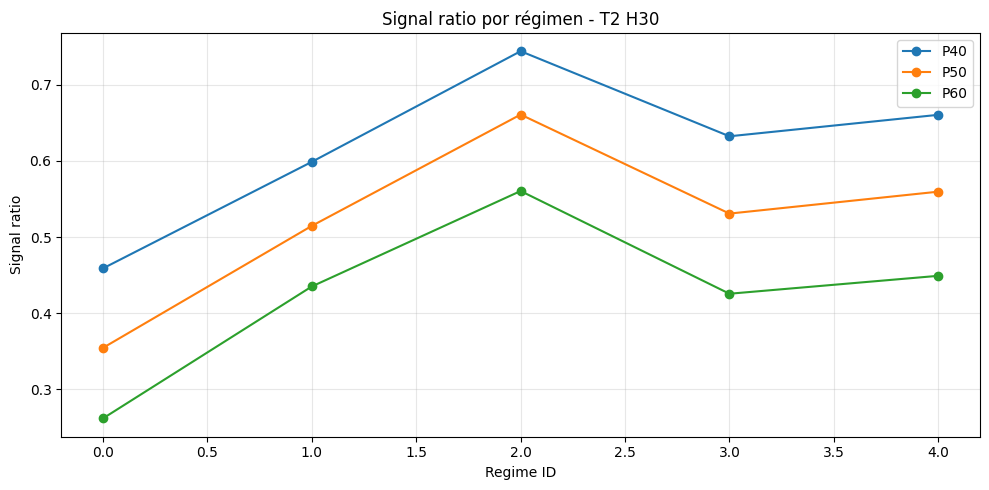

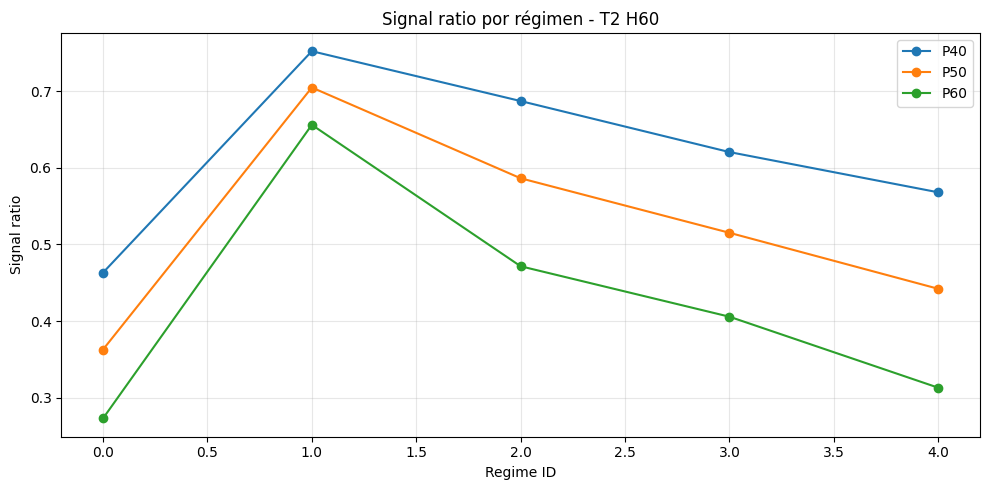

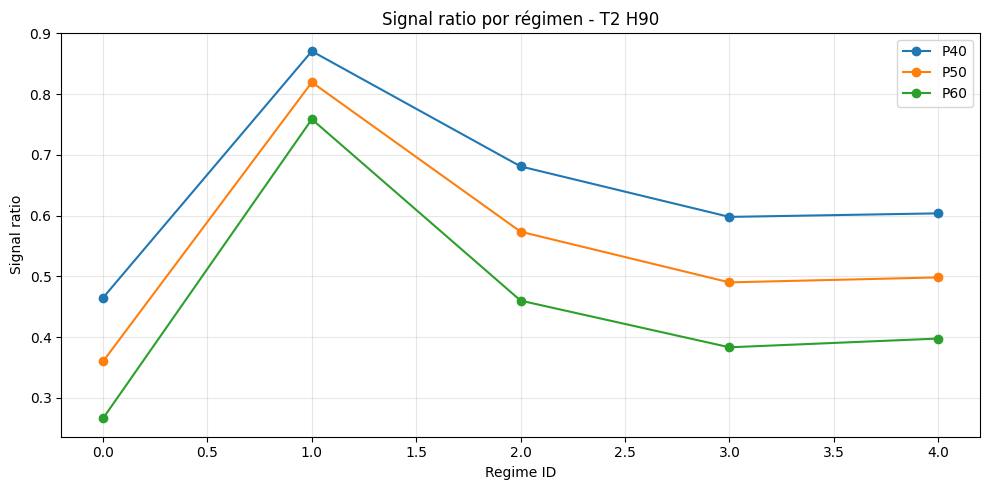

## Directional bias por régimen - T2

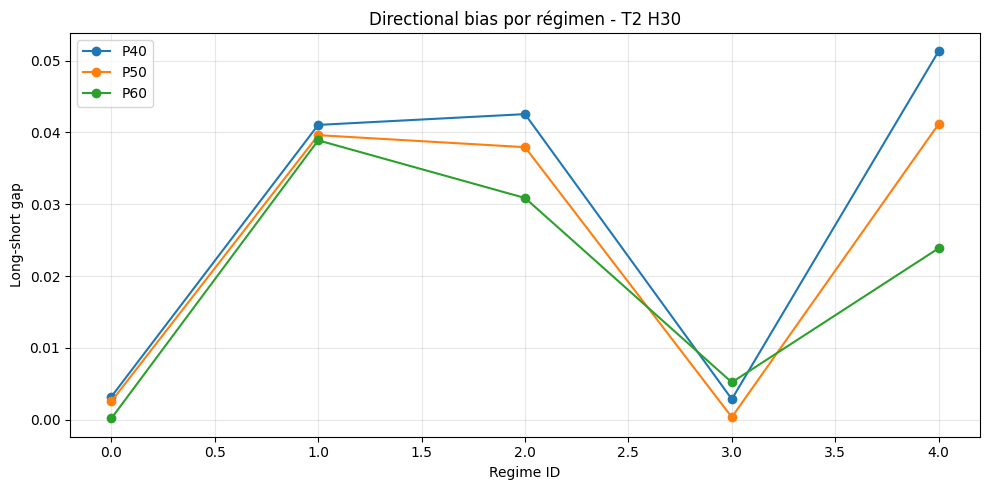

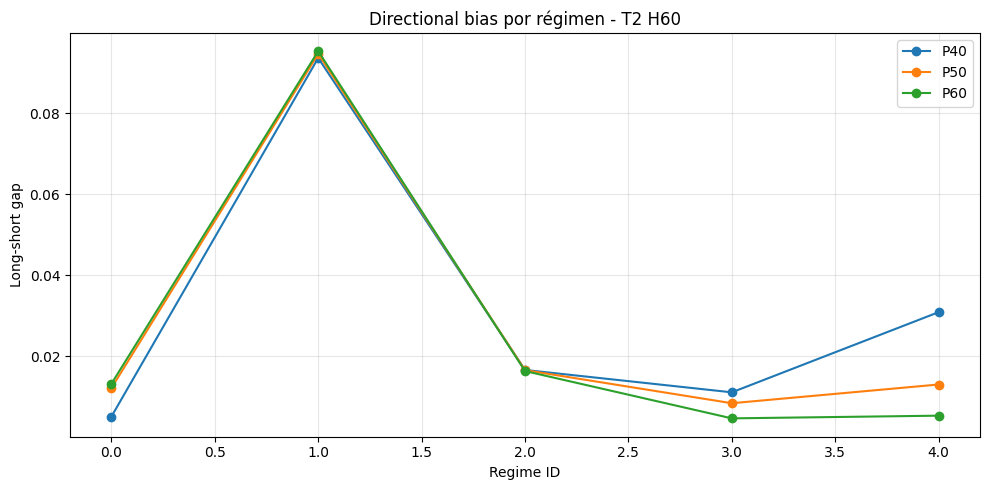

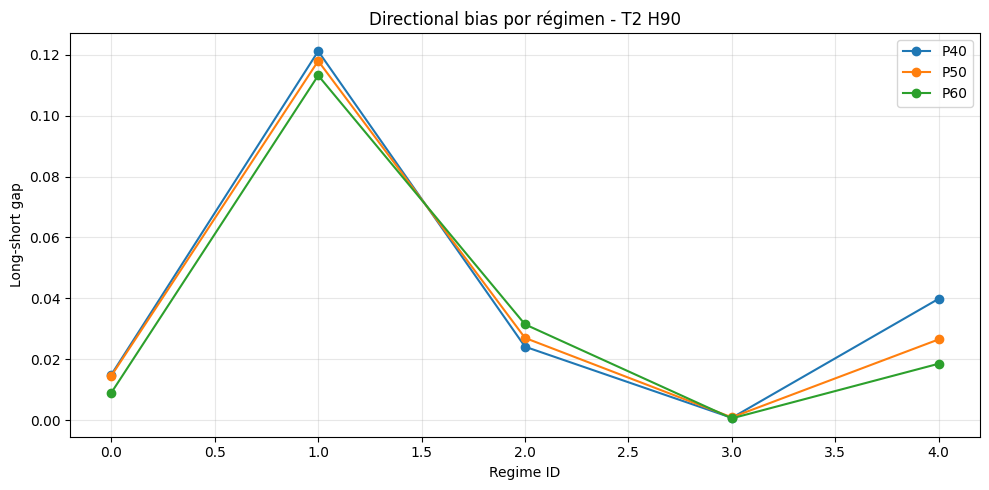

## Heatmap frecuencia operativa por régimen - T2

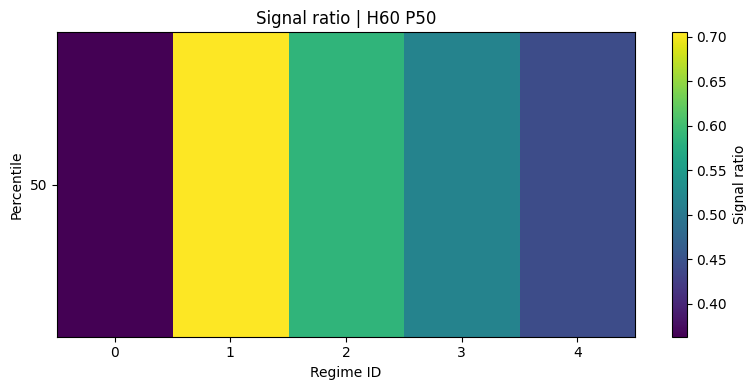

In [50]:
# =========================================================
# 4.6 Análisis por régimen intradiario - T2
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

regime_rows_t2 = []

for H in horizons:

    for p in percentiles:

        target_col = f"t2_p{p}_h{H}"

        grouped = (
            df_t2
            .groupby("regime_id")[target_col]
            .value_counts(normalize=True)
            .unstack(fill_value=0)
            .reset_index()
        )

        grouped.columns = [
            "regime_id",
            "class_-1_ratio",
            "class_0_ratio",
            "class_1_ratio"
        ]

        grouped["target"] = target_col
        grouped["horizon"] = H
        grouped["percentile"] = p

        grouped["signal_ratio"] = (
            grouped["class_-1_ratio"] +
            grouped["class_1_ratio"]
        )

        grouped["long_short_gap"] = abs(
            grouped["class_1_ratio"] -
            grouped["class_-1_ratio"]
        )

        regime_rows_t2.append(grouped)

df_t2_regime_analysis = pd.concat(
    regime_rows_t2,
    ignore_index=True
)

display(Markdown("## Distribución por régimen intradiario - T2"))
display(df_t2_regime_analysis.head())

# =========================================================
# Resumen compacto por régimen
# =========================================================

summary_regime_t2 = df_t2_regime_analysis[
    [
        "regime_id",
        "target",
        "horizon",
        "percentile",
        "signal_ratio",
        "class_0_ratio",
        "long_short_gap"
    ]
]

display(Markdown("## Resumen compacto por régimen - T2"))
display(summary_regime_t2)

# =========================================================
# Frecuencia operativa por régimen
# =========================================================

display(Markdown("## Frecuencia operativa por régimen - T2"))

selected_percentiles = [40, 50, 60]

for H in horizons:

    fig, ax = plt.subplots(figsize=(10, 5))

    for p in selected_percentiles:

        temp = summary_regime_t2[
            (summary_regime_t2["horizon"] == H) &
            (summary_regime_t2["percentile"] == p)
        ]

        ax.plot(
            temp["regime_id"],
            temp["signal_ratio"],
            marker="o",
            label=f"P{p}"
        )

    ax.set_title(f"Signal ratio por régimen - T2 H{H}")
    ax.set_xlabel("Regime ID")
    ax.set_ylabel("Signal ratio")

    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# =========================================================
# Directional bias por régimen
# =========================================================

display(Markdown("## Directional bias por régimen - T2"))

for H in horizons:

    fig, ax = plt.subplots(figsize=(10, 5))

    for p in selected_percentiles:

        temp = summary_regime_t2[
            (summary_regime_t2["horizon"] == H) &
            (summary_regime_t2["percentile"] == p)
        ]

        ax.plot(
            temp["regime_id"],
            temp["long_short_gap"],
            marker="o",
            label=f"P{p}"
        )

    ax.set_title(f"Directional bias por régimen - T2 H{H}")
    ax.set_xlabel("Regime ID")
    ax.set_ylabel("Long-short gap")

    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# =========================================================
# Heatmap frecuencia operativa por régimen
# =========================================================

display(Markdown("## Heatmap frecuencia operativa por régimen - T2"))

selected_horizon = 60
selected_percentile = 50

temp = summary_regime_t2[
    (summary_regime_t2["horizon"] == selected_horizon) &
    (summary_regime_t2["percentile"] == selected_percentile)
]

pivot_regime_signal = temp.pivot_table(
    index="percentile",
    columns="regime_id",
    values="signal_ratio"
)

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(
    pivot_regime_signal,
    aspect="auto"
)

ax.set_xticks(range(len(pivot_regime_signal.columns)))
ax.set_xticklabels(pivot_regime_signal.columns)

ax.set_yticks(range(len(pivot_regime_signal.index)))
ax.set_yticklabels(pivot_regime_signal.index)

ax.set_xlabel("Regime ID")
ax.set_ylabel("Percentile")

ax.set_title(
    f"Signal ratio | H{selected_horizon} P{selected_percentile}"
)

cbar = plt.colorbar(im)
cbar.set_label("Signal ratio")

plt.tight_layout()
plt.show()


Este análisis permitirá determinar si ciertas configuraciones de T2 presentan un comportamiento más robusto, equilibrado u operable en determinados regímenes intradiarios, proporcionando información relevante para posibles filtros operativos o segmentaciones posteriores del modelado.

**Observaciones rápidas:**

* El comportamiento de T2 cambia fuertemente según el régimen intradiario, confirmando que la señal no está distribuida de manera homogénea a lo largo del día.

* Los regímenes 1 y 2 son claramente los más activos:

  * presentan la mayor frecuencia de señales
  * menor proporción de clase neutra
  * movimientos más intensos y frecuentes

* El régimen 2 aparece como el más “operable” de todos:

  * alcanza los mayores `signal_ratio`
  * especialmente en H30 y percentiles bajos/intermedios
  * refleja períodos de alta volatilidad y fuerte movimiento direccional

* El régimen 0 es el más neutro y conservador:

  * alta presencia de clase `0`
  * menor frecuencia operativa
  * menor intensidad de movimientos

* Los regímenes 3 y 4 muestran comportamientos intermedios:

  * todavía generan señales relevantes
  * pero con menor consistencia que 1 y 2

* El directional bias cambia mucho según el régimen:

  * algunos regímenes permanecen muy balanceados
  * otros muestran fuertes sesgos long

* En H60 y especialmente H90, el régimen 1 presenta un directional bias extremadamente alto, indicando predominancia clara de movimientos alcistas prolongados.

* El régimen 3 es el más equilibrado estadísticamente:

  * directional bias cercano a cero
  * comportamiento relativamente estable entre horizontes y percentiles

* El heatmap confirma que la frecuencia operativa depende más del régimen intradiario que del horizonte temporal.

* Los resultados sugieren que la señal predictiva potencial podría estar concentrada principalmente en ciertos períodos específicos del día y no distribuida uniformemente sobre todo el dataset.

* En términos prácticos:

  * regímenes 1–2 → mayor densidad de oportunidades
  * régimen 0 → mercado más neutro y menos operativo
  * régimen 3 → comportamiento más estable y balanceado
  * régimen 4 → más variable y con directional bias más inestable

* Esto refuerza la idea de que futuras etapas de modelado podrían beneficiarse de:

  * filtros por régimen
  * modelos especializados por contexto intradiario
  * selección de targets condicionada al régimen operativo.


### **4.7. Observaciones e interpretación**

El análisis estadístico de T2 muestra que la incorporación de thresholds modifica profundamente la estructura del problema respecto a T1, permitiendo controlar explícitamente la relación entre frecuencia operativa y filtrado de ruido.

A diferencia de T1, donde todas las observaciones generan una señal direccional, T2 introduce una clase neutra (`0`) que actúa como mecanismo de selección estadística, eliminando movimientos de baja magnitud potencialmente asociados a ruido de mercado.

Los resultados muestran que el parámetro más influyente de T2 corresponde al percentil utilizado para definir el threshold. A medida que aumenta el percentil:

* disminuye la frecuencia operativa
* aumenta la proporción de clase neutra
* el target se vuelve más selectivo
* se reducen los movimientos considerados explotables

En términos generales:

* percentiles bajos producen targets densos y frecuentes
* percentiles altos generan targets más conservadores y filtrados

Los percentiles intermedios (`P40–P55`) aparecen consistentemente como la región de mejor compromiso entre:

* cantidad de señales
* reducción de ruido
* balance estadístico
* estabilidad temporal
* operabilidad práctica

Desde el punto de vista estadístico, T2 mantiene un balance razonable entre señales long y short, especialmente en horizontes cortos (`H30`). Sin embargo, en horizontes más amplios (`H60` y `H90`) comienza a observarse un directional bias progresivo hacia movimientos alcistas, particularmente en configuraciones más selectivas.

El análisis temporal evidencia que T2 no es estacionario. La frecuencia operativa cambia significativamente según las condiciones de volatilidad del mercado, mostrando períodos donde predominan señales frecuentes y otros donde domina ampliamente la clase neutra.

No obstante, incluso bajo estas variaciones, T2 conserva una estructura relativamente robusta y coherente entre horizontes y configuraciones paramétricas.

El análisis por régimen intradiario revela uno de los hallazgos más importantes de toda la investigación estadística:

la señal no se distribuye homogéneamente a lo largo del día.

Los regímenes 1 y 2 concentran la mayor cantidad de movimientos significativos y presentan la mayor frecuencia operativa, mientras que otros regímenes muestran dinámicas mucho más neutras o balanceadas.

Esto sugiere que la predictibilidad potencial del mercado podría estar fuertemente condicionada por el contexto intradiario y no únicamente por la formulación del target.

En conjunto, los resultados obtenidos muestran que T2 logra:

* reducir ruido respecto a T1
* controlar explícitamente la densidad de señales
* mantener balance estadístico aceptable
* introducir selectividad operativa
* capturar diferencias estructurales entre regímenes de mercado

Como consecuencia, T2 representa una formulación significativamente más cercana a escenarios reales de trading algorítmico, proporcionando una base más operativa y potencialmente más explotable para las siguientes etapas de modelado y evaluación predictiva.



## **5. T3 - Investigación estadística**